In [1]:
from pathlib import Path
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib import gridspec
from matplotlib.colors import Normalize
import colorsys
import numpy as np
import pandas as pd
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit import Chem
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import cdist
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import scale
from umap import UMAP

sys.path.append(os.path.abspath(os.path.join('..','..')))
from Code.benchmark import Benchmark
from Code.predictor import ScopeBO


# Doyle colors
doyle_colors = ["#CE4C6F", "#1561C2", "#188F9D","#C4ADA2","#515798", "#CB7D85", "#A9A9A9"]
# extension of palette with lighter and darker versions
def adjust_lightness(color, factor=1.2):
    """
    Function to make colors lighter (factor > 1) or darker (factor < 1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

lighter = [adjust_lightness(c, 1.2) for c in doyle_colors]
darker  = [adjust_lightness(c, 0.7) for c in doyle_colors]
all_colors = doyle_colors + darker[::-1] + lighter[::-1] 

# Save the categorical colormap
cat_cmap = ListedColormap(all_colors, name="Doyle_cat")
plt.colormaps.register(cat_cmap)

# Define and save a continuous colormap
colors = [doyle_colors[1],"#FFFFFFD1",doyle_colors[0]]
cont_cmap = LinearSegmentedColormap.from_list("Doyle_cont", colors)
plt.colormaps.register(cont_cmap)

wdir = Path(".")

# General plt parameters
plt.rcParams.update({
    "axes.titlesize": 20,        # Subplot title
    "axes.labelsize": 16,        # X and Y labels
    "figure.titlesize": 24,      # Suptitle
    "xtick.labelsize": 14,       # X tick labels
    "ytick.labelsize": 14,       # Y tick labels
    "legend.fontsize": 14,       # Legend text
    "legend.title_fontsize": 14  # Legend titles
})

# Scope score definition

In order to calculate scope scores for this dataset, we first established objective bounds for the normalization of them using the workflow established in the hyperparameter optimization for the ArI oxidative addtion dataset.

In [2]:
# Read in the labelled dataset and scale it
df_labelled = pd.read_csv(f"./SB_dset.csv", index_col=0,header=0)
df_data = df_labelled.copy(deep=True)
df_data = df_data.drop(columns=['rate'])  # drop the objective values
df_data = pd.DataFrame(scale(df_data),df_data.index,df_data.columns)
objectives = ["rate"]
wdir = Path(".")

# Make a UMAP for visualization of the results
fit = UMAP(n_neighbors=40,min_dist=0.7,n_components=2,metric="euclidean",random_state=12)
df_umap = pd.DataFrame(fit.fit_transform(df_data),df_data.index,["UMAP1","UMAP2"])
df_umap.to_csv("SB_UMAP_coords.csv")


In [3]:
# # Low vendi and high objective bounds with the greedy acquisition function without pruning
# run_settings = {1: 0, 3: 0, 4: 0,2: 0}

# for batch_size in run_settings.keys():
#     Benchmark().collect_data(
#         filename_labelled = f"./SB_dset.csv",
#         name_results = f"./Results_Data/bounds/greedy40_b{batch_size}",
#         objectives=['rate'],
#         budget = 40,
#         batches= [batch_size],
#         Vendi_pruning_fractions = [run_settings[batch_size]],
#         seeds = 40,
#         acquisition_function_mode= "greedy",
#         pruning_metric= "vendi_batch",
#         init_sampling_method="random")

In [4]:
# # High vendi and low objective bounds with the explorative acquisition function with max pruning for the respective batch size
# run_settings = {1: 10, 3: 29, 4: 38, 2: 20}
# for batch_size in run_settings.keys():
#     Benchmark().collect_data(
#         filename_labelled = f"./SB_dset.csv",
#         name_results = f"./Results_Data/bounds/explorative40_b{batch_size}",
#         objectives=['rate'],
#         budget = 40,
#         batches= [batch_size],
#         Vendi_pruning_fractions = [run_settings[batch_size]],
#         seeds = 40,
#         acquisition_function_mode= "explorative",
#         pruning_metric= "vendi_batch",
#         init_sampling_method="random")

Get the objective and Vendi score bounds by analyzing the scopes

In [5]:
# Use the results of the greedy acqusition function (no pruning) with scope size 40, to get the upper bounds for the conversion and the upper bounds for the selectivity 
# and the vendi score.
dfs_bounds_greedy = {}
for metric in ["rate","vendi"]:
    dfs_metric = {}
    for batch_size in [1,2,3,4]:
        dfs_metric[batch_size] = Benchmark().heatmap_plot(type_results=metric,name_results=f"./Results_Data/bounds/greedy40_b{batch_size}",budget=40,show_plot=False)
    greedy_values = pd.concat(dfs_metric,axis=1)
    greedy_values.columns = [1,2,3,4]
    greedy_values = greedy_values.stack().reset_index(drop=True)
    dfs_bounds_greedy[metric] = pd.DataFrame({metric: greedy_values})
bounds_greedy = pd.concat(dfs_bounds_greedy,axis=1)
bounds_greedy.columns = ["rate","vendi"]
rate_max = bounds_greedy["rate"].max()
vendi_min = bounds_greedy["vendi"].min()
print(f"upper bounds rate: {rate_max}")
print(f"lower bounds vendi score: {vendi_min}")

upper bounds rate: 2.7636041685101214
lower bounds vendi score: 3.229214944957466


In [6]:
# Use the results of the explorative acqusition function (max pruning) with scope size 40, to get the lower bounds for the conversion and the lower bounds for the selectivity 
# and the upper bounds for the vendi score.
dfs_bounds_explorative = {}
for metric in ["rate","vendi"]:
    dfs_metric = {}
    for batch_size in [1,2,3,4]:
        dfs_metric[batch_size] = Benchmark().heatmap_plot(type_results=metric,
                                                          name_results=f"./Results_Data/bounds"\
                                                            f"/explorative40_b{batch_size}",
                                                            budget=40,show_plot=False)
    explorative_values = pd.concat(dfs_metric,axis=1)
    explorative_values.columns = [1,2,3,4]
    explorative_values = explorative_values.stack().reset_index(drop=True)
    dfs_bounds_explorative[metric] = pd.DataFrame({metric: explorative_values})
bounds_explorative = pd.concat(dfs_bounds_explorative,axis=1)
bounds_explorative.columns = ["rate","vendi"]
rate_min = bounds_explorative["rate"].min()
vendi_max = bounds_explorative["vendi"].max()
print(f"lower bounds rate: {rate_min}")
print(f"upper bounds vendi score: {vendi_max}")

lower bounds rate: 1.7264725188943717
upper bounds vendi score: 10.736517101249781


In [7]:
# Record the bounds
rate_bounds = (rate_max,rate_min)
vendi_bounds = (vendi_max,vendi_min)
bounds = {"rate":rate_bounds,"vendi":vendi_bounds}

# Run the scopes

After having established the bounds for the objectives, we can run the scopes with different acquisition functions using the optimized conditions and also without Vendi pruning.

In [8]:
# for acq in ["balanced","greedy","random","explorative"]:
#     for pruning in [False,True]:
#         if pruning:
#             pruning_label = "pruning"
#             pruning_fractions = 13
#         else:
#             pruning_label = "no-pruning"
#             pruning_fractions = 0
#         Benchmark().collect_data(
#             filename_labelled = f"./SB_dset.csv",
#             name_results = f"./Results_Data/scope_{acq}_{pruning_label}",
#             objectives=['rate'],
#             budget = 27,
#             batches= [3],
#             Vendi_pruning_fractions = [pruning_fractions],
#             seeds = 40,
#             acquisition_function_mode= acq,
#             pruning_metric= "vendi_batch",
#             init_sampling_method="random")

In [9]:
# # human-like conventional selection
# Benchmark().collect_data(
#     filename_labelled = f"./SB_dset.csv",
#     name_results = f"./Results_Data/scope_human-like-acq",
#     objectives=['rate',],
#     budget = 27,
#     batches= [3],
#     Vendi_pruning_fractions = [5],
#     seeds = 40,
#     acquisition_function_mode= "greedy",
#     pruning_metric= "vendi_batch",
#     init_sampling_method="random")

# Analysis of baseline comparisons

Get the results

Scope score:


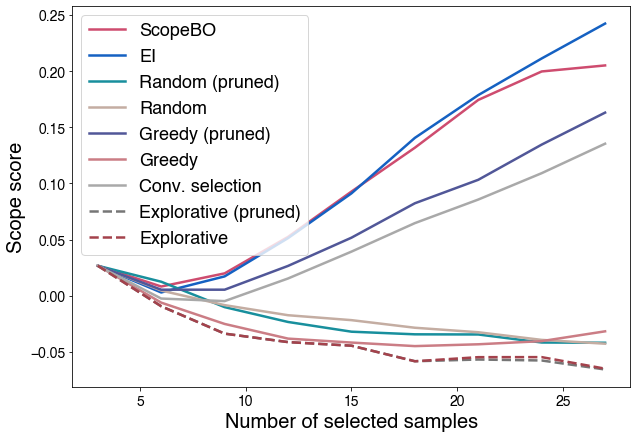

Average rate:


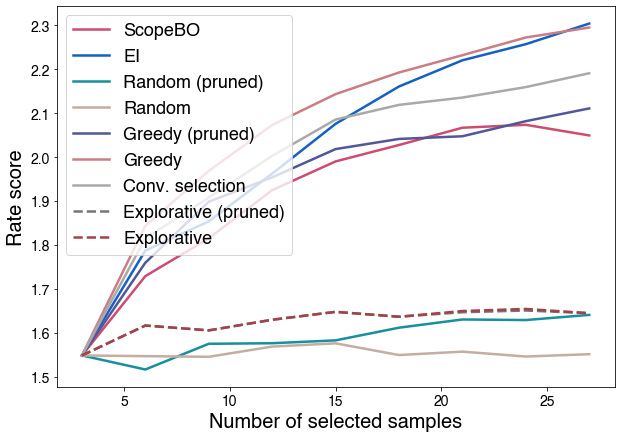

Vendi score:


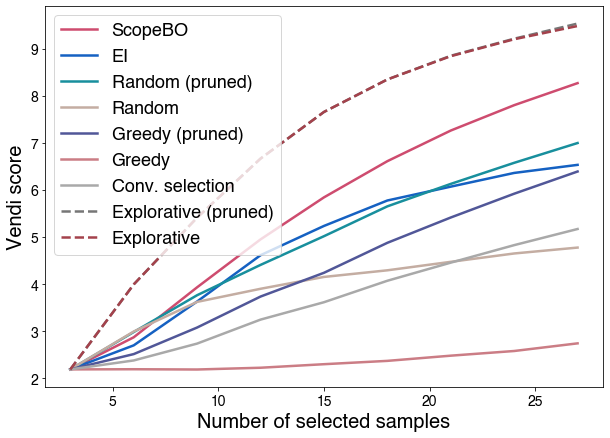

In [10]:
for type_results in ["Scope","Rate","Vendi"]:
    dfs = {}
    for acq in ["EI","Random","Greedy","Conv. selection","Explorative"]:
        if acq == "EI":
            acq_label = "balanced"
        elif acq == "Conv. selection":
            acq_label = "human-like-acq"
        else:
            acq_label = acq.lower()
        for pruning in [True,False]:
            if pruning:
                pruning_label = "_pruning"
                pruning_flag = "with"
            else:
                pruning_label = "_no-pruning"
                pruning_flag = "without"
            if acq == "Conv. selection":
                pruning_label = ""
            dfs_progress = Benchmark().progress_plot(budget=27, type_results= type_results,
                                     name_results=f"./Results_Data/scope_{acq_label}{pruning_label}",show_plot=False,bounds=bounds)
            dfs[acq+pruning_label] = dfs_progress["means"]
    df_combined = pd.concat(dfs,axis=1)
    df_combined.columns = [multiindex[0] for multiindex in df_combined.columns]
    df_combined.rename(columns={"EI_pruning":"ScopeBO"},inplace=True)
    df_combined = df_combined[["ScopeBO"] + [col for col in df_combined.columns if col != "ScopeBO"]]
    label_dict = {col: col for col in df_combined.columns}
    for key,val in label_dict.items():
        if "_no-pruning" in val:
            label_dict[key] = val.split("_")[0]
        elif "pruning" in val:
            label_dict[key] = val.split("_")[0] + " (pruned)"
    df_combined.rename(columns=label_dict,inplace=True)
    if type_results == "Rate":
        print("Average rate:")
    else:
        print(f"{type_results} score:")
    # Plot.
    plt.figure(figsize=(10,7))
    for j,col in enumerate(df_combined.columns):
        style = '-' if j <= 6 else '--' if j <= 13 else ':'
        plotting = df_combined[col][df_combined[col].notna()]
        plt.plot(plotting.index, plotting.values, label = col, color=all_colors[j], linestyle=style, linewidth=2.5)
    plt.xlabel('Number of selected samples',fontsize=20)
    plt.ylabel(f"{type_results} score",fontsize=20)
    plt.legend(fontsize=18)
    plt.show()

# Also run Doyle clustering for comparison

In [11]:
# A scaled dataframe containing the features was already generated in the beginning of this notebook. Check how many dimensions there are.
print(f"There are {len(df_data.columns)} dimensions in the dataset.")

There are 71 dimensions in the dataset.


In [12]:
# define the dimensionalities of the reduced representation to study
dims = [71, 70, 60, 50, 40, 35, 30, 25, 20, 15, 10, 5, 2]

# function to calculate silhouette scores
def silhouette_scores_hierarchical(data, n_cls_list):
    """helper function to compute a silhouette score for hierarchical clustering using Ward linkage"""
    z = linkage(data, method='ward')
    result = pd.Series(index=n_cls_list, dtype=float)
    for n_cls in n_cls_list:
        cls = fcluster(z, n_cls, criterion='maxclust')
        result.loc[n_cls] = silhouette_score(data, cls)
    return result

# dictionary to store data at different levels of dimensionality reduction
n_neighbors = int(np.sqrt(df_data.shape[1]))
dfs = {}
for dim in dims:
    key = f"umap{dim}"
    dfs[key] = pd.DataFrame(UMAP(n_components=dim, n_neighbors=n_neighbors,
                                    random_state=0).fit_transform(df_data),index=df_data.index)

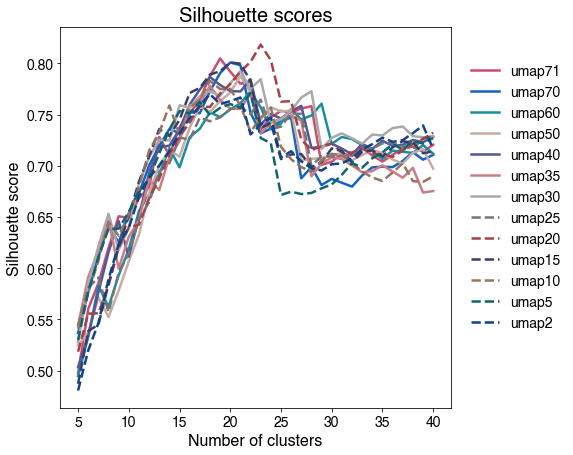

,Representation,Nr_clusters,Silh_score,Representation (min 15 clusters),Nr_clusters (min 15 clusters),Silh_score (min 15 clusters)
Results,umap20,23.0,0.818346,umap20,23.0,0.818346


In [13]:
# range of scope sizes to be studied
N_CLS_list = list(range(5,41))
# min number of clusters for the scope
min_clust = 15
# df to save the results of the silhouette score analysis
best_silh_scores = pd.DataFrame(np.nan,index=["Results"],columns=["Representation","Nr_clusters", "Silh_score",
                                                               f"Representation (min {min_clust} clusters)", 
                                                               f"Nr_clusters (min {min_clust} clusters)",
                                                               f"Silh_score (min {min_clust} clusters)"])

plt.figure(figsize=(7,7))
plt.title("Silhouette scores")
plt.xlabel("Number of clusters",fontsize=16)
plt.ylabel("Silhouette score",fontsize=16)

# populate silhouette scores for all number of clusters and all dimensionality reductions
silh_scores = pd.DataFrame(index=N_CLS_list)
for key, value in dfs.items():
    silh_scores[key] = silhouette_scores_hierarchical(value, N_CLS_list)
for j,col in enumerate(silh_scores.columns):
    style = '-' if j <= 6 else '--' if j <= 13 else ':'
    plotting = silh_scores[col][silh_scores[col].notna()]
    plt.plot(plotting.index, plotting.values, label = col, color=all_colors[j], linestyle=style, linewidth=2.5)

# record the representation that gives the best silhouette score
max_position = silh_scores.stack().idxmax()
best_silh_scores.loc["Results","Representation"] = max_position[1]
best_silh_scores.loc["Results","Nr_clusters"] = int(max_position[0])
best_silh_scores.loc["Results","Silh_score"] = silh_scores.max().max()
silh_scores_pruned = silh_scores.loc[silh_scores.index >= min_clust]
max_position_pruned = silh_scores_pruned.stack().idxmax()
best_silh_scores.loc["Results",f"Representation (min {min_clust} clusters)"] = max_position_pruned[1]
best_silh_scores.loc["Results",f"Nr_clusters (min {min_clust} clusters)"] = int(max_position_pruned[0])
best_silh_scores.loc["Results",f"Silh_score (min {min_clust} clusters)"] = silh_scores_pruned.max().max()
plt.legend(loc='center left',
           frameon =False,
           bbox_to_anchor=(1.02, 0.555))
plt.show()

best_silh_scores

In [14]:
embedding = best_silh_scores.loc["Results",f"Representation (min {min_clust} clusters)"]
nr_clusters = best_silh_scores.loc["Results",f"Nr_clusters (min {min_clust} clusters)"]

# Clustering
z = hierarchy.linkage(dfs[embedding],method ="ward",metric="euclidean")
clusters = hierarchy.fcluster(z,nr_clusters,criterion="maxclust")

# Assign to samples
df_data["clusters"] = clusters
df_umap["clusters"] = clusters

Visualization of the clusters:


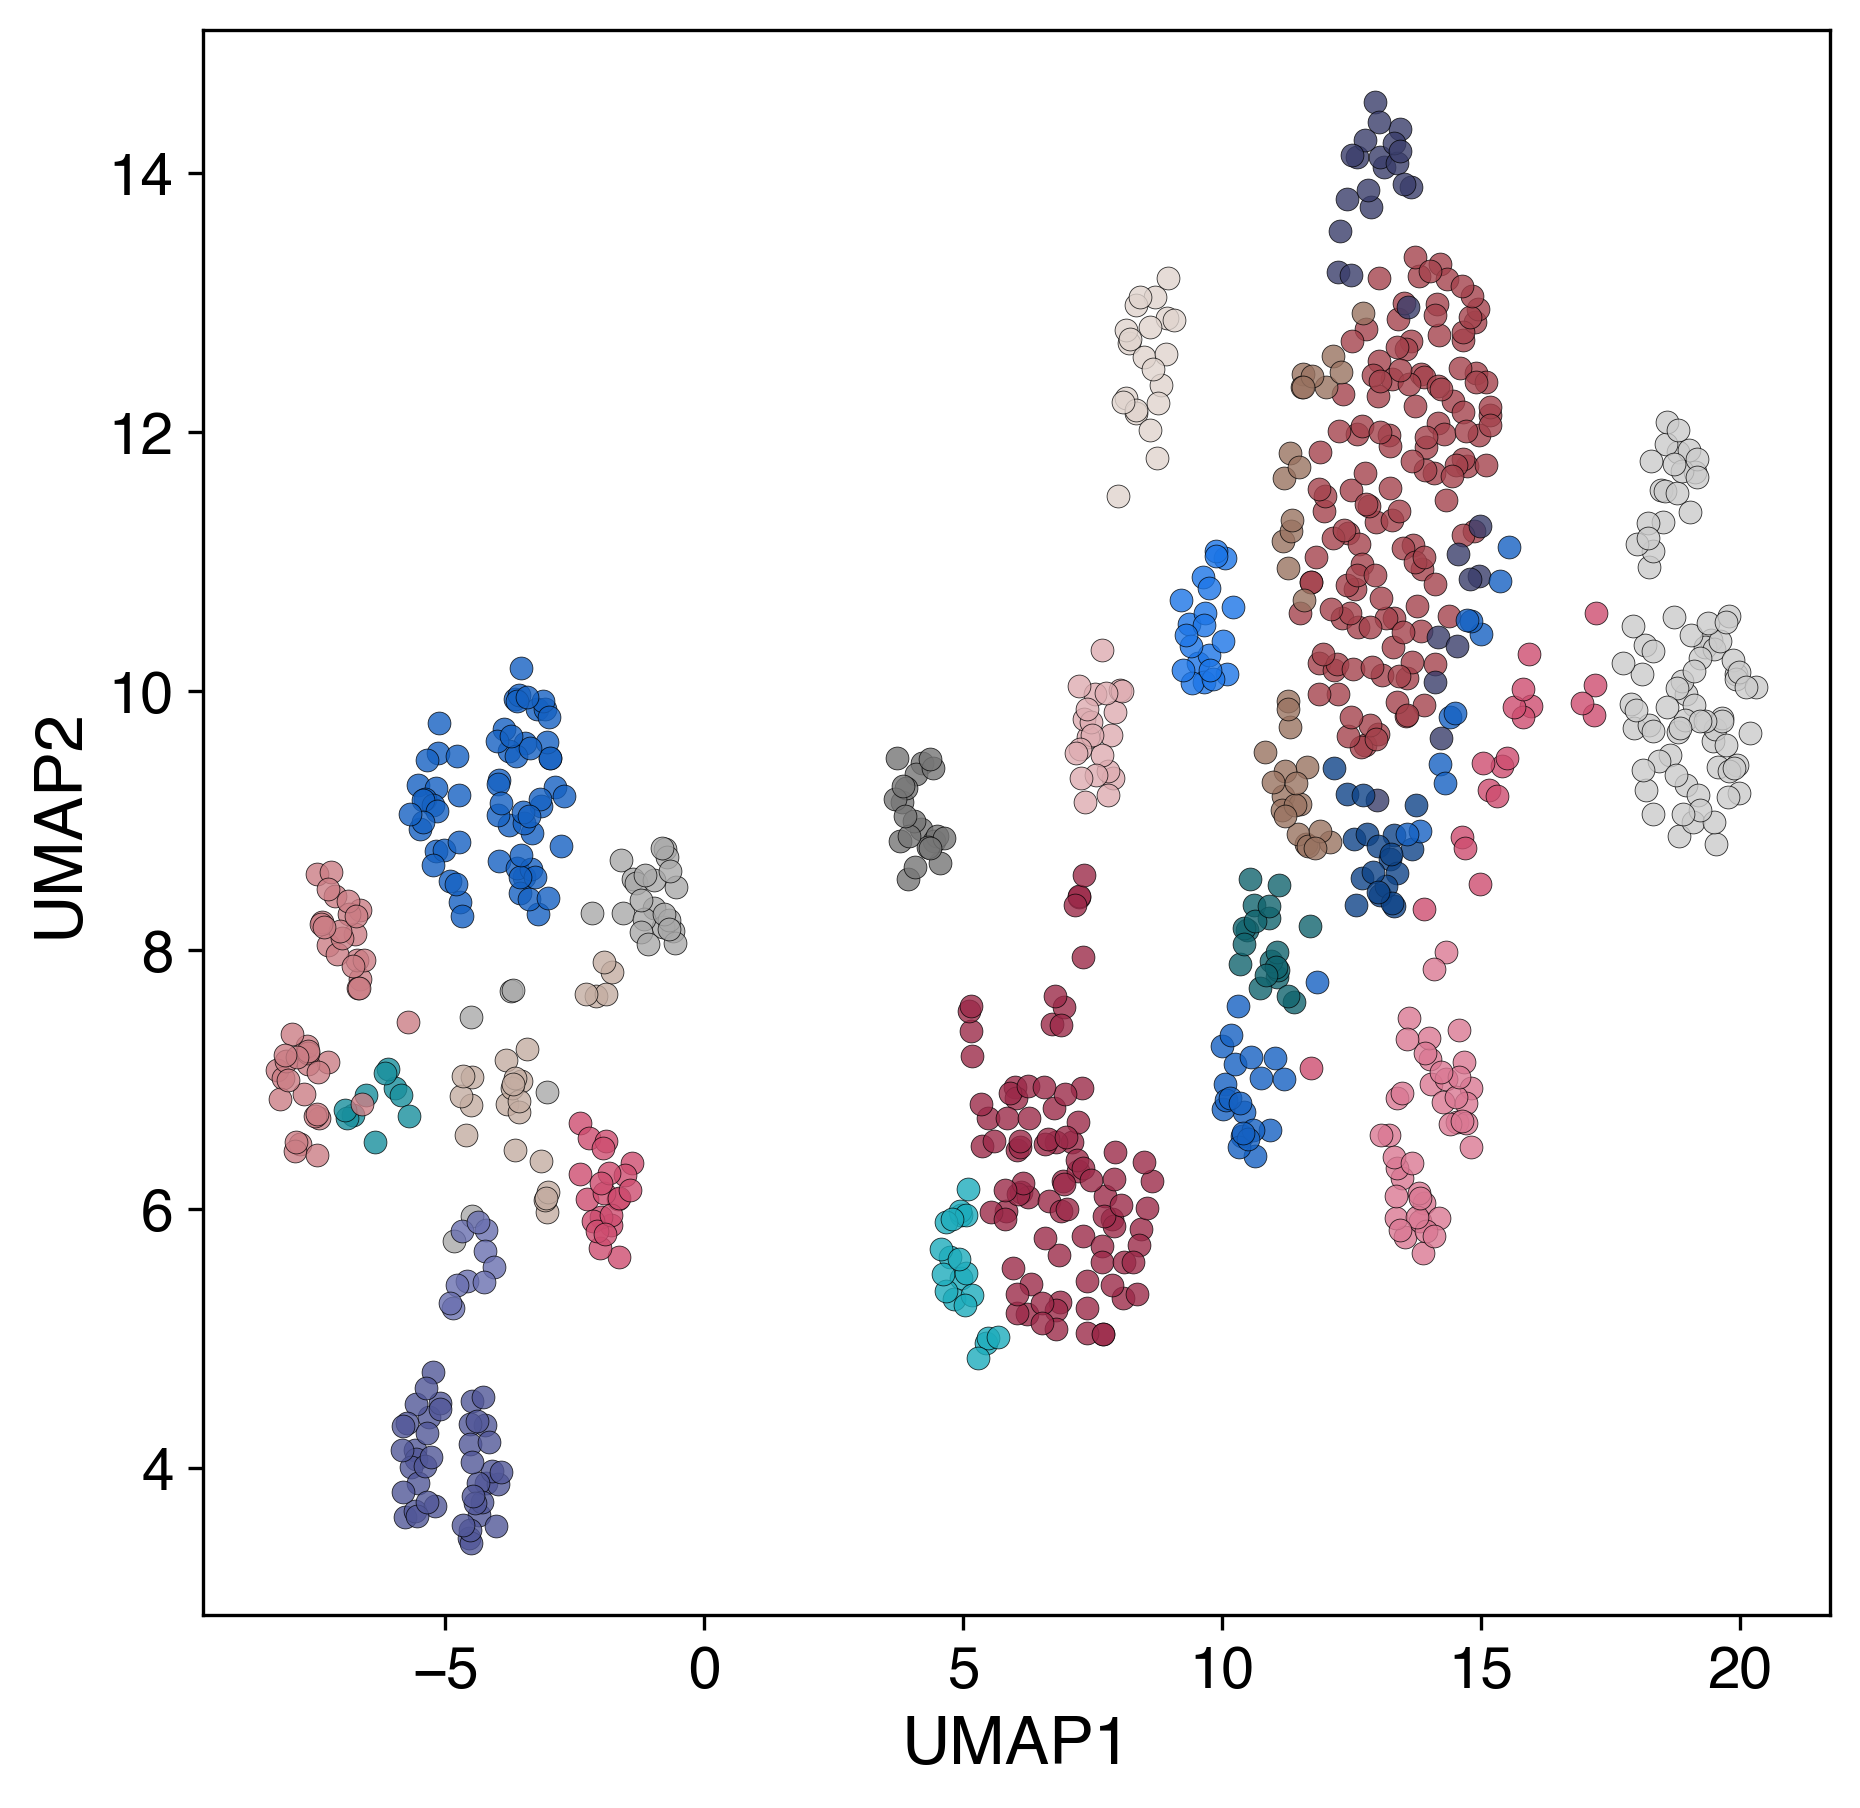

Please note that some colors only differ in the shade due to the large number of clusters. Some colors are also used for two clusters.


In [15]:
# draw the clusters
print("Visualization of the clusters:")

# making sure there are enough colors
all_colors = all_colors * 4

plt.figure(figsize=(7,7),dpi=300)
plt.xlabel("UMAP1",fontsize=16)
plt.ylabel("UMAP2",fontsize=16)

for cluster_id in sorted(df_umap['clusters'].unique()):
    color_id = cluster_id-1  # colors are zero-index, but clusters one-indexed
    cluster_data = df_umap[df_umap['clusters'] == cluster_id]
    plt.scatter(
        cluster_data['UMAP1'], cluster_data['UMAP2'],
        color=all_colors[color_id],
        label=f'Cluster {cluster_id}',
        s=30, alpha=0.8, edgecolor='k', linewidth=0.2
    )
plt.show()
print("Please note that some colors only differ in the shade due to the large number of clusters. Some colors are also used for two clusters.")

In [16]:
# function to calculate the scope score
def calculate_scope_score(av_rate,Vendi_score,bounds):
    scaled_rate = (av_rate - bounds["rate"][1])/(bounds["rate"][0] - bounds["rate"][1])
    scaled_Vendi = (Vendi_score - bounds["vendi"][1])/(bounds["vendi"][0] - bounds["vendi"][1])

    return scaled_rate * scaled_Vendi

In [17]:
# calculate the center-most point of each cluster and the Vendi score for the resulting samples
scope_results = pd.DataFrame(np.nan,index=["Results"],columns=["Average rate","Vendi score","Scope score"])

cluster_rates = [] # list to save the rate
df_vendi = df_labelled.copy(deep=True)
df_vendi["rate"] = "PENDING"  # reset the rate data so that only the selected points will have a rate
for cluster in range(max(df_data["clusters"].unique())):  # loop through all clusters
    cluster = cluster+1  # +1 because the range object is 0-indexed whereas the cluster are 1-indexed
    df_cluster = df_data.loc[df_data["clusters"]== cluster]  # look at the points in the current cluster
    df_cluster = df_cluster.drop(columns=["clusters"])  # drop the cluster column to only keep the features (df_clustering did not contain the rate data)
    centroid = df_cluster.mean().values  # this is the center of the cluster
    distances = cdist(df_cluster,[centroid],metric="cityblock").flatten()  # calculate the distances to the center
    df_cluster["distances"] = distances
    centermost_point = df_cluster[df_cluster["distances"] == df_cluster["distances"].min()].index.to_list()[0]  # get the center-most point
    rate_clusterpoint = df_labelled.at[centermost_point,"rate"]  # get the rate data for the center-most point
    df_vendi.loc[centermost_point,"rate"] = "1"  # put a label for the vendi score calculation (value is not important)
    cluster_rates.append(rate_clusterpoint)  # save the point
av_rate = sum(cluster_rates)/len(cluster_rates)

scope_results.loc["Results","Average rate"] = av_rate
df_vendi.to_csv(wdir.joinpath("df_clustering_vendi.csv"),index=True,header=True)  # save the file (as the Vendi score calculation needs a file as input)
Vendi_score = ScopeBO().get_vendi_score(objectives=["rate"],directory=".",filename="df_clustering_vendi.csv")  # calculate the vendi score
scope_results.loc["Results","Vendi score"] = Vendi_score
scope_score = calculate_scope_score(av_rate,Vendi_score,bounds)
scope_results.loc["Results","Scope score"] = scope_score

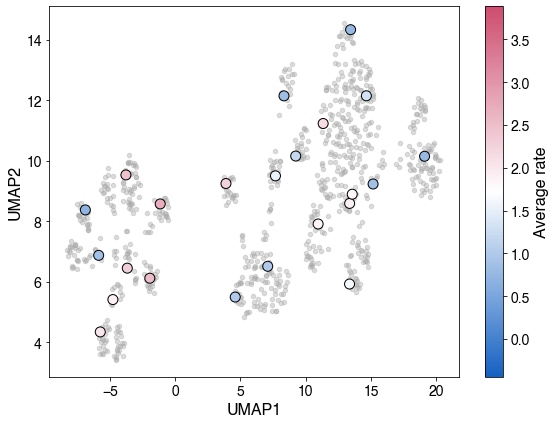

Scope results:


,Average rate,Vendi score,Scope score
Results,1.581781,5.357363,-0.039548


In [18]:
plt.figure(figsize=(8,6))
plt.xlabel("UMAP1",fontsize=16)
plt.ylabel("UMAP2",fontsize=16)

# only keep the objective label for evaluated points
df_umap["rate"] = df_labelled["rate"]

for idx in df_vendi.index:
    if df_vendi.loc[idx,"rate"] == "PENDING":
        df_umap.loc[idx,"rate"] = "PENDING"

# Separate numeric and non-numeric (e.g., "PENDING") entries
df_numeric = df_umap[pd.to_numeric(df_umap['rate'], errors='coerce').notna()].copy()
df_numeric['rate'] = df_numeric['rate'].astype(float)
df_pending = df_umap[pd.to_numeric(df_umap['rate'], errors='coerce').isna()]

# Define colormap and normalization
vmin = df_labelled['rate'].min()
vmax = df_labelled['rate'].max()
norm = plt.Normalize(vmin, vmax)
cmap = sns.color_palette("Doyle_cont", as_cmap=True)

# Plot non-numeric entries ("PENDING")
plt.scatter(df_pending["UMAP1"], df_pending["UMAP2"], color=all_colors[6], s=20, alpha=0.4, label="PENDING")
# Plot numeric entries
scatter_numeric = plt.scatter(df_numeric["UMAP1"],df_numeric["UMAP2"],c=df_numeric["rate"],
                              cmap=cmap,norm=norm,s=100,alpha=1,edgecolor='k',linewidth=1)
# Add colorbar
cbar = plt.colorbar(scatter_numeric)
cbar.set_label("Average rate")

plt.tight_layout()
plt.show()
print("Scope results:")
scope_results

In [19]:
print("Normalization bounds for comparison:")
pd.DataFrame.from_dict(bounds)

Normalization bounds for comparison:


,rate,vendi
0,2.763604,10.736517
1,1.726473,3.229215


In [20]:
print("Average results for ScopeBO:")
_,dfs_raw_data = Benchmark().get_metric_overview(budget=27, type_results= "scope",
                        name_results=f"./Results_Data/scope_balanced_pruning",
                        bounds={"rate":rate_bounds,"vendi":vendi_bounds})
df_scopebo = pd.DataFrame(np.mean(np.stack(list(dfs_raw_data["b3_V13"].values())),axis=0),columns=dfs_raw_data["b3_V13"][0].columns)
df_scopebo.iloc[-1]

Average results for ScopeBO:


vendi    8.267486
rate     2.049519
scope    0.205098
Name: 8, dtype: float64

Doyle clustering scope:


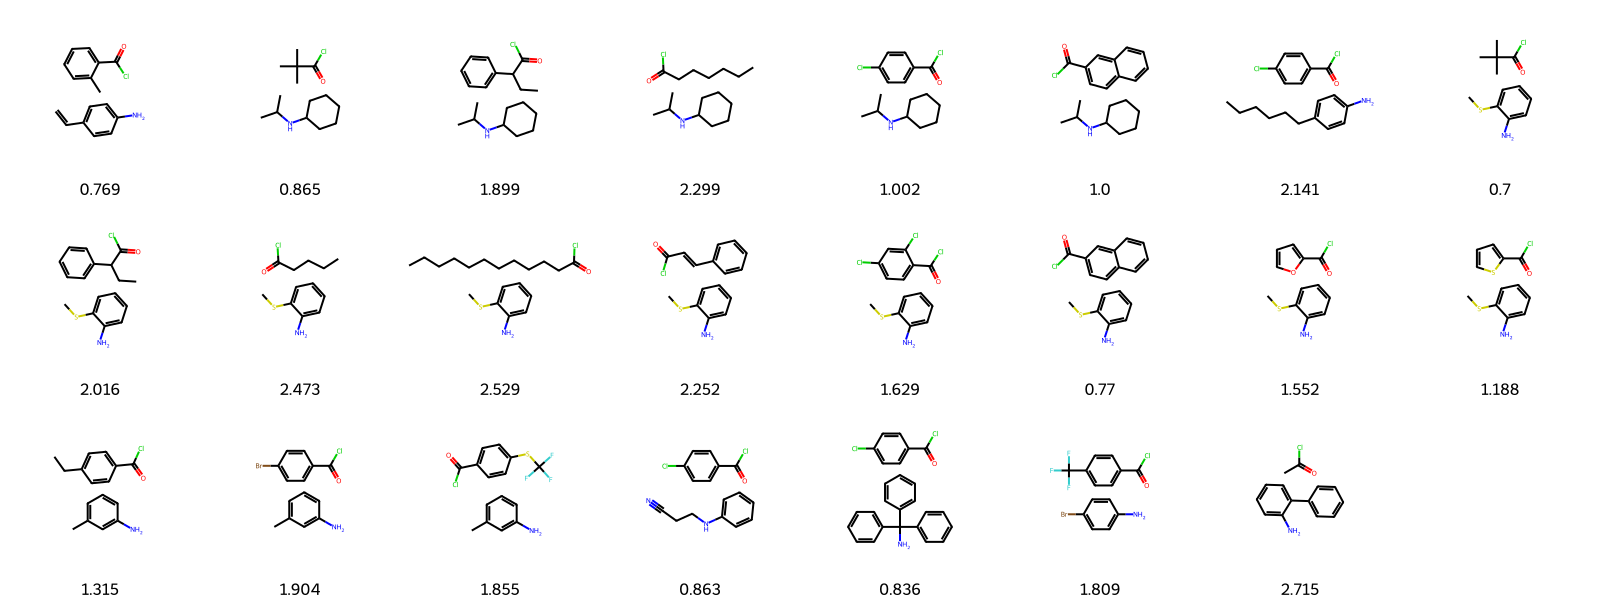

In [21]:
# show the selected molecules
print(f"Doyle clustering scope:")
df_selected = df_umap.loc[df_umap["rate"] != "PENDING"]
doyle_scope = {idx: df_selected.loc[idx,"rate"] for idx in df_selected.index}
depiction = Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smi) for smi in doyle_scope.keys()],
    molsPerRow=8,
    subImgSize=(200, 200),
    legends=[f"{round(val,3)}" for val in doyle_scope.values()]
    )
display(depiction)

In [22]:
df_umap.to_csv(f"./Results_Data/Cluster_Scopes/scope_doyle_samples.csv",index=True,header=True)
# save the results for the scopes
scope_results.to_csv(f"./Results_Data/Cluster_Scopes/results_doyle.csv",index=True,header=True)

### Glorius clustering

A scope for the datasets is generated using the clustering approach introduced by Glorius and co-workers (ACS Cent. Sci. 2024, 10, 899-906). As the clustering algorithm is not compatible with smiles of substrate combinations (here: acid chloride + amine), the smiles of the reaction products (amides) are used as input for the algorithm.

reaction SMARTS template for the generation of amide products


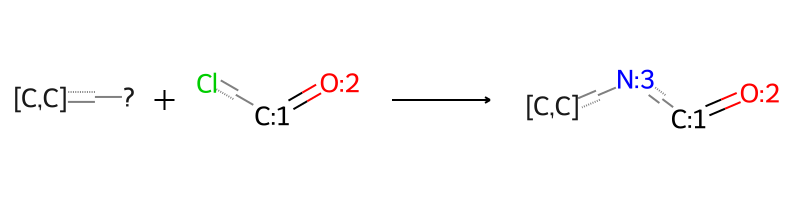

In [23]:
# define a reaction template to get the amide smiles from the starting materials

print("reaction SMARTS template for the generation of amide products")
reaction_smarts = '[N;H1,H2:3][c,C:4].[C:1](=[O:2])[Cl]>>[C:1](=[O:2])[N:3][c,C:4]'
reaction = AllChem.ReactionFromSmarts(reaction_smarts)
Draw.ReactionToImage(reaction)

In [24]:
# get the amide product smiles
df_glorius = df_labelled.copy()
sm_to_prod = {}
for idx in df_glorius.index:
    sm_mol = Chem.MolFromSmiles(idx)
    prod_mol = reaction.RunReactants((Chem.GetMolFrags(sm_mol, asMols=True)))[0][0]
    Chem.SanitizeMol(prod_mol)
    sm_to_prod[idx] = Chem.MolToSmiles(prod_mol)

# reassign index with the product smiles
df_glorius.index = list(sm_to_prod.values())
df_glorius.head()

,E_amine,ES_root_dipole_amine,ES_root_electronic_spatial_extent_amine,ES_root_molar_volume_amine,E_thermal_correction_amine,dipole_amine,electronegativity_amine,hardness_amine,homo_energy_amine,molar_mass_amine,...,O1_VBur,Cl1_APT_charge,Cl1_Mulliken_charge,Cl1_NMR_anisotropy,Cl1_NMR_shift,Cl1_NPA_Rydberg,Cl1_NPA_charge,Cl1_NPA_core,Cl1_VBur,rate
CC(=O)N(C1CCCCC1)C1CCCCC1,-524.764882,2.280902,3286.519376,1673.698242,0.352139,0.8732,0.0799,0.13752,-0.21742,181.3204,...,0.347231,-0.497062,-0.249833,776.780200,462.790900,0.021580,-0.120050,9.999640,0.359031,2.715060
CC(C)(C)C(=O)N(C1CCCCC1)C1CCCCC1,-524.764882,2.280902,3286.519376,1673.698242,0.352139,0.8732,0.0799,0.13752,-0.21742,181.3204,...,0.412996,-0.486258,-0.243396,657.140700,517.831400,0.020140,-0.114230,9.999640,0.411737,0.793687
CC(C)(C)c1ccc(C(=O)N(C2CCCCC2)C2CCCCC2)cc1,-524.764882,2.280902,3286.519376,1673.698242,0.352139,0.8732,0.0799,0.13752,-0.21742,181.3204,...,0.385780,-0.515560,-0.254743,652.169429,528.632604,0.020760,-0.106427,9.999660,0.382150,0.610277
CC(C)C(=O)N(C1CCCCC1)C1CCCCC1,-524.764882,2.280902,3286.519376,1673.698242,0.352139,0.8732,0.0799,0.13752,-0.21742,181.3204,...,0.392440,-0.495845,-0.246018,714.251382,492.332221,0.020565,-0.118478,9.999640,0.387452,1.280674
CCC(C(=O)N(C1CCCCC1)C1CCCCC1)c1ccccc1,-524.764882,2.280902,3286.519376,1673.698242,0.352139,0.8732,0.0799,0.13752,-0.21742,181.3204,...,0.434351,-0.476558,-0.228389,717.517616,464.585083,0.021030,-0.095897,9.999616,0.388169,1.761765


In [25]:
# save the product names as a txt file (required input for the webapp by Glorius and co-workers)
pd.DataFrame(sm_to_prod.values(),index=None,columns=None).to_csv("./Results_Data/Cluster_Scopes/glorius_input.txt",index=False,header=False)

The scope was created using the webapp https://pharmascope.uni-muenster.de/ using the recommended settings (15 clusters using the provided standard UMAP 0_ECFP_2_512_UMAP_2dim_30nb_0.1mindist_jaccard.model). A list of the product SMILES strings of all amides dataset was provided as the input and the top-1 substrate per cluster was requested. As this however only generated 10 samples instead of the expected 15, we increased the number of clusters until 15 samples were generated. This was the case when 23 clusters were requested.

In [26]:
# read in the results
df_clustering = pd.read_csv(f"./Results_Data/Cluster_Scopes/glorius_samples.csv", index_col=0,header=0)
df_clustering.set_index("smiles",inplace=True)
df_clustering.head()

,mol_dist_from_center,mol_id,umap_1,umap_2
smiles,,,,
CC1CCCC(C)N1C(=O)C(C)(C)C,0.177118,93,10.072438,7.708652
CCC(C(=O)N1C(C)CN(C(=O)OC(C)(C)C)CC1C)c1ccccc1,0.922156,92,10.518185,8.895071
CC(C)C(=O)N(C(C)C)C(C)C,0.521961,573,15.116146,4.344337
CCCCC(CC)C(=O)N1C(C)CCCC1C,0.150883,645,13.653988,4.529599
CCCCC(CC)C(=O)N(C(C)C)C(C)C,0.149539,377,13.944460,3.751988


In [27]:
# assign the samples (by removing the yields for all non-selected compounds)
df_glorius.loc[~df_glorius.index.isin(df_clustering.index.to_list()),"rate"] = "PENDING"
# Safety check
print(f"After removing rate data for all compounds that were not selected, {len(df_glorius[df_glorius['rate'] != 'PENDING'])}"\
      " samples still have rate data.")

After removing rate data for all compounds that were not selected, 15 samples still have rate data.


Glorius clustering scope:


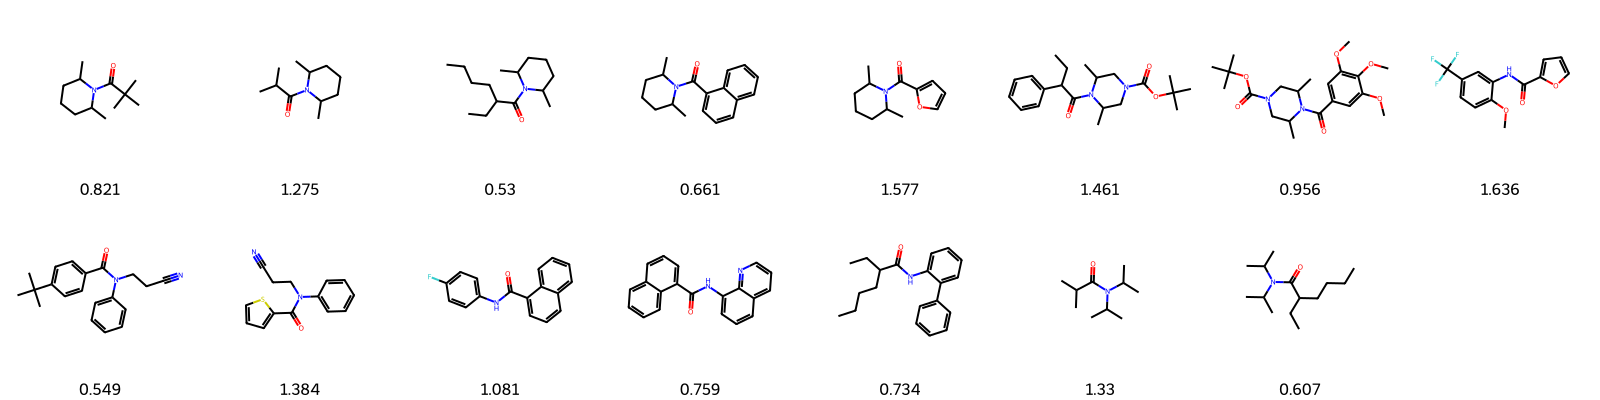

In [28]:
# draw the scope
print(f"Glorius clustering scope:")
df_selected = df_glorius.loc[df_glorius["rate"] != "PENDING"]
glorius_scope = {idx: df_selected.loc[idx,"rate"] for idx in df_selected.index}
depiction = Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smi) for smi in glorius_scope.keys()],
    molsPerRow=8,
    subImgSize=(200, 200),
    legends=[f"{round(val,3)}" for val in glorius_scope.values()]
    )
display(depiction)

In [29]:
# visualize on a UMAP

df_umap_glorius = df_umap.copy()
df_umap_glorius = df_umap_glorius.drop(columns=["clusters","rate"]) # reset the UMAP df (still had data from Doyle clustering)

# change the starting material index to a product index
df_umap_glorius.index = df_umap_glorius.index.map(sm_to_prod)

# assign the samples
df_umap_glorius["rate"] = "PENDING"
for smiles, rate in glorius_scope.items():
    df_umap_glorius.loc[smiles,"rate"] = rate

In [30]:
# calculate av rate, Vendi score and scope score
scope_results_glorius = pd.DataFrame(np.nan,index=range(1),columns=["Average rate","Vendi score","Scope score"])
av_rate_glorius = df_umap_glorius[df_umap_glorius["rate"] != "PENDING"]["rate"].mean()
scope_results_glorius["Average rate"] = av_rate_glorius
df_umap_glorius.to_csv("df_vendi.csv",index=True,header=True)
vendi_score_glorius = ScopeBO().get_vendi_score(objectives=["rate"], filename="df_vendi.csv")
scope_results_glorius["Vendi score"] = vendi_score_glorius
scope_results_glorius["Scope score"] = calculate_scope_score(av_rate=av_rate_glorius, Vendi_score=vendi_score_glorius, bounds=bounds)

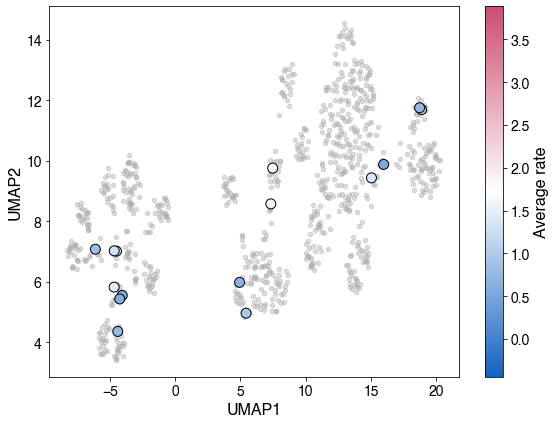

Scope results:


,Average rate,Vendi score,Scope score
0,1.024137,1.761047,0.132435


In [31]:
plt.figure(figsize=(8,6))
plt.xlabel("UMAP1",fontsize=16)
plt.ylabel("UMAP2",fontsize=16)

# Separate numeric and non-numeric (e.g., "PENDING") entries
df_numeric = df_umap_glorius[pd.to_numeric(df_umap_glorius['rate'], errors='coerce').notna()].copy()
df_numeric['rate'] = df_numeric['rate'].astype(float)
df_pending = df_umap_glorius[pd.to_numeric(df_umap_glorius['rate'], errors='coerce').isna()]

# Define colormap and normalization
vmin = df_labelled['rate'].min()
vmax = df_labelled['rate'].max()
norm = plt.Normalize(vmin, vmax)
cmap = sns.color_palette("Doyle_cont", as_cmap=True)

# Plot non-numeric entries ("PENDING")
plt.scatter(df_pending["UMAP1"], df_pending["UMAP2"], color=all_colors[6], s=20, alpha=0.4, label="PENDING")
# Plot numeric entries
scatter_numeric = plt.scatter(df_numeric["UMAP1"],df_numeric["UMAP2"],c=df_numeric["rate"],
                              cmap=cmap,norm=norm,s=100,alpha=1,edgecolor='k',linewidth=1)
# Add colorbar
cbar = plt.colorbar(scatter_numeric)
cbar.set_label("Average rate")

plt.tight_layout()
plt.show()
print("Scope results:")
scope_results_glorius

In [32]:
bounds

{'rate': (2.7636041685101214, 1.7264725188943717),
 'vendi': (10.736517101249781, 3.229214944957466)}

The scope score for the Glorius clustering is positive because both the normalized average rate and Vendi score are negative (values are below the normalization bounds). As the score is therefore misleading, we re-assigned it manually as 0.

In [33]:
scope_results_glorius["Scope score"] = 0
scope_results_glorius

,Average rate,Vendi score,Scope score
0,1.024137,1.761047,0


### Benchmark comparisons

Collect the data

In [34]:
acq_fct = ["EI","Random","Greedy","Conv. selection","Explorative"]
pruning_opt = [False,True]

map_data = {}
std_data = {}
for acq in acq_fct:
    if acq.lower() == "ei":
        acq_label = "balanced"
    elif acq == "Conv. selection":
        acq_label =  "human-like-acq"
    else:
        acq_label = acq.lower()
    for pruning in [True,False]:
        if pruning:
            pruning_label = "_pruning"
        else:
            pruning_label = "_no-pruning"
        if acq == "Conv. selection":
            pruning_label = ""
        run_results = []
        std_results = []
        for type_results in ["Objective","Vendi","Scope"]:
            dfs_scaled,_ = Benchmark.get_metric_overview(budget=27,type_results=type_results,
                                            name_results=f"Results_Data/scope_{acq_label}{pruning_label}",
                                            scope_method="product",
                                            bounds = bounds, directory=".")
            run_results.append(dfs_scaled["means"].iloc[-1,0])  # save the last mean which is the result at the end of the scope
            std_results.append(dfs_scaled["stdev"].iloc[-1,0])  # same for the standard deviation of the result
        map_data[f"{acq}{pruning_label}"] = run_results
        std_data[f"{acq}{pruning_label}"] = std_results
map_df = pd.DataFrame.from_dict(map_data)
std_df = pd.DataFrame.from_dict(std_data)
map_df.rename(columns={"EI_pruning":"ScopeBO"},inplace=True)
std_df.rename(columns={"EI_pruning":"ScopeBO"},inplace=True)
map_df.rename(columns=label_dict,inplace=True)
std_df.rename(columns=label_dict,inplace=True)

# add clustering data
# col 0 is averaged objectives; 1 is Vendi score; 2 is scope score
map_df["Doyle_clustering"] = [scope_results.iloc[0,0],scope_results.iloc[0,1],scope_results.iloc[0,2]]
std_df["Doyle_clustering"] = [0,0,0]  # no std as only one deterministic run
map_df["Glorius_clustering"] = [scope_results_glorius.iloc[0,0],scope_results_glorius.iloc[0,1],scope_results_glorius.iloc[0,2]]
std_df["Glorius_clustering"] = [0,0,0]  # no std as only one deterministic run

new_index = ["Average rate", "Vendi score", "Scope score"]
map_df.index = new_index
std_df.index = new_index

In [35]:
# calculate the average rate and Vendi score across the whole dataset

full_av_rate = df_labelled["rate"].mean()
full_vendi_score = ScopeBO().get_vendi_score(objectives=["rate"],filename="./SB_dset.csv")
print("Average rate across the entire dataset:", full_av_rate)
print("Vendi score across the entire dataset:", full_vendi_score)

Average rate across the entire dataset: 1.5554184839890783
Vendi score across the entire dataset: 7.981971795558207


Visualize the results

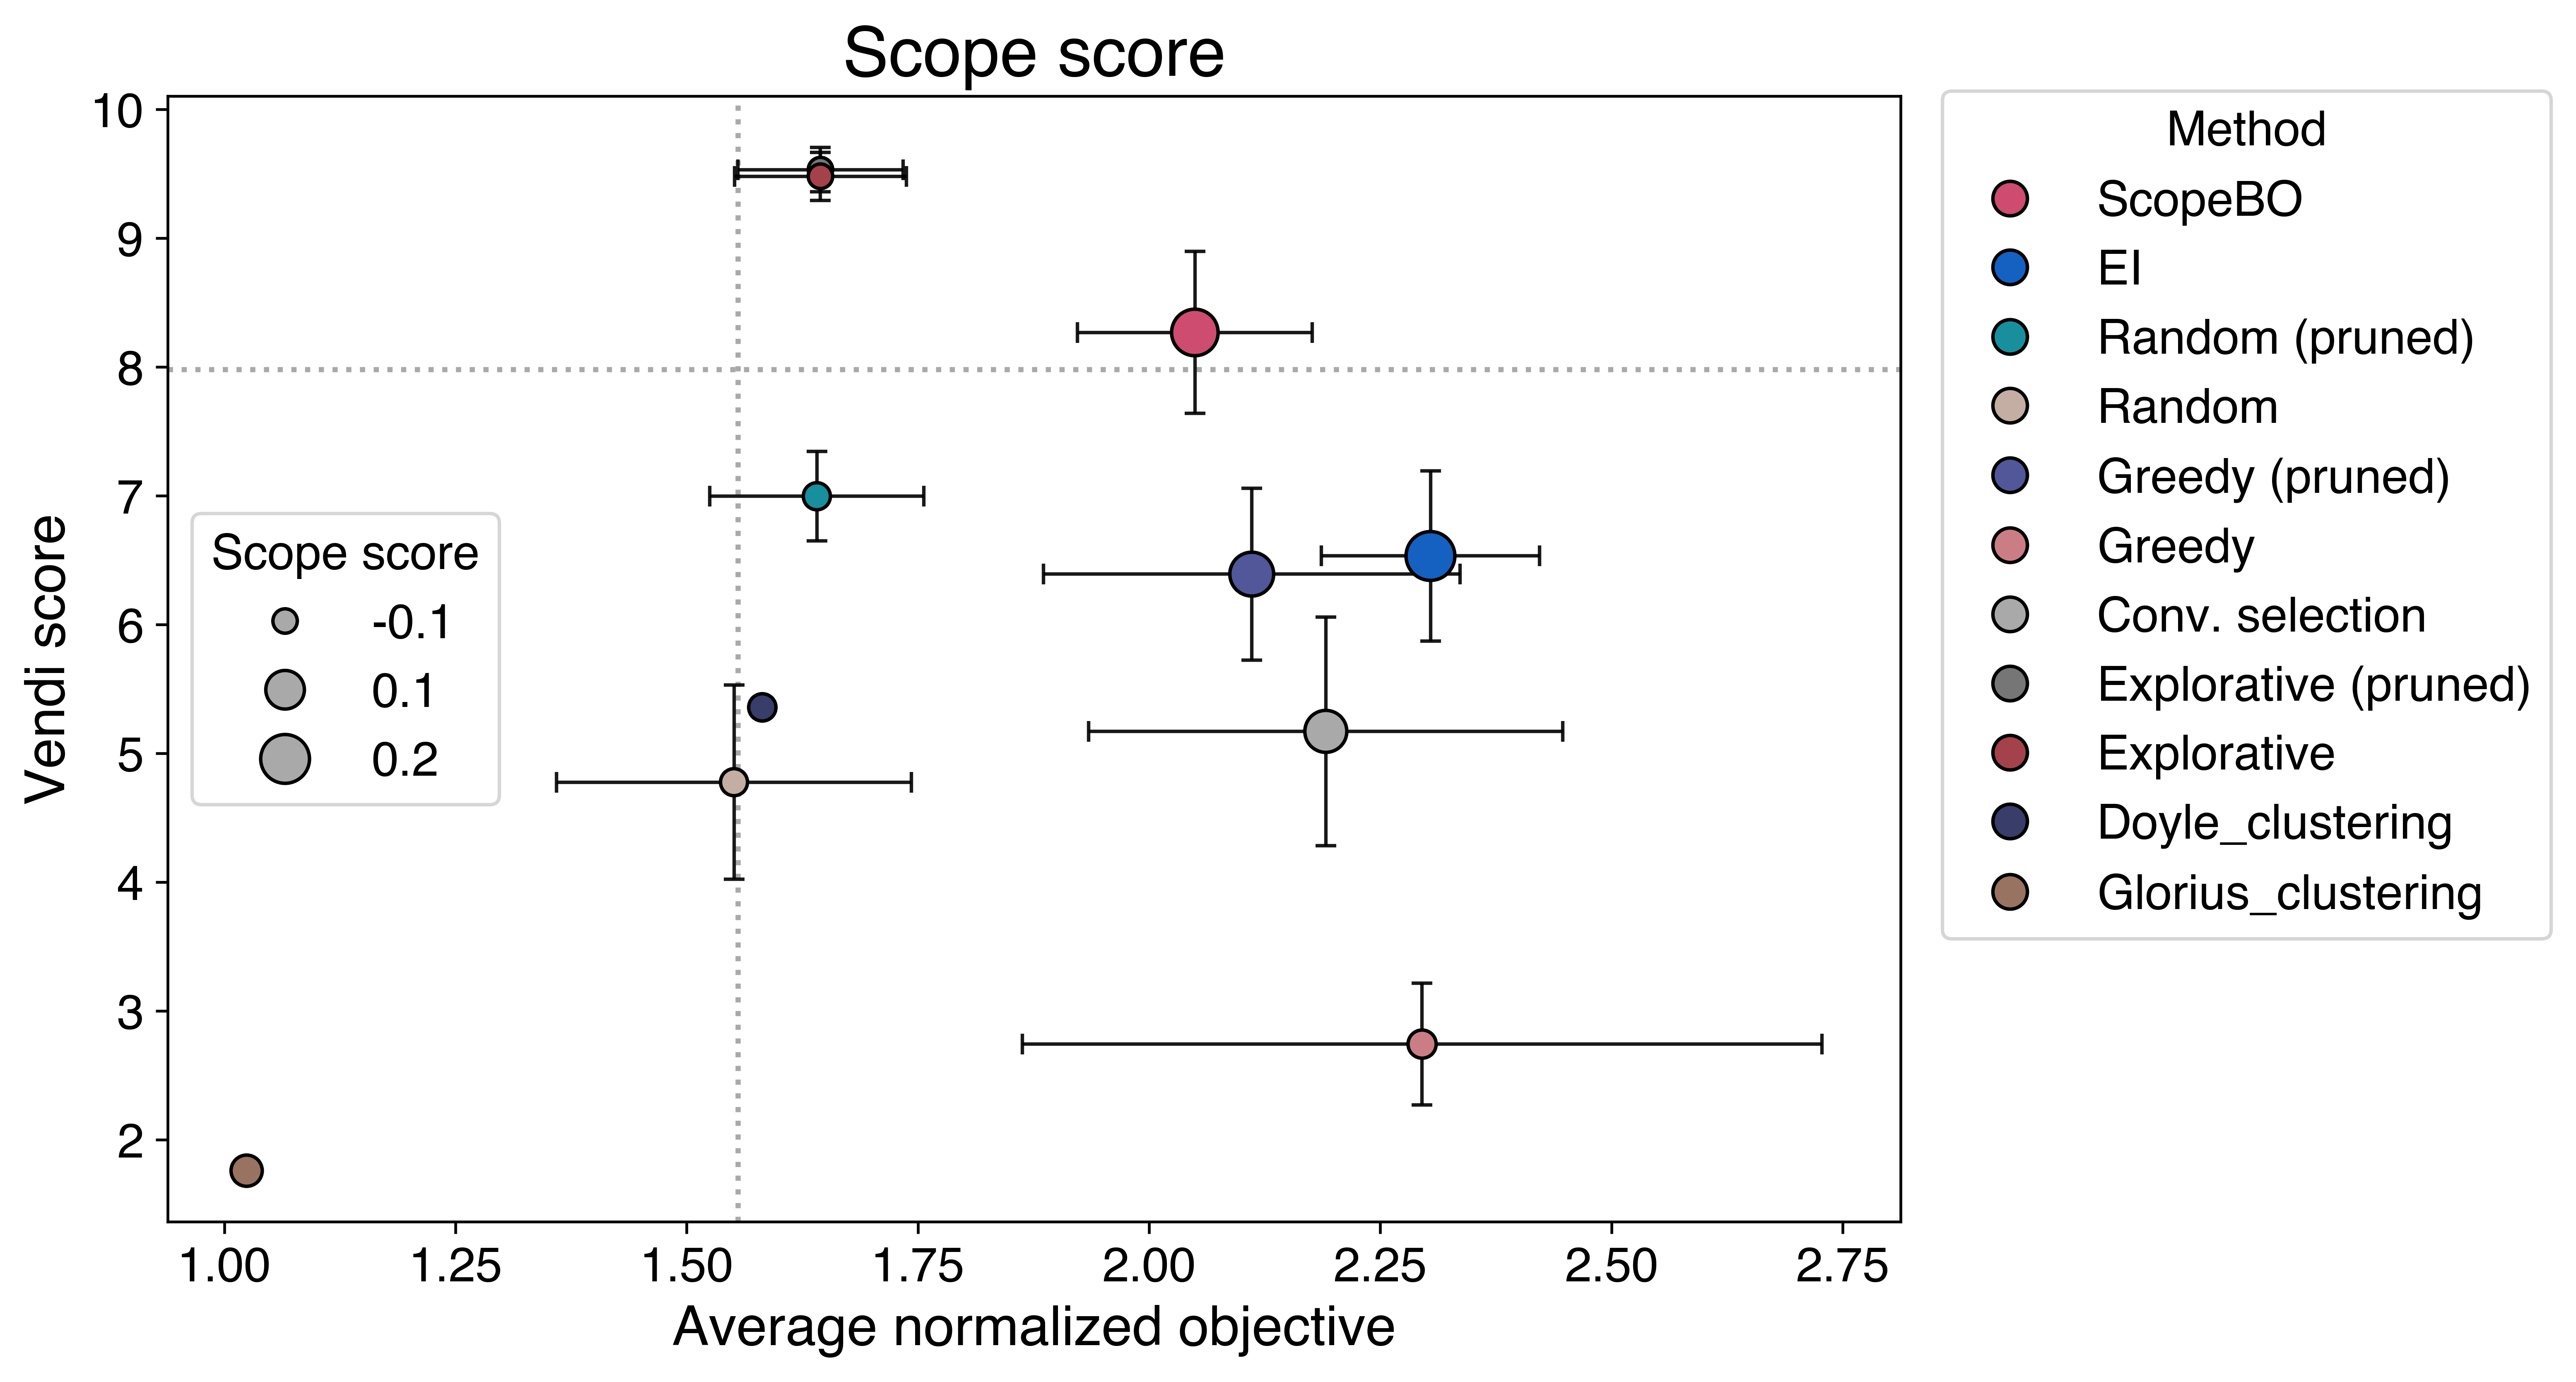

,Average rate,Vendi score,Scope score
ScopeBO,2.05 ± 0.127,8.267 ± 0.629,0.205 ± 0.079
EI,2.304 ± 0.118,6.532 ± 0.659,0.242 ± 0.059
Random (pruned),1.641 ± 0.116,6.996 ± 0.347,-0.042 ± 0.057
Random,1.551 ± 0.192,4.777 ± 0.754,-0.043 ± 0.053
Greedy (pruned),2.111 ± 0.225,6.392 ± 0.667,0.163 ± 0.094
Greedy,2.295 ± 0.432,2.744 ± 0.472,-0.032 ± 0.042
Conv. selection,2.191 ± 0.256,5.171 ± 0.887,0.135 ± 0.096
Explorative (pruned),1.645 ± 0.089,9.532 ± 0.172,-0.066 ± 0.071
Explorative,1.645 ± 0.093,9.48 ± 0.186,-0.065 ± 0.073
Doyle_clustering,1.582 ± 0,5.357 ± 0,-0.04 ± 0


NOTE: the scope score for the Glorius clustering was manually set to 0 as the low metric values incorrectly
provided a positive score (negative * negative = positive).


In [61]:
# Plot the results
x = map_df.iloc[0]
y = map_df.iloc[1]
xerr = std_df.iloc[0]
yerr = std_df.iloc[1]
raw_size_data = map_df.iloc[2]

size_min, size_max = 50, 200
data_min, data_max= raw_size_data.min(), raw_size_data.max()
sizes = size_min + (raw_size_data - data_min) * (size_max - size_min) / (data_max - data_min)

# simplify the labels for the legend
labels = map_df.columns
labels = list(labels)
for i,val in enumerate(labels):
    if val == "EI_pruning":
        labels[i] = "ScopeBO"
    elif "no-pruning" in val:
        labels[i] = val.split("_")[0]
    elif "_pruning" in val:
        labels[i] = val.split("_")[0] + " (pruned)"
map_df.columns = labels


color_map = {label: all_colors[i] for i, label in enumerate(labels)}
colors = [color_map[label] for label in labels]
alpha_val = 1

plt.figure(figsize=(9,6),dpi=600)
plt.title(f"Performance map")
plt.scatter(x, y, s=sizes, alpha=alpha_val, c = colors, edgecolors="k",zorder=2)
# Add error bars
plt.errorbar(
    x, y,
    xerr=xerr,
    yerr=yerr,
    fmt='none',
    ecolor='black',
    elinewidth=1,
    capsize=3,
    alpha=0.9,
    zorder=1
)

# lines for the full dataset metrics
plt.axhline(y=full_vendi_score, color=all_colors[6], linestyle=':', linewidth=1.5, zorder=0)
plt.axvline(x=full_av_rate, color=all_colors[6], linestyle=':', linewidth=1.5, zorder=0)


plt.xlabel('Average normalized objective')
plt.ylabel('Vendi score')
plt.title('Scope score')

# legend for the methods
color_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=label,
        markerfacecolor=color_map[label],
        alpha=alpha_val,
        markeredgecolor='k',
        markersize=10
    )
    for label in labels
]

# legend for scope score
# Choose representative raw size values
size_legend_values = np.linspace(raw_size_data.min(), raw_size_data.max(), 3)
size_legend_sizes = size_min + (size_legend_values - data_min) * (size_max - size_min) / (data_max - data_min)
size_legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f'{val:.1f}',
        markerfacecolor=all_colors[6],
        alpha=alpha_val,
        markeredgecolor='k',
        markersize=np.sqrt(s)
    )
    for val, s in zip(size_legend_values, size_legend_sizes)
]

# Add legends
first_legend = plt.legend(handles=color_legend, loc = "lower left", title="Method", frameon=True,
                          bbox_to_anchor=(1.01, 0.23))
plt.gca().add_artist(first_legend)
second_legend = plt.legend(handles=size_legend, title="Scope score", frameon=True)

plt.show()
mean_std_df = map_df.applymap(lambda x: str(round(x,3))) + " ± " + std_df.applymap(lambda x: str(round(x,3)))
display(mean_std_df.T)
print("NOTE: the scope score for the Glorius clustering was manually set to 0 as the"\
      " low metric values incorrectly\nprovided a positive score (negative * negative = positive).")

The Vendi score of the clustering scope is fairly high, albeit lower than with ScopeBO. The performance in the objectives is however very low compared to ScopeBO, leading to a negative scope score.

### Statistical testing

To test for statistically significant differences between the selection methods, we carried out a Friedman test for each dataset to test if the scope scores are similar between the methods.

Note that we can not carry out these tests for clustering-based methods as they are deterministic and do not provide a distribution of scope score results.

In [37]:
# read in the data
scope_scores = None
vendi_scores = None
av_yields = None
renaming = {"Greedy_no-pruning":"Greedy",
            "Greedy_pruning":"Greedy (pruned)",
            "EI_no-pruning":"EI",
            "EI_pruning":"ScopeBO",
            "Explorative_pruning":"Explorative (pruned)",
            "Explorative_no-pruning":"Explorative",
            "Random_no-pruning":"Random",
            "Random_pruning":"Random (pruned)",
            "Conv. selection":"Conv. selection"}

for score_type in ["scope","vendi","rate"]:
    scores = pd.DataFrame(np.nan, index=list(renaming.values()), columns=list(range(40)))
    for acq in ["EI","Random","Greedy","Explorative","Conv. selection"]:
        if acq.lower() == "ei":
            acq_label = "balanced"
        elif acq.lower() == "conv. selection":
            acq_label = "human-like-acq"
        else:
            acq_label = acq.lower()
        for pruning in [True,False]:
            if acq.lower() == "conv. selection" and pruning:
                continue  # only read the human-like acq once (no pruning distinction)
            if pruning:
                pruning_label = "_pruning"
            else:
                pruning_label = "_no-pruning"
            if acq.lower() == "conv. selection":
                pruning_label = ""
            _, dict_data = Benchmark().get_metric_overview(bounds = {"rate":rate_bounds,"vendi":vendi_bounds}, budget = 27,
                                                name_results=f"Results_Data/scope_{acq_label}{pruning_label}", 
                                                type_results=score_type)
            for seed_dict in dict_data.values():
                for seed, df in seed_dict.items():
                    scores.loc[renaming[acq+pruning_label], seed] = df.loc[8,score_type]
    if score_type == "scope":
        scope_scores = scores.copy()
    elif score_type == "vendi":
        vendi_scores = scores.copy()
    elif score_type == "rate":
        av_yields = scores.copy()

In [38]:
from scipy.stats import friedmanchisquare
print("Friedman test results for Scope scores:\n")
res = friedmanchisquare(*scope_scores.values)
print("Friedman statistic:", res.statistic, "\np-value:", res.pvalue)

Friedman test results for Scope scores:

Friedman statistic: 233.5089920535342 
p-value: 5.358489269089343e-46


In [39]:
print("Friedman test results for Vendi scores:\n")
res = friedmanchisquare(*vendi_scores.values)
print("Friedman statistic:", res.statistic, "\np-value:", res.pvalue)

Friedman test results for Vendi scores:

Friedman statistic: 302.66778242677833 
p-value: 1.1138350124166011e-60


In [40]:
print("Friedman test results for average yields:\n")
res = friedmanchisquare(*av_yields.values)
print("Friedman statistic:", res.statistic, "\np-value:", res.pvalue)

Friedman test results for average yields:

Friedman statistic: 229.60100376411546 
p-value: 3.5962783221240083e-45


Differences between the selection methods were found (null hypothesis rejected as p < 5%) for all metrics. Thus, we continue with two-sided Wilcoxon tests between ScopeBO and the other methods, controlling for the initiation seed, while correcting for multiple comparisons with the Holm-Bonferroni method.

In [41]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def wilcoxon_tests(df):
    """
    Function for performing pairwise Wilcoxon signed-rank tests 
    comparing ScopeBO to each other method, with Holm-Bonferroni correction.
    """
    methods = df.index.tolist()
    reference = methods[3]  # ScopeBo is the 4th method in index of the df

    comparisons = []
    p_values = []

    for method in methods:
        if method == reference:
            continue
        
        # Two-sided Wilcoxon of ScopeBo versus the other method
        stat, p = wilcoxon(
            df.loc[reference],
            df.loc[method],
            alternative= "two-sided"
        )
        
        comparisons.append(method)
        p_values.append(p)

    # Holm-Bonferroni correction
    reject, pvals_corrected, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method='holm'
    )
    print(comparisons)
    results = pd.DataFrame({
        "Comparison": comparisons,
        "Corrected p-value": pvals_corrected,
        "ScopeBO higher?": [np.mean(df.loc[reference].values) > np.mean(df.loc[comp].mean()) for comp in comparisons],
        "Different?": reject,
    })

    print(f"Reference method: {reference}")
    display(results)

In [42]:
print("Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (Scope score):\n")
wilcoxon_tests(scope_scores)

Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (Scope score):

['Greedy', 'Greedy (pruned)', 'EI', 'Explorative (pruned)', 'Explorative', 'Random', 'Random (pruned)', 'Conv. selection']
Reference method: ScopeBO


,Comparison,Corrected p-value,ScopeBO higher?,Different?
0,Greedy,1.455192e-11,True,True
1,Greedy (pruned),8.725272e-02,True,False
2,EI,8.725272e-02,False,False
3,Explorative (pruned),1.455192e-11,True,True
4,Explorative,1.818989e-11,True,True
5,Random,1.818989e-11,True,True
6,Random (pruned),1.455192e-11,True,True
7,Conv. selection,8.311889e-03,True,True


In [43]:
print("Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (Scope score):\n")
wilcoxon_tests(vendi_scores)

Two-sided Wilcoxon signed-rank tests comparing ScopeBO to other methods (Scope score):

['Greedy', 'Greedy (pruned)', 'EI', 'Explorative (pruned)', 'Explorative', 'Random', 'Random (pruned)', 'Conv. selection']
Reference method: ScopeBO


,Comparison,Corrected p-value,ScopeBO higher?,Different?
0,Greedy,1.455192e-11,True,True
1,Greedy (pruned),1.455192e-11,True,True
2,EI,1.455192e-11,True,True
3,Explorative (pruned),1.455192e-11,False,True
4,Explorative,1.455192e-11,False,True
5,Random,1.455192e-11,True,True
6,Random (pruned),1.273293e-10,True,True
7,Conv. selection,1.455192e-11,True,True


### Validation of high performance initiation strategy

We can now evaluate the scope initiation strategy of selecting high-performing samples in the first round. This strategy was establisehd with the ArI dataset.

In [44]:
# get the data for the different random initiations

# get the data for the inidividual seeds
_, dict_raw_data = Benchmark.get_metric_overview(bounds=bounds,budget=27,type_results="scope", 
                            name_results=f"./Results_Data/scope_balanced_pruning")
# dfs_raw_data[dset] contains a dict for all batch-pruning combination with another dict as 
# the value which contains the data for the random seeds
# here, we only have one combination (b3_V13 --> optimized hyperparameters)
# --> reassign dfs_raw_data[dset] for simplier handling
dfs_raw_data = dict_raw_data["b3_V13"]

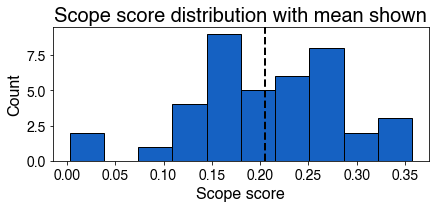

In [45]:
# get and plot the final scope scores for the inidividual seeds
nr_seeds = len(dfs_raw_data)
score_list = [dfs_raw_data[i].loc[8,"scope"] for i in range(nr_seeds)]
mean_score = np.mean(score_list)  # mean scope score

plt.figure(figsize=(6,3))
plt.title("Scope score distribution with mean shown")
plt.xlabel("Scope score")
plt.hist(score_list, color=all_colors[1], bins=10, edgecolor="k")
plt.axvline(x=mean_score, color='black', linestyle='--', linewidth=2)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [46]:
# check: How are the final scope scores when the initiations with the highest initial average rates are regarded?
summ_top_rates = pd.DataFrame(np.nan,index=["Top5 initial av. rate", "random initiation"],
                             columns=["Mean final scope score",
                                      "Worst final scope score",
                                      "Mean initial average rate"])

In [47]:
initial_vendi = [dfs_raw_data[i].loc[0,"vendi"] for i in range(nr_seeds)]
initial_obj = [dfs_raw_data[i].loc[0,"rate"] for i in range(nr_seeds)]

summ_top_rates.loc["random initiation","Mean initial average rate"] = round(np.mean(initial_obj),3)
summ_top_rates.loc["random initiation","Mean final scope score"] = round(np.mean(np.array(score_list)),3)
summ_top_rates.loc["random initiation","Worst final scope score"] = round(np.min(np.array(score_list)),3)


# get the seeds that have the top 5 initial average rates
indexed_rates = list(enumerate(initial_obj))  # generate (index,av. rate) tuples
top_5 = sorted(indexed_rates, key=lambda x: x[1], reverse=True)[:5]  # sort by score
best_seeds = [index for index, yield_val in top_5]
print(f"Top 5 seeds by initial average rate:", best_seeds)

# get the averages of the final samples for the top 5 seeds
best_init_final_scope = [dfs_raw_data[i].loc[8,"scope"] for i in best_seeds]
best_init_rate = [initial_obj[i] for i in best_seeds]

summ_top_rates.loc["Top5 initial av. rate","Mean final scope score"] = round(np.mean(best_init_final_scope),3)
summ_top_rates.loc["Top5 initial av. rate","Worst final scope score"] = round(np.min(best_init_final_scope),3)
summ_top_rates.loc["Top5 initial av. rate","Mean initial average rate"] = round(np.mean(best_init_rate),3)

summ_top_rates

Top 5 seeds by initial average rate: [37, 32, 6, 14, 33]


,Mean final scope score,Worst final scope score,Mean initial average rate
Top5 initial av. rate,0.151,0.003,2.216
random initiation,0.205,0.003,1.548


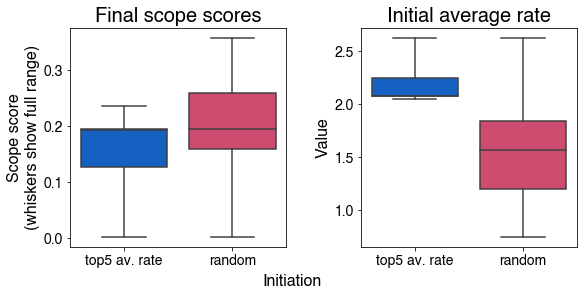

In [48]:
fig, axes = plt.subplots(1,2, figsize = (8,4),gridspec_kw={"wspace": 0.1},constrained_layout=True)
for i, results_type in enumerate(["scope","rate"]):
    ax = axes[i]
    if results_type == "scope":
        ax.set_title("Final scope scores")
    else:
        ax.set_title("Initial average rate")
    fig.supxlabel("Initiation",fontsize=16)
    if results_type == "scope":
        df = pd.DataFrame([best_init_final_scope,score_list])
    else:
        df = pd.DataFrame([best_init_rate,initial_obj])
    df_long = df.T.melt(var_name='Row', value_name='Value')
    df_long.loc[df_long["Row"] == 0,"Row"] = "top5 av. rate"
    df_long.loc[df_long["Row"] == 1,"Row"] = "random"
    palette = [all_colors[1], all_colors[0]]
    sns.boxplot(ax=ax,x='Row', y='Value', data=df_long, whis=[0,100], palette=palette, saturation=1)
    if results_type == "scope":
        ax.set_ylabel('Scope score\n(whiskers show full range)')
    elif results_type == "yield":
        ax.set_ylabel("Average rate (%)\n(whiskers show full range)")
    ax.set_xlabel("")
plt.show()

### Visualization of scope examples

Show the scopes for the random seed that provides a scope performance closest to the average of all random seeds (for ScopeBO scopes). Scopes for other methods are shown with the same random seed.

In [49]:
def find_av_random_seed(name_results, bounds, batch_pruning, budget=27):
    """Finds the random seed that give the scope with a scope score closet to the average performance."""

    _, dict_dfs_raw_data = Benchmark.get_metric_overview(bounds=bounds,budget=budget,type_results="scope", 
                                name_results=name_results)

    # dict_dfs_raw_data contains the a dict for each batch-pruning 
    # combination which in turn contains a dict of the raw data for the differnt random seeds
    # --> restrict to the relevant data (batch size 2 and no Vendi pruning)
    dfs_raw_data = dict_dfs_raw_data[batch_pruning]

    # collect the scope scores
    # NOTE: the indices are the (zero-indexed) rounds --> round 8 is the full scope of 27 samples
    score_dict = {seed: df.loc[8,"scope"] for seed,df in dfs_raw_data.items()}
    av_score = np.mean(np.array(list(score_dict.values())))

    # calculate the absolute difference to the average score
    score_diff = {seed: abs(score-av_score) for seed,score in score_dict.items()}

    # get the seed that is closest to the average
    av_seed = min(score_diff,key=score_diff.get)

    return av_seed


def get_umap(name_results, objective, hyperpar="balanced_b3_V13", bounds = bounds, seed = None,figsize=(2.7,2.7), show_colorbar=False):

    if seed is None:
        seed = find_av_random_seed(name_results= name_results, bounds=bounds, batch_pruning= "_".join(hyperpar.split("_")[1:]))
    print("Depicted seed:",seed)
    data_labelled = pd.read_csv(f"./SB_dset.csv",index_col=0)
    obj_max = data_labelled[objective].max()
    obj_min = data_labelled[objective].min()
    Benchmark().track_samples(filename_umap=f"./SB_UMAP_coords.csv",
                            filename_data=f"27{hyperpar}_s{seed}.csv",
                            bounds=bounds,
                            hide_axis = True, obj_plot_bounds=(obj_max,obj_min),
                            filename_labelled=f"./SB_dset.csv",
                            name_results= name_results+ "/raw_data", show_colorbar= show_colorbar,
                            label_round=False, display_cut_samples=False, figsize = figsize, size_scaling = 0.3, dpi=600, obj_to_display=objective)
    
    return seed

UMAPs for ScopeBO:

UMAP for the objective rate
Depicted seed: 14
Scope score: 0.194
Average rate: 2.047
Vendi score: 7.943


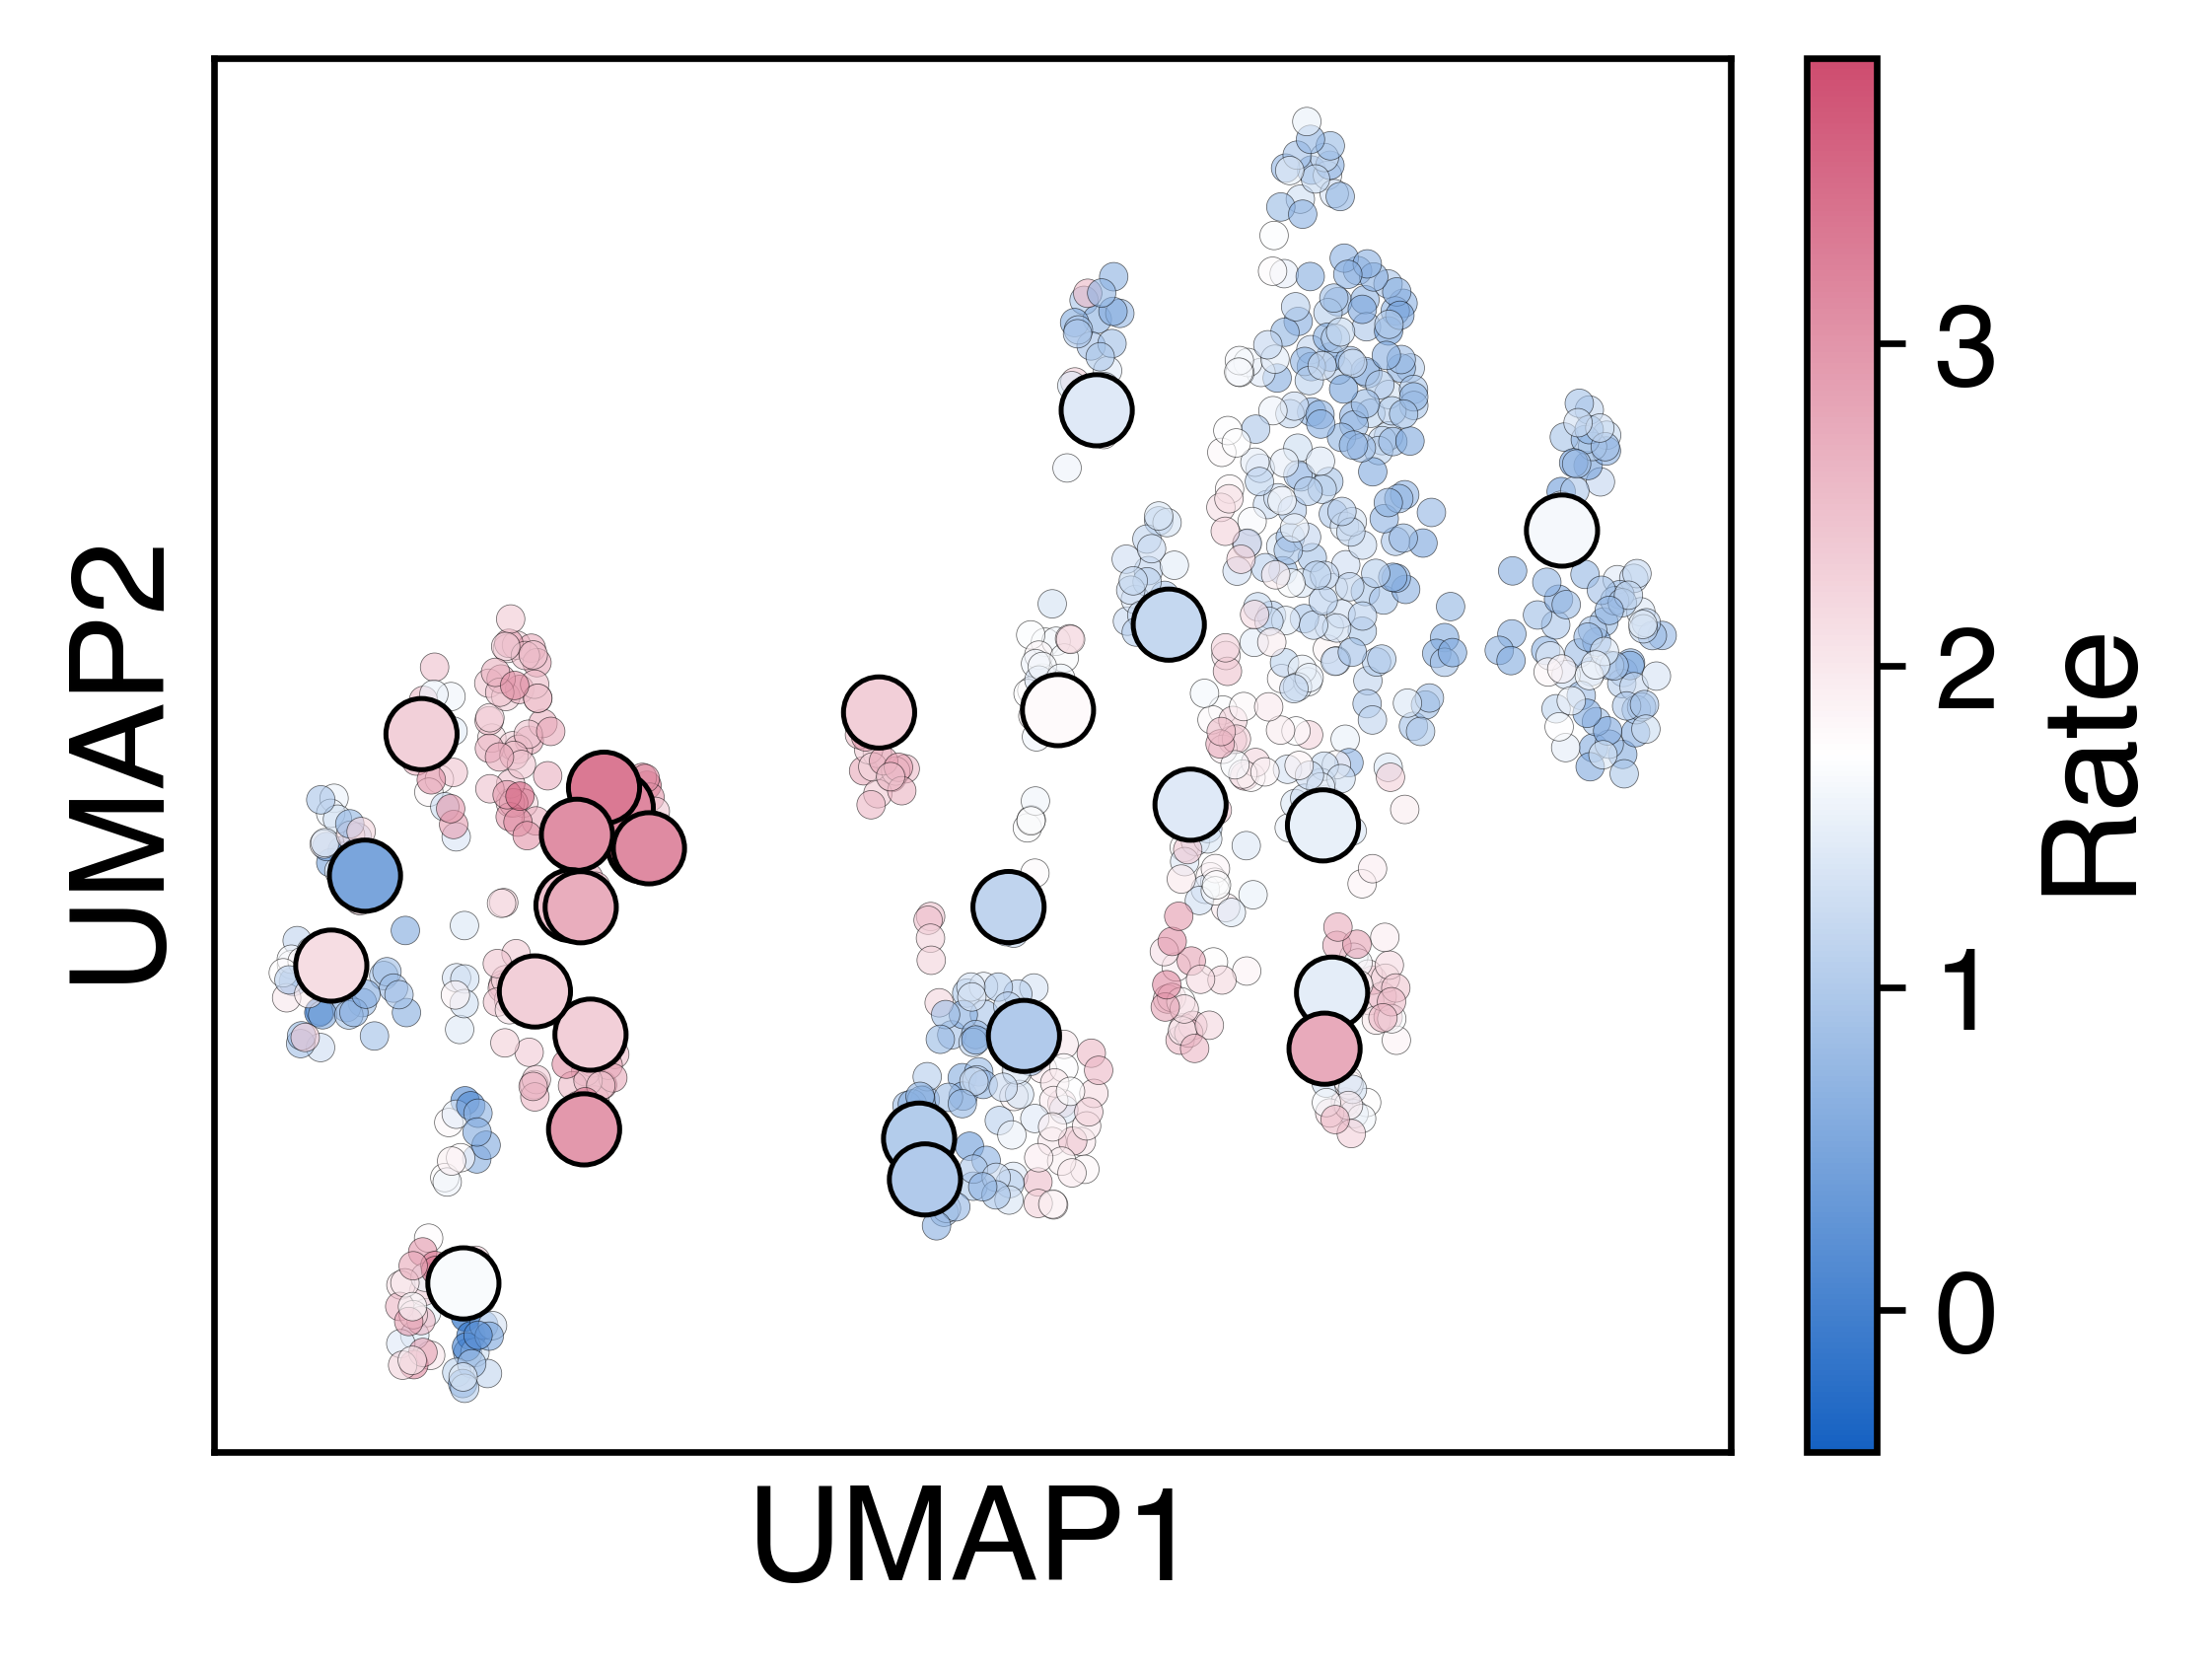

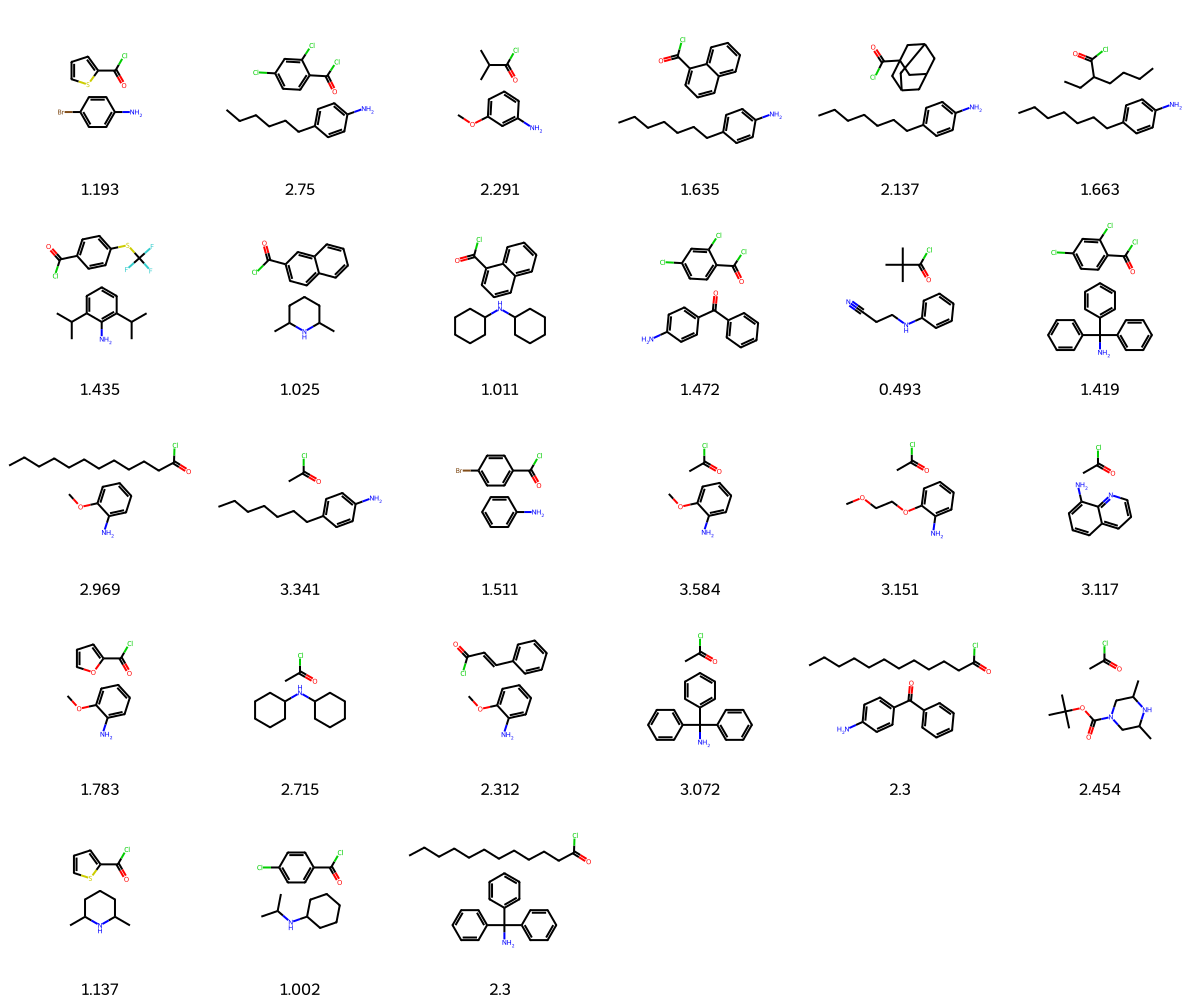

UMAPs for Regular BO (EI):

UMAP for the objective rate
Depicted seed: 14
Scope score: 0.314
Average rate: 2.391
Vendi score: 6.916


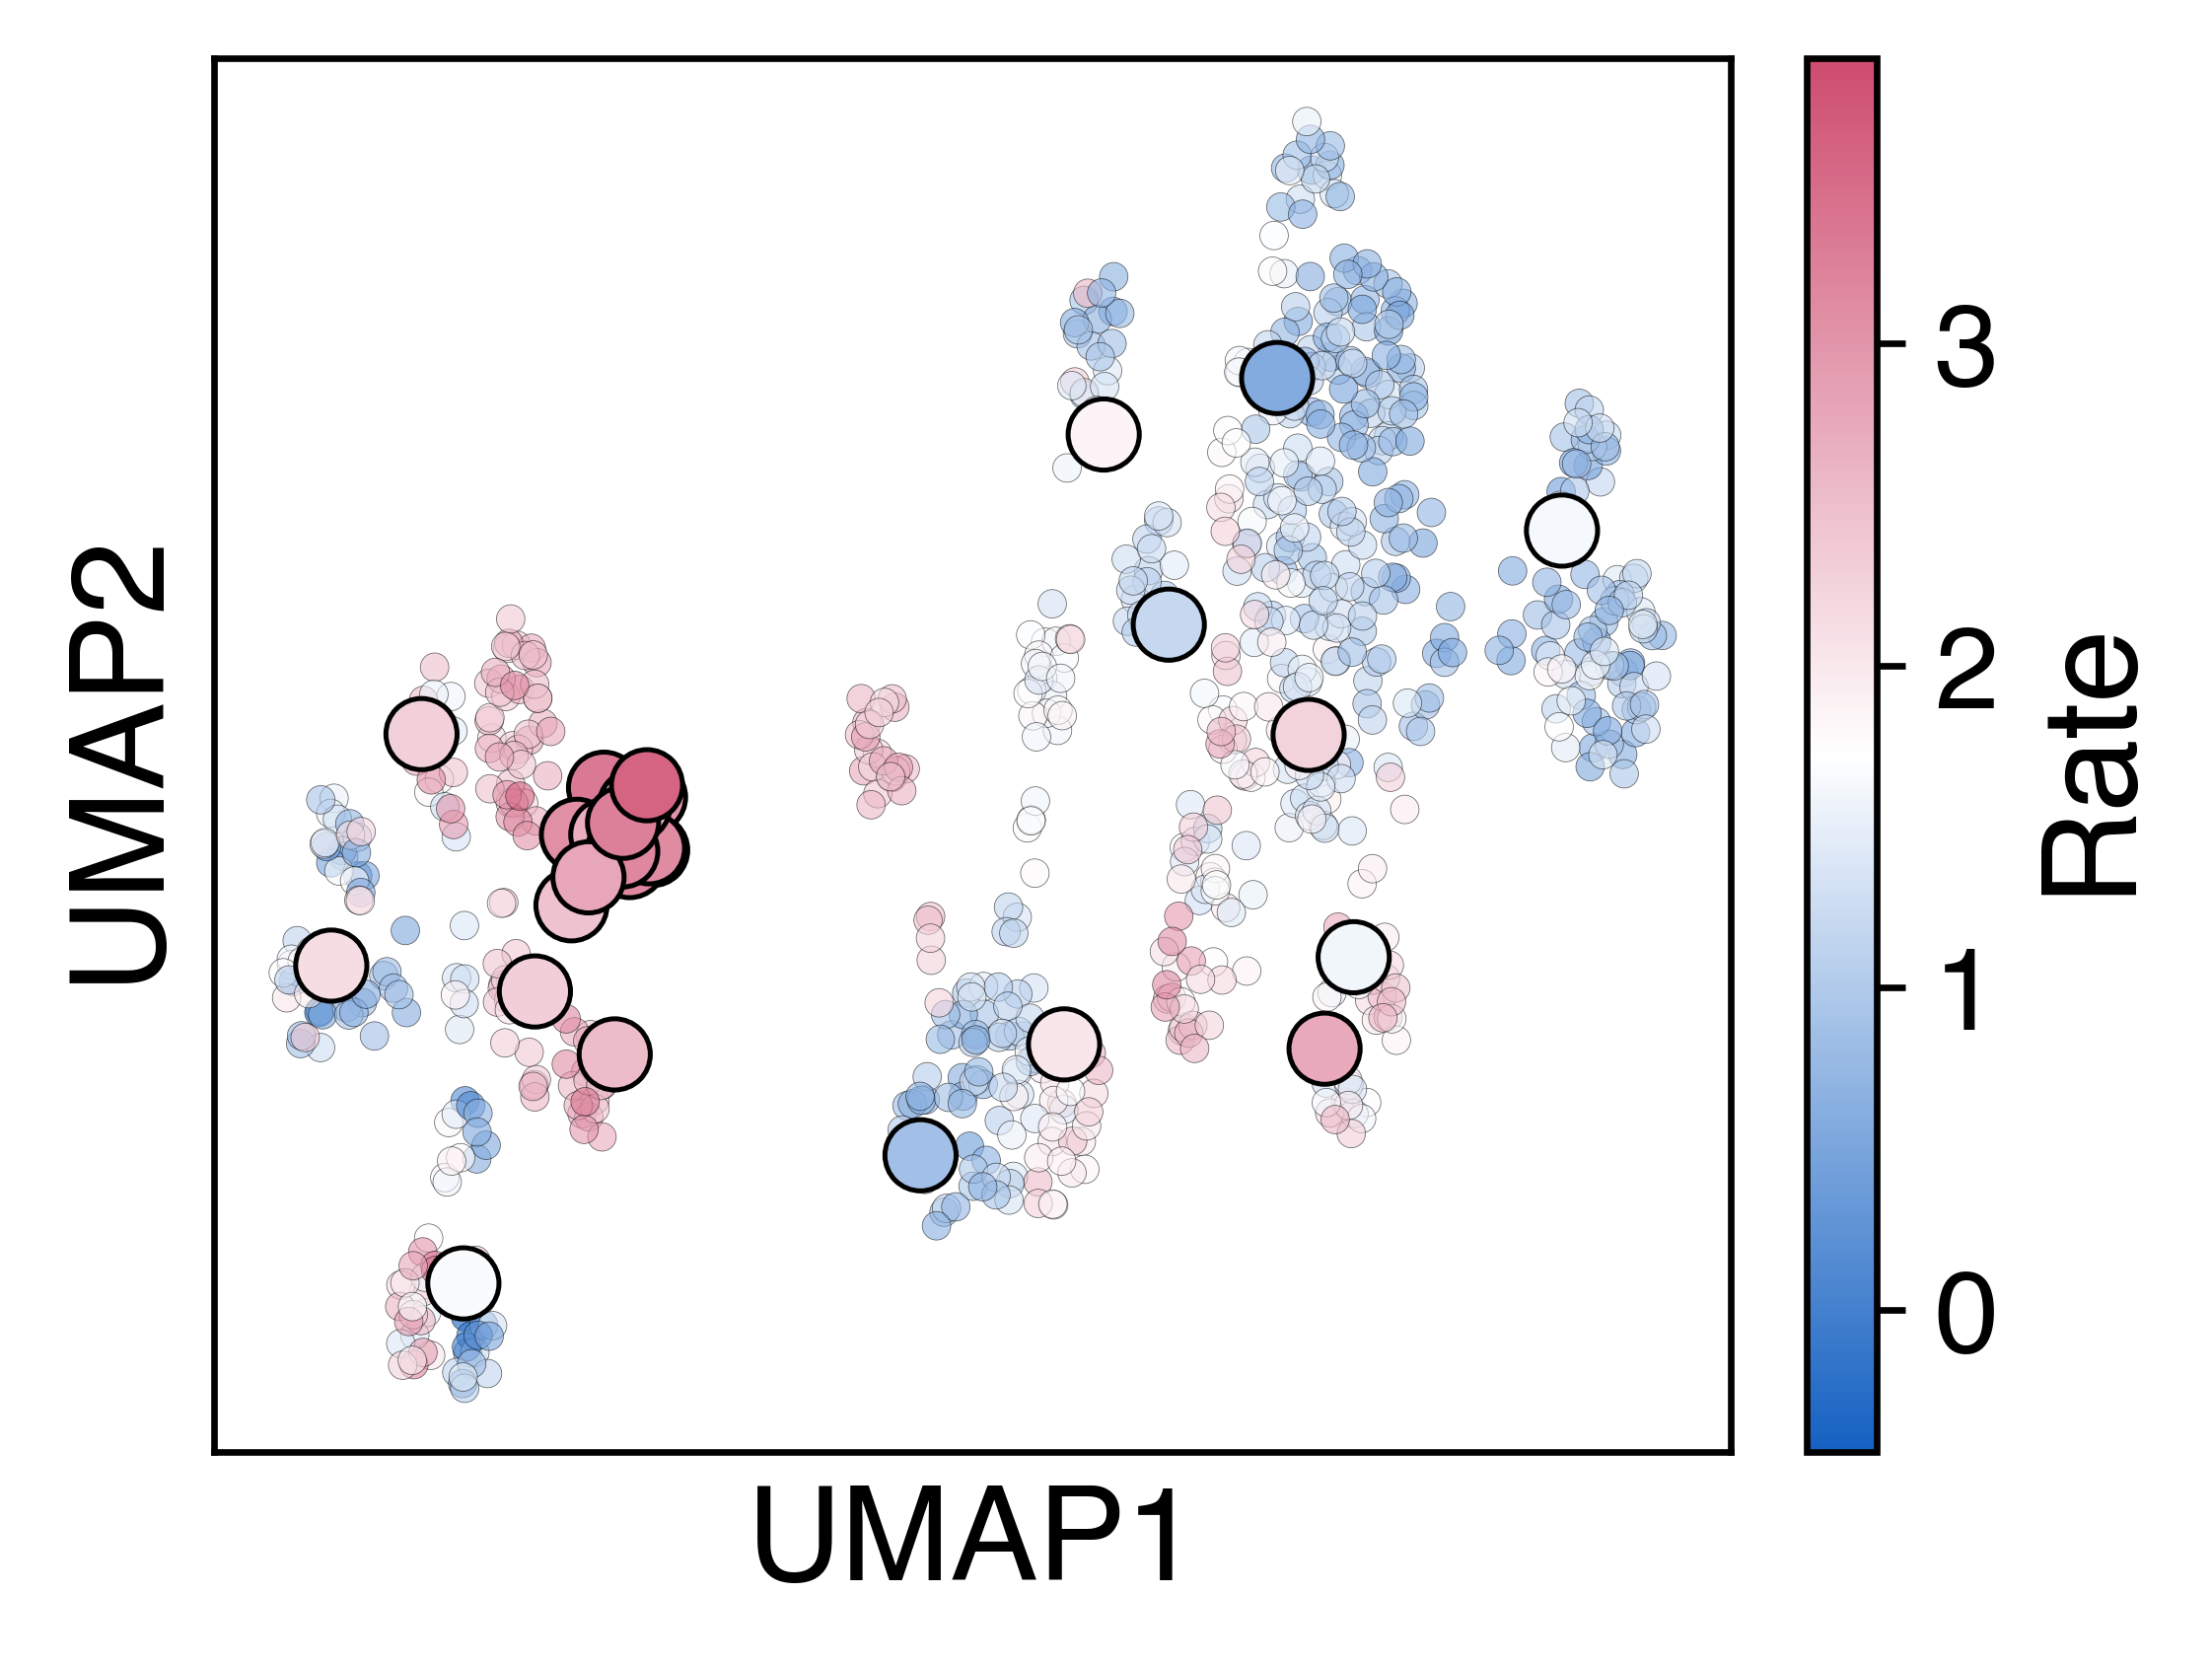

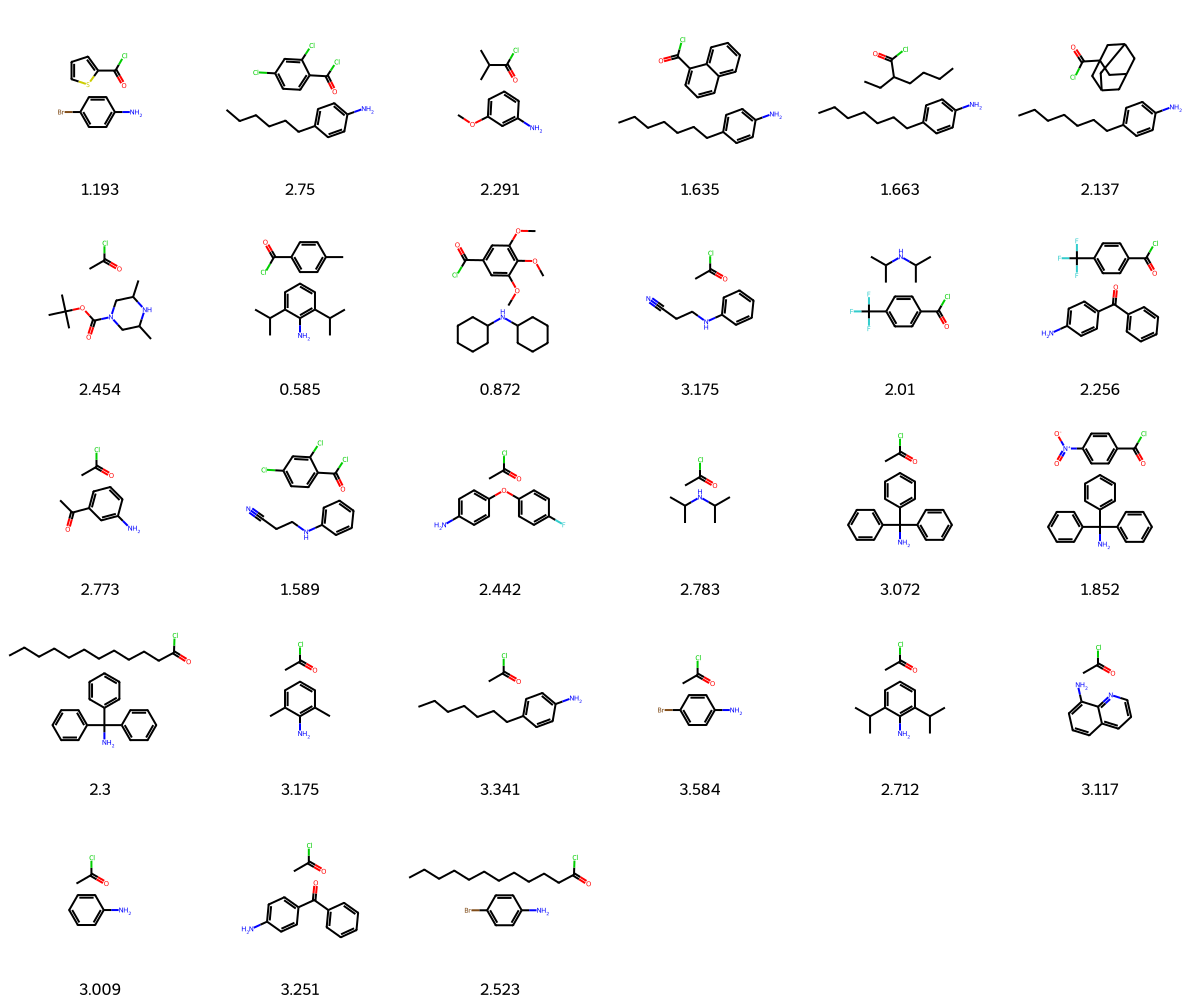

UMAPs for conventional selection:

UMAP for the objective rate
Depicted seed: 14
Scope score: 0.197
Average rate: 2.432
Vendi score: 5.398


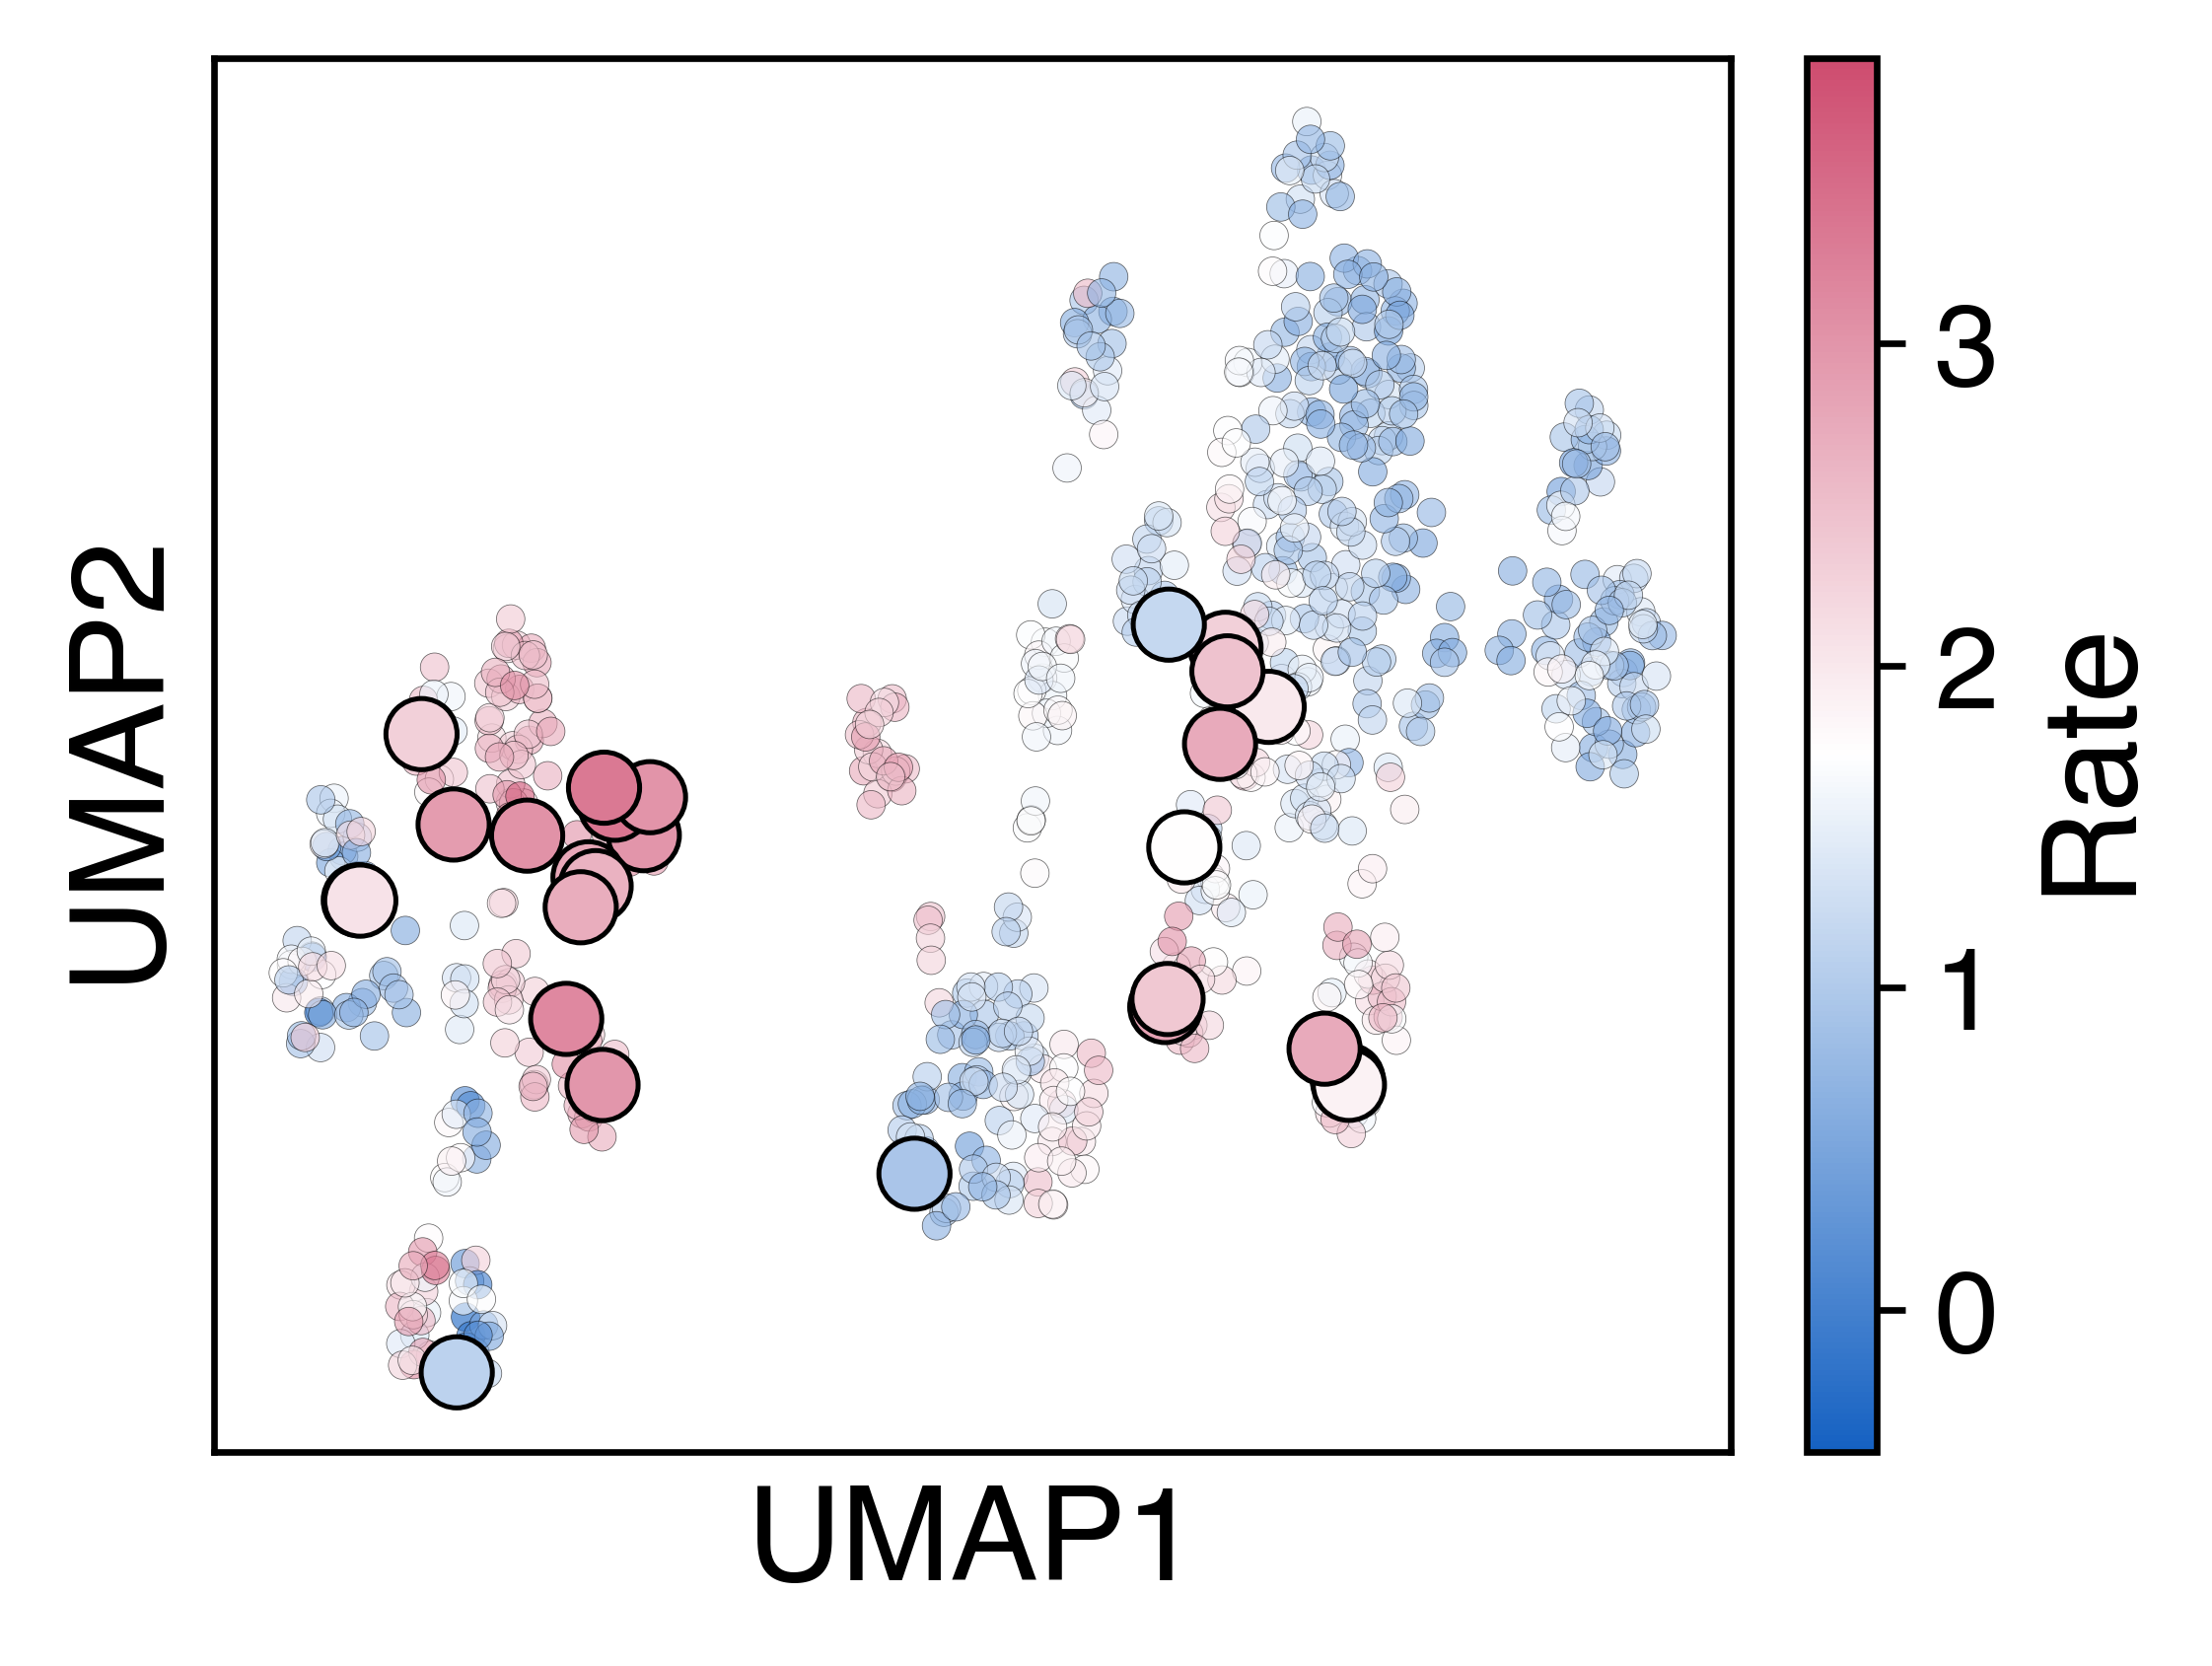

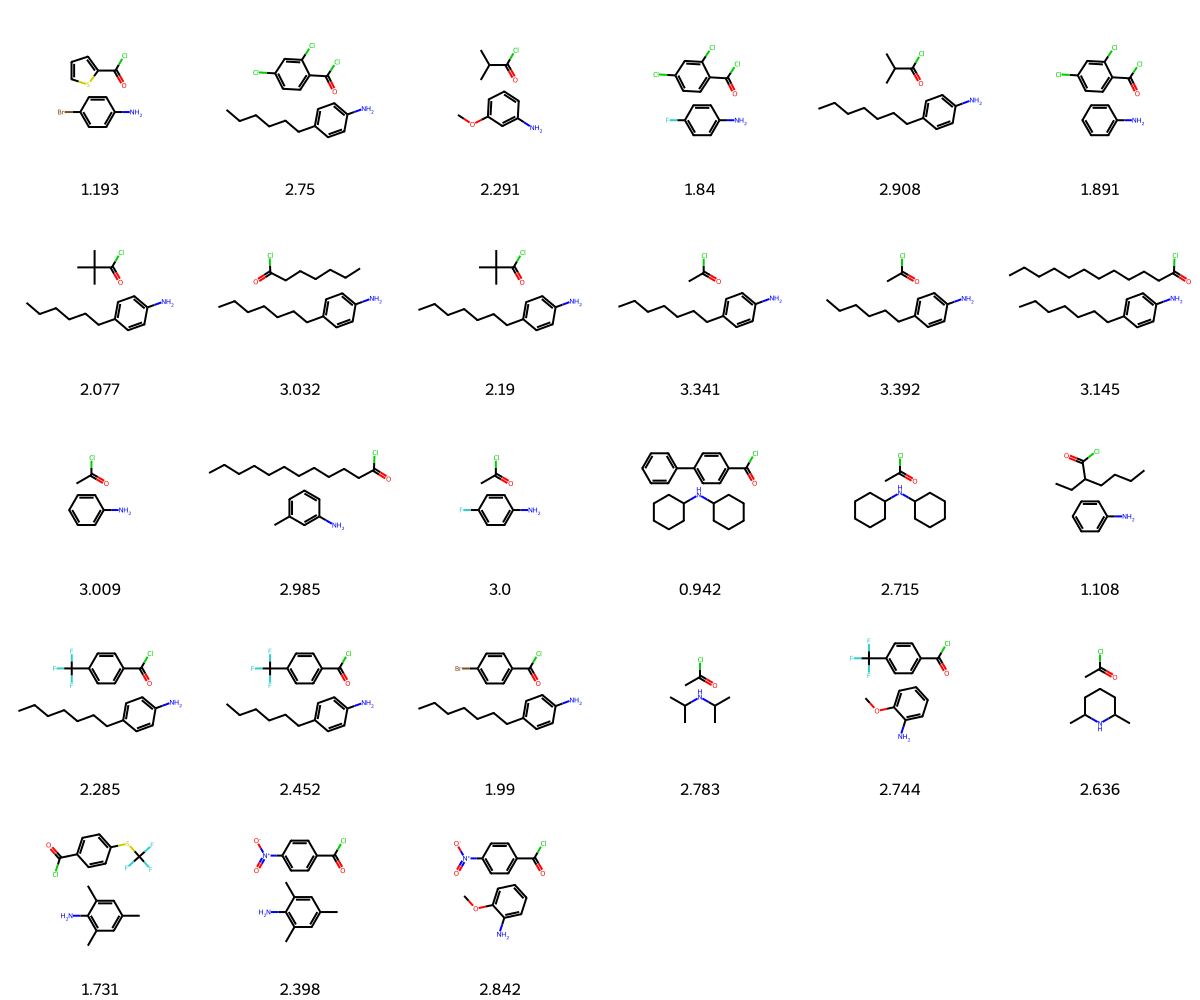

In [50]:
print(f"UMAPs for ScopeBO:\n")
seed = None
for obj in objectives:
    print(f"UMAP for the objective {obj}")
    seed = get_umap(name_results=f"./Results_Data/scope_balanced_pruning", bounds=bounds, figsize = (3.63, 2.7), objective = obj, show_colorbar=True)
Benchmark().show_scope(filename_data=f"27balanced_b3_V13_s{seed}.csv", name_results=f"./Results_Data/scope_balanced_pruning/raw_data", by_round=False,
                    round_values=3)
print(f"UMAPs for Regular BO (EI):\n")
for obj in objectives:
    print(f"UMAP for the objective {obj}")
    get_umap(name_results=f"./Results_Data/scope_balanced_no-pruning", bounds = bounds, hyperpar="balanced_b3_V0", 
             seed=seed, figsize = (3.63, 2.7), objective = obj, show_colorbar=True)
Benchmark().show_scope(filename_data=f"27balanced_b3_V0_s{seed}.csv", name_results=f"./Results_Data/scope_balanced_no-pruning/raw_data", by_round=False,
                    round_values=3)
print(f"UMAPs for conventional selection:\n")
for obj in objectives:
    print(f"UMAP for the objective {obj}")
    get_umap(name_results=f"./Results_Data/scope_human-like-acq", hyperpar="greedy_b3_V5", seed = seed, bounds = bounds, figsize = (3.63, 2.7), show_colorbar=True, objective = obj)
Benchmark().show_scope(filename_data=f"27greedy_b3_V5_s{seed}.csv", name_results=f"./Results_Data/scope_human-like-acq/raw_data", by_round=False,
                    round_values=3)

### Reaction space analysis

Plot order of hte acid chlorides:


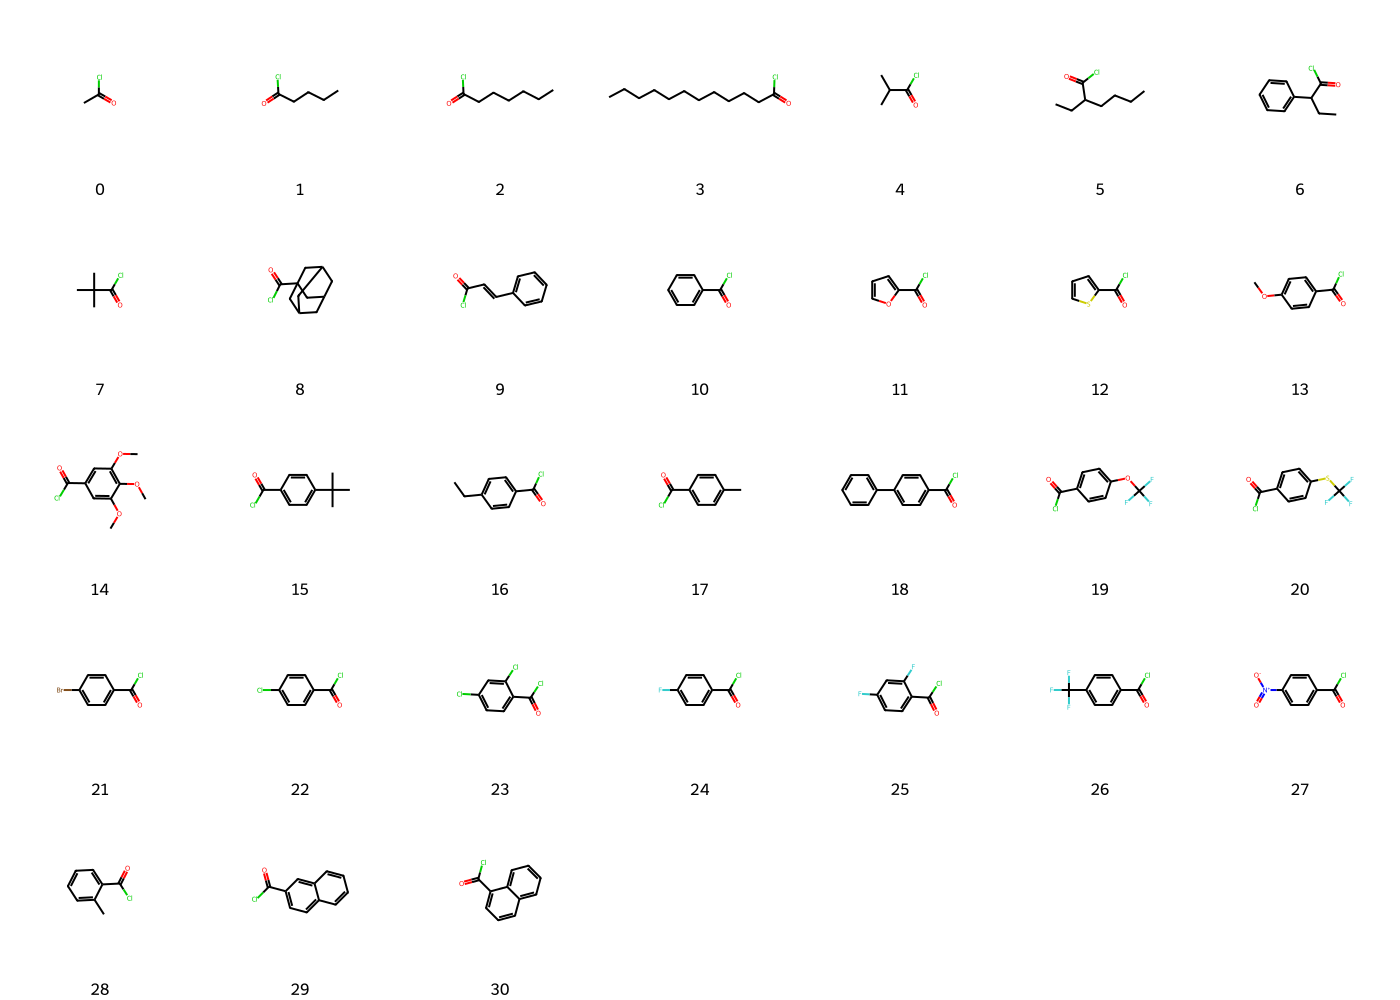

In [62]:
# order the acid chlorides for the plot
cocl_dict = {
    "CC(=O)Cl": 0,
    "CCCCC(=O)Cl": 1,
    "CCCCCCC(=O)Cl": 2,
    "CCCCCCCCCCCC(=O)Cl": 3,
    "CC(C)C(=O)Cl": 4,
    "CCCCC(CC)C(=O)Cl": 5,
    "CCC(C(=O)Cl)c1ccccc1": 6,
    "CC(C)(C)C(=O)Cl": 7,
    "O=C(Cl)C12CC3CC(CC(C3)C1)C2": 8,
    "O=C(Cl)C=Cc1ccccc1": 9,
    "O=C(Cl)c1ccccc1": 10,
    "O=C(Cl)c1ccco1": 11,
    "O=C(Cl)c1cccs1": 12,
    "COc1ccc(C(=O)Cl)cc1": 13,
    "COc1cc(C(=O)Cl)cc(OC)c1OC": 14,
    "CC(C)(C)c1ccc(C(=O)Cl)cc1": 15,
    "CCc1ccc(C(=O)Cl)cc1": 16,
    "Cc1ccc(C(=O)Cl)cc1": 17,
    "O=C(Cl)c1ccc(-c2ccccc2)cc1": 18,
    "O=C(Cl)c1ccc(OC(F)(F)F)cc1": 19,
    "O=C(Cl)c1ccc(SC(F)(F)F)cc1": 20,
    "O=C(Cl)c1ccc(Br)cc1": 21,
    "O=C(Cl)c1ccc(Cl)cc1": 22,
    "O=C(Cl)c1ccc(Cl)cc1Cl": 23,
    "O=C(Cl)c1ccc(F)cc1": 24,
    "O=C(Cl)c1ccc(F)cc1F": 25,
    "O=C(Cl)c1ccc(C(F)(F)F)cc1": 26,
    "O=C(Cl)c1ccc([N+](=O)[O-])cc1": 27,
    "Cc1ccccc1C(=O)Cl": 28,
    "O=C(Cl)c1ccc2ccccc2c1": 29,
    "O=C(Cl)c1cccc2ccccc12": 30
}
print("Plot order of hte acid chlorides:")
Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in cocl_dict.keys()],molsPerRow=7,
                     legends = [str(x) for x in cocl_dict.values()])

Plot order of amines:


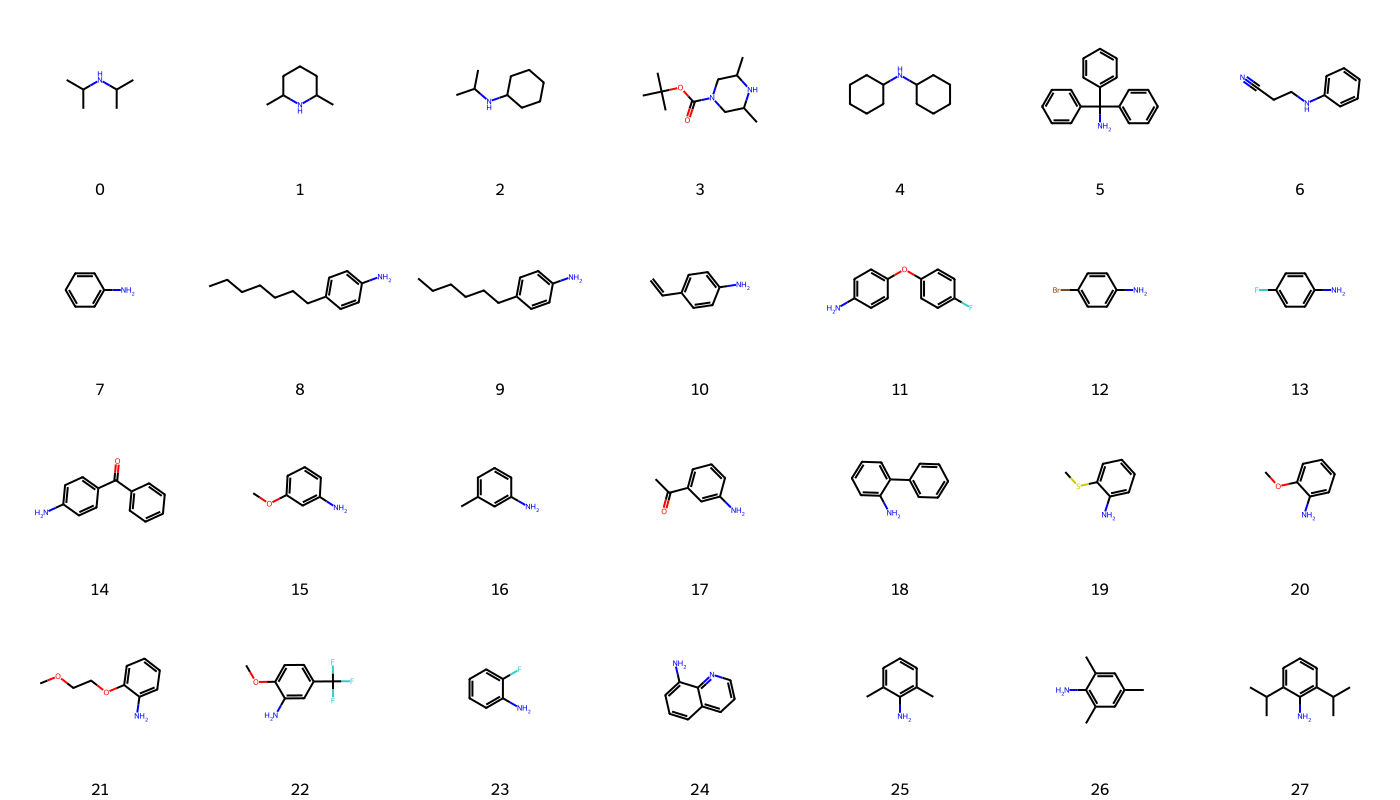

In [63]:
# order the amines for the plot
amine_dict = {
    "CC(C)NC(C)C": 0,
    "CC1CCCC(C)N1": 1,
    "CC(C)NC1CCCCC1": 2,
    "CC1CN(C(=O)OC(C)(C)C)CC(C)N1": 3,
    "C1CCC(NC2CCCCC2)CC1": 4,
    "NC(c1ccccc1)(c1ccccc1)c1ccccc1": 5,
    "N#CCCNc1ccccc1": 6,
    "Nc1ccccc1": 7,
    "CCCCCCCc1ccc(N)cc1": 8,
    "CCCCCCc1ccc(N)cc1": 9,
    "C=Cc1ccc(N)cc1": 10,
    "Nc1ccc(Oc2ccc(F)cc2)cc1": 11,
    "Nc1ccc(Br)cc1": 12,
    "Nc1ccc(F)cc1": 13,
    "Nc1ccc(C(=O)c2ccccc2)cc1": 14,
    "COc1cccc(N)c1": 15,
    "Cc1cccc(N)c1": 16,
    "CC(=O)c1cccc(N)c1": 17,
    "Nc1ccccc1-c1ccccc1": 18,
    "CSc1ccccc1N": 19,
    "COc1ccccc1N": 20,
    "COCCOc1ccccc1N": 21,
    "COc1ccc(C(F)(F)F)cc1N": 22,
    "Nc1ccccc1F": 23,
    "Nc1cccc2cccnc12": 24,
    "Cc1cccc(C)c1N": 25,
    "Cc1cc(C)c(N)c(C)c1": 26,
    "CC(C)c1cccc(C(C)C)c1N": 27
}
print("Plot order of amines:")
Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in amine_dict.keys()],molsPerRow=7, legends = [str(x) for x in amine_dict.values()])

In [64]:
# define the function
def get_selection_summary(name_results,directory="."):
    """
    Get the substrate selections for the 40 different random seeds.
    Returns a dataframe in the shape (substrates,seeds) with Boolean values 
    whether the substrates was selected for the given seed.
    """

    # Set directory.
    wdir = Path(directory)
    raw_path = wdir.joinpath(name_results+"/raw_data/")

    # dataframe for the reaction space
    df_space = df_labelled.copy()
    # assign the ordering
    df_space["Dist_amine"] = np.nan
    df_space["Dist_COCl"] = np.nan
    for idx in df_space.index:
        [amine_idx, cocl_idx] = idx.split(".")
        df_space.loc[idx,"Dist_amine"] = amine_dict[amine_idx]
        df_space.loc[idx,"Dist_COCl"] = cocl_dict[cocl_idx]
        df_space.loc[idx,"amine"] = amine_idx
        df_space.loc[idx,"cocl"] = cocl_idx
    df_space = df_space.loc[:,["rate","Dist_amine","Dist_COCl","amine","cocl"]]
    df_space.head()

    # set up a results dataframe for the counts
    df_counts = pd.DataFrame(False, index = df_space.index, columns = list(range(40)))

    for file in os.listdir(raw_path):
        df_data = pd.read_csv(wdir.joinpath(name_results+"/raw_data/"+file), index_col=0,header=0)
        # process the data (list was saved as str)
        df_data["eval_samples"] = df_data["eval_samples"].apply(lambda x: [y.strip("'") for y in x[1:-1].split(', ')])

        # get the seed
        seed = int(file.split("_")[-1].split(".")[0][1:])

        # assign the counts
        for idx in df_data.index:
            for smiles in df_data.loc[idx,"eval_samples"]:
                df_counts.loc[smiles,seed] = True

    return df_counts, df_space

In [65]:
abs_sel_mean = pd.DataFrame(np.nan, index = ["Amines","Acid chlorides"],columns=["ScopeBO","Regular BO (EI)","Conv. selection","Random sel."])
abs_sel_std = pd.DataFrame(np.nan, index = ["Amines","Acid chlorides"],columns=["ScopeBO","Regular BO (EI)","Conv. selection","Random sel."])


Results for ScopeBO


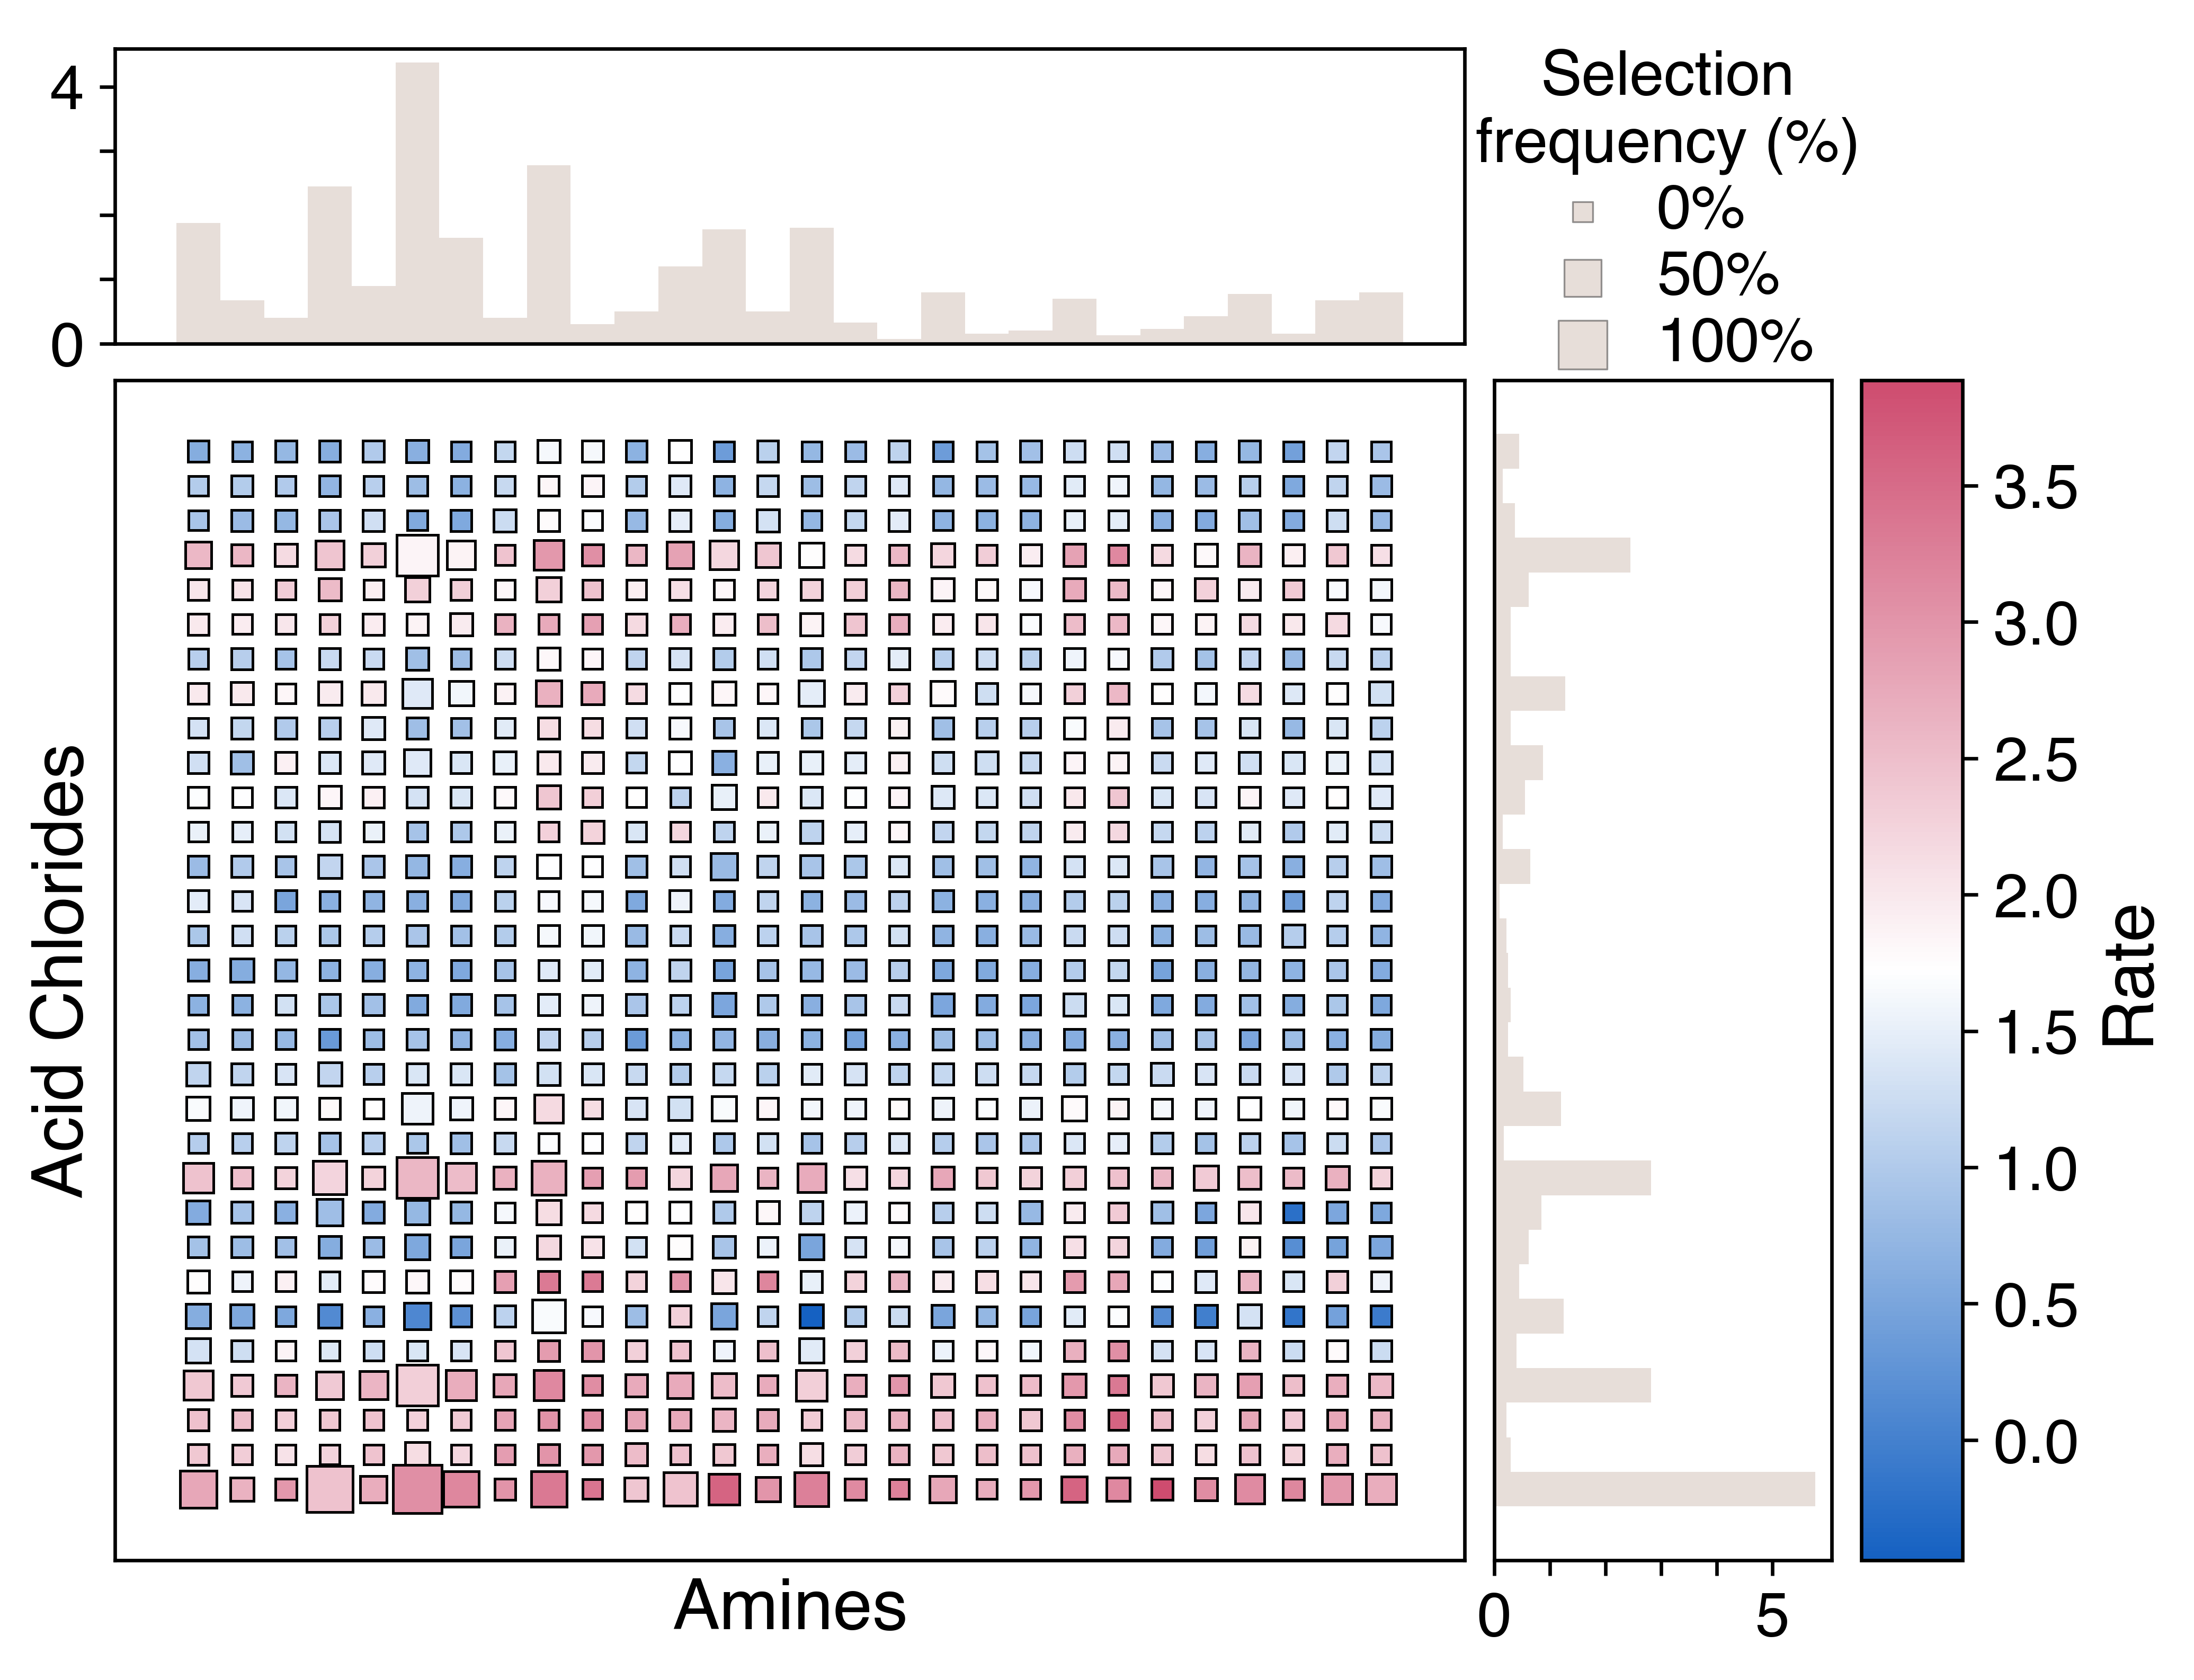

Average number of reactions selected for each acid chloride


,Selections,Av.rate in rxns
cocl,,
CC(=O)Cl,5.775,3.026743
CC(C)(C)C(=O)Cl,0.625,1.101941
CC(C)(C)c1ccc(C(=O)Cl)cc1,0.250,0.787245
CC(C)C(=O)Cl,0.400,1.914250
CCC(C(=O)Cl)c1ccccc1,0.450,2.184221
CCCCC(=O)Cl,0.300,2.466888
CCCCC(CC)C(=O)Cl,1.250,0.723831
CCCCCCC(=O)Cl,0.225,2.636501
CCCCCCCCCCCC(=O)Cl,2.825,2.660619


Average number of reactions selected for each amine


,Selections,Av.rate in rxns
amine,,
C1CCC(NC2CCCCC2)CC1,0.900,1.464322
C=Cc1ccc(N)cc1,0.500,1.539258
CC(=O)c1cccc(N)c1,0.800,1.355420
CC(C)NC(C)C,1.875,1.446727
CC(C)NC1CCCCC1,0.400,1.443687
CC(C)c1cccc(C(C)C)c1N,0.800,1.271178
CC1CCCC(C)N1,0.675,1.429618
CC1CN(C(=O)OC(C)(C)C)CC(C)N1,2.450,1.390352
CCCCCCCc1ccc(N)cc1,2.775,2.197285


Different amines selected per scope: 14.02  ±  1.67
Different acid chlorides selected per scope: 14.6  ±  1.88

Results for regular BO


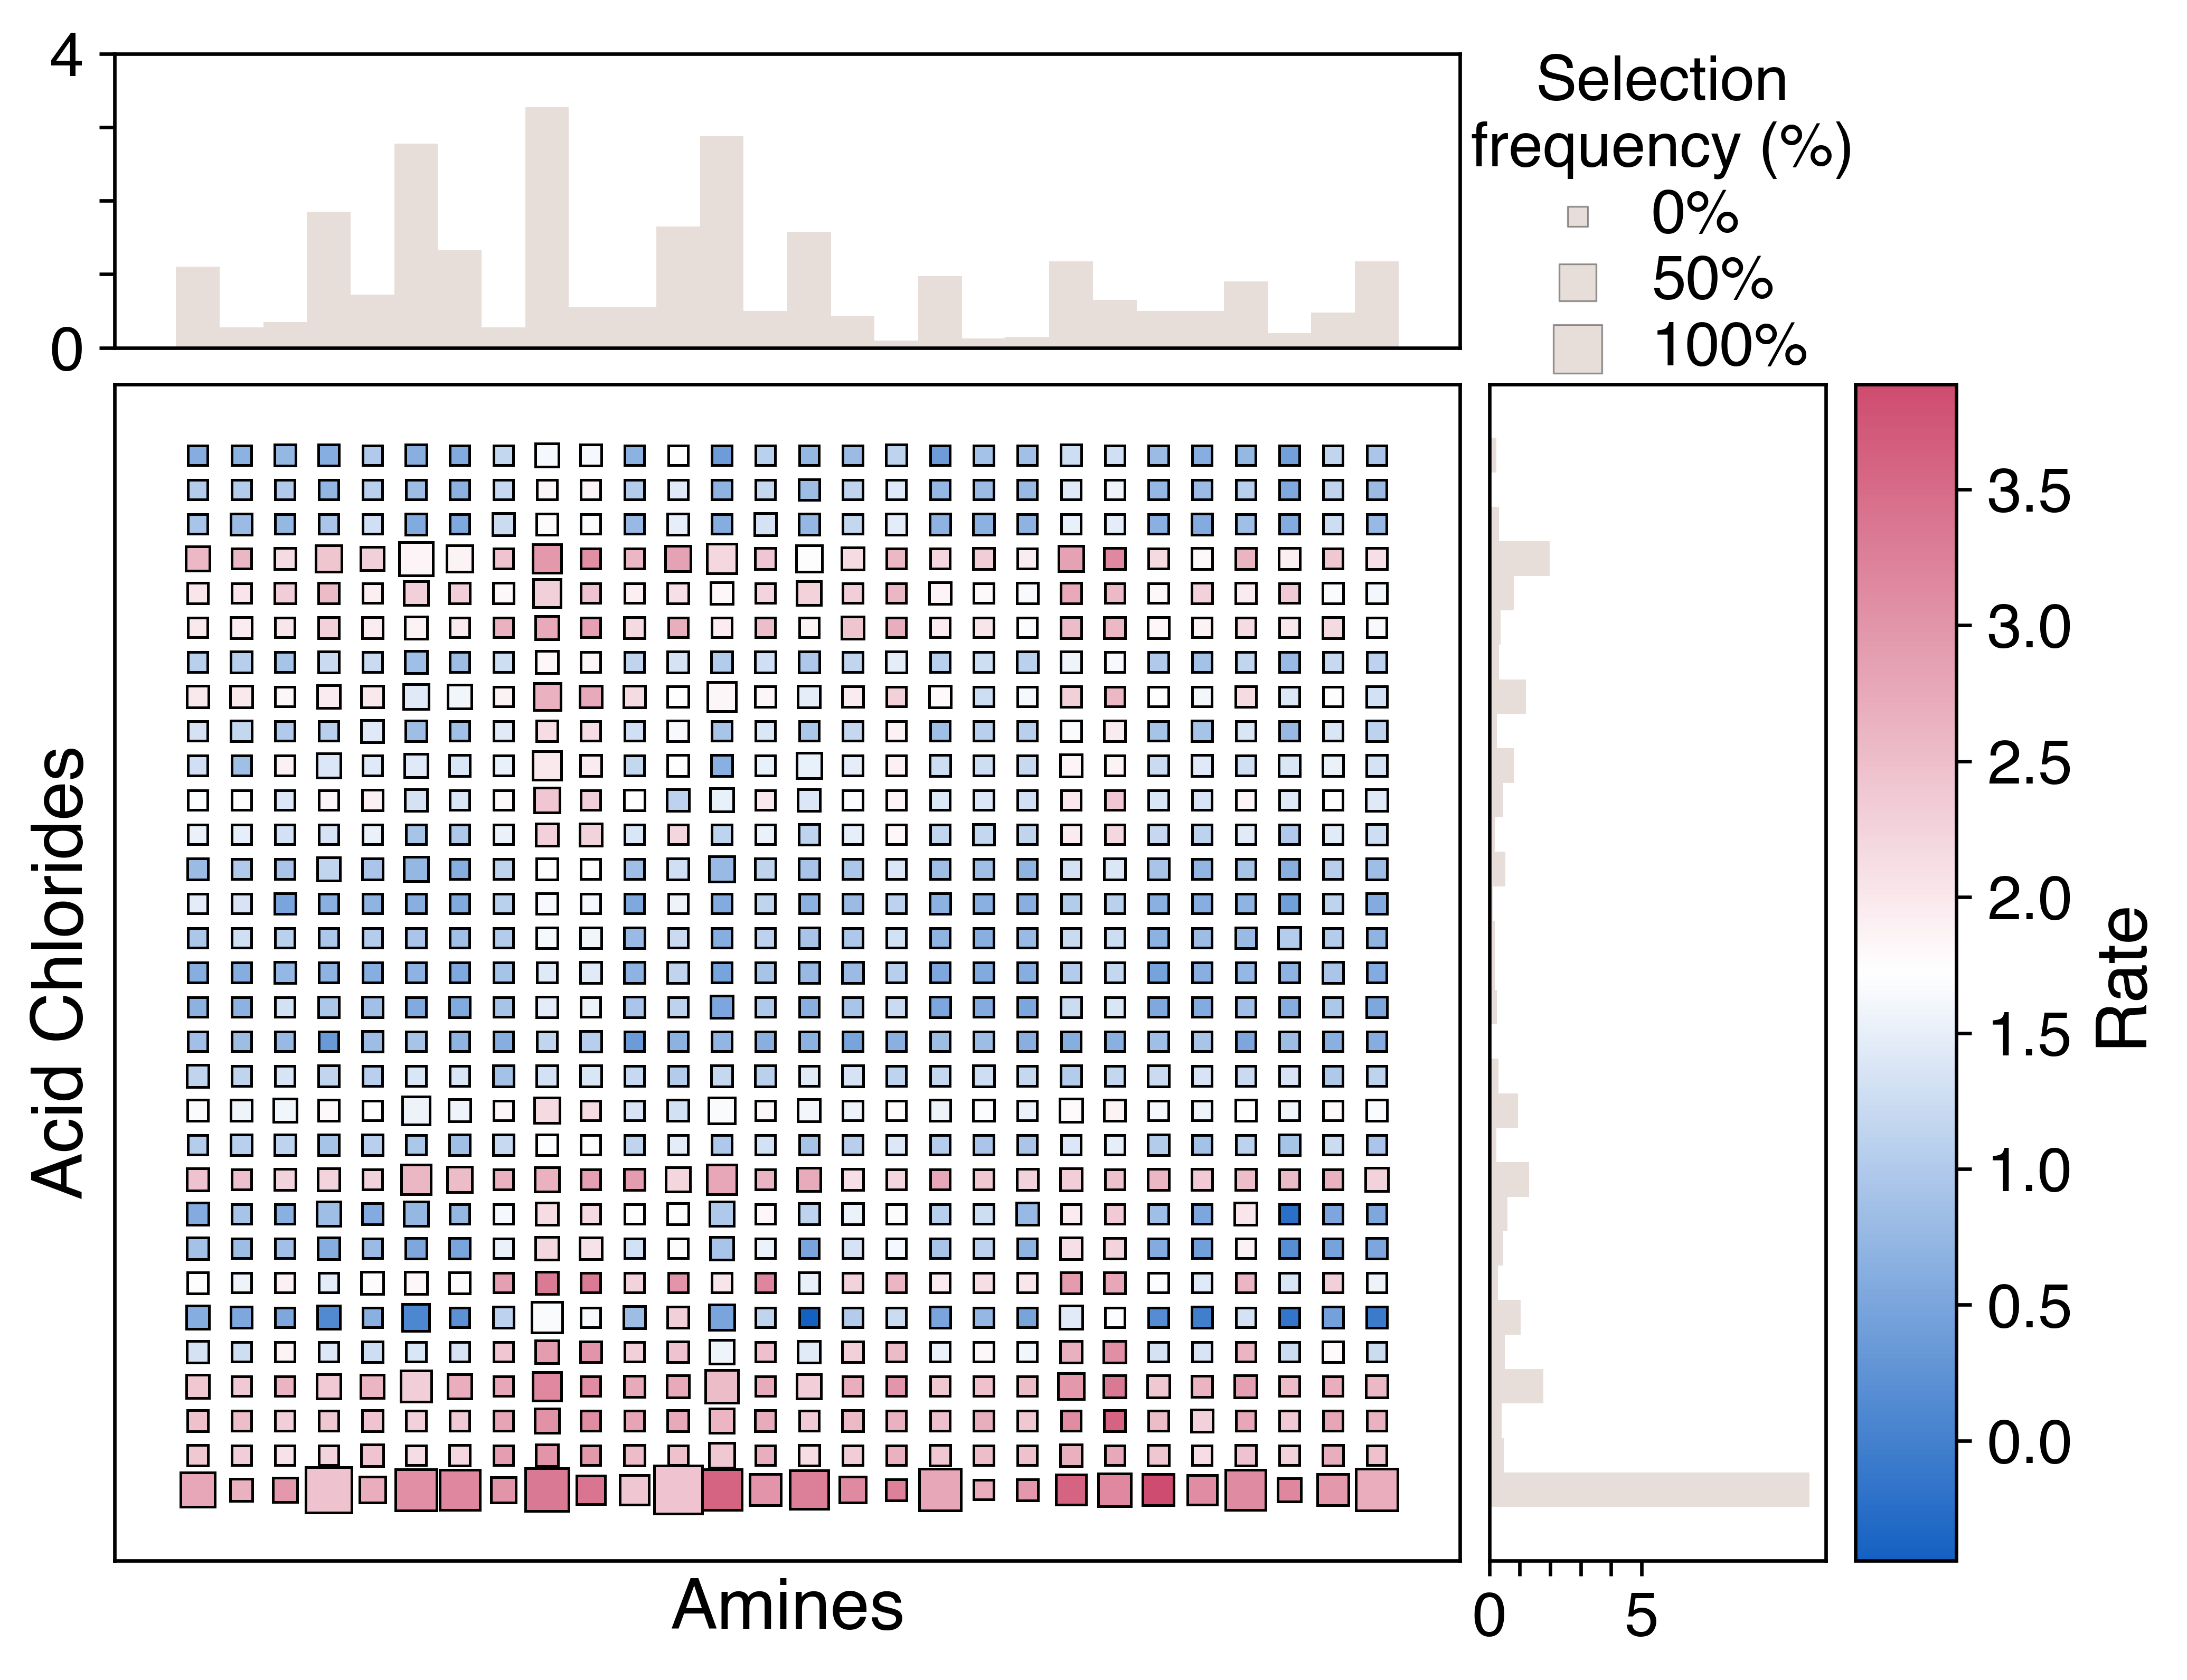

Average number of reactions selected for each acid chloride


,Selections,Av.rate in rxns
cocl,,
CC(=O)Cl,10.525,3.026743
CC(C)(C)C(=O)Cl,0.450,1.101941
CC(C)(C)c1ccc(C(=O)Cl)cc1,0.175,0.787245
CC(C)C(=O)Cl,0.500,1.914250
CCC(C(=O)Cl)c1ccccc1,0.275,2.184221
CCCCC(=O)Cl,0.475,2.466888
CCCCC(CC)C(=O)Cl,1.025,0.723831
CCCCCCC(=O)Cl,0.400,2.636501
CCCCCCCCCCCC(=O)Cl,1.775,2.660619


Average number of reactions selected for each amine


,Selections,Av.rate in rxns
amine,,
C1CCC(NC2CCCCC2)CC1,0.725,1.464322
C=Cc1ccc(N)cc1,0.550,1.539258
CC(=O)c1cccc(N)c1,0.975,1.355420
CC(C)NC(C)C,1.100,1.446727
CC(C)NC1CCCCC1,0.350,1.443687
CC(C)c1cccc(C(C)C)c1N,1.175,1.271178
CC1CCCC(C)N1,0.275,1.429618
CC1CN(C(=O)OC(C)(C)C)CC(C)N1,1.850,1.390352
CCCCCCCc1ccc(N)cc1,3.275,2.197285


Different amines selected per scope: 14.8  ±  1.74
Different acid chlorides selected per scope: 12.52  ±  1.52

Results for conv. selection


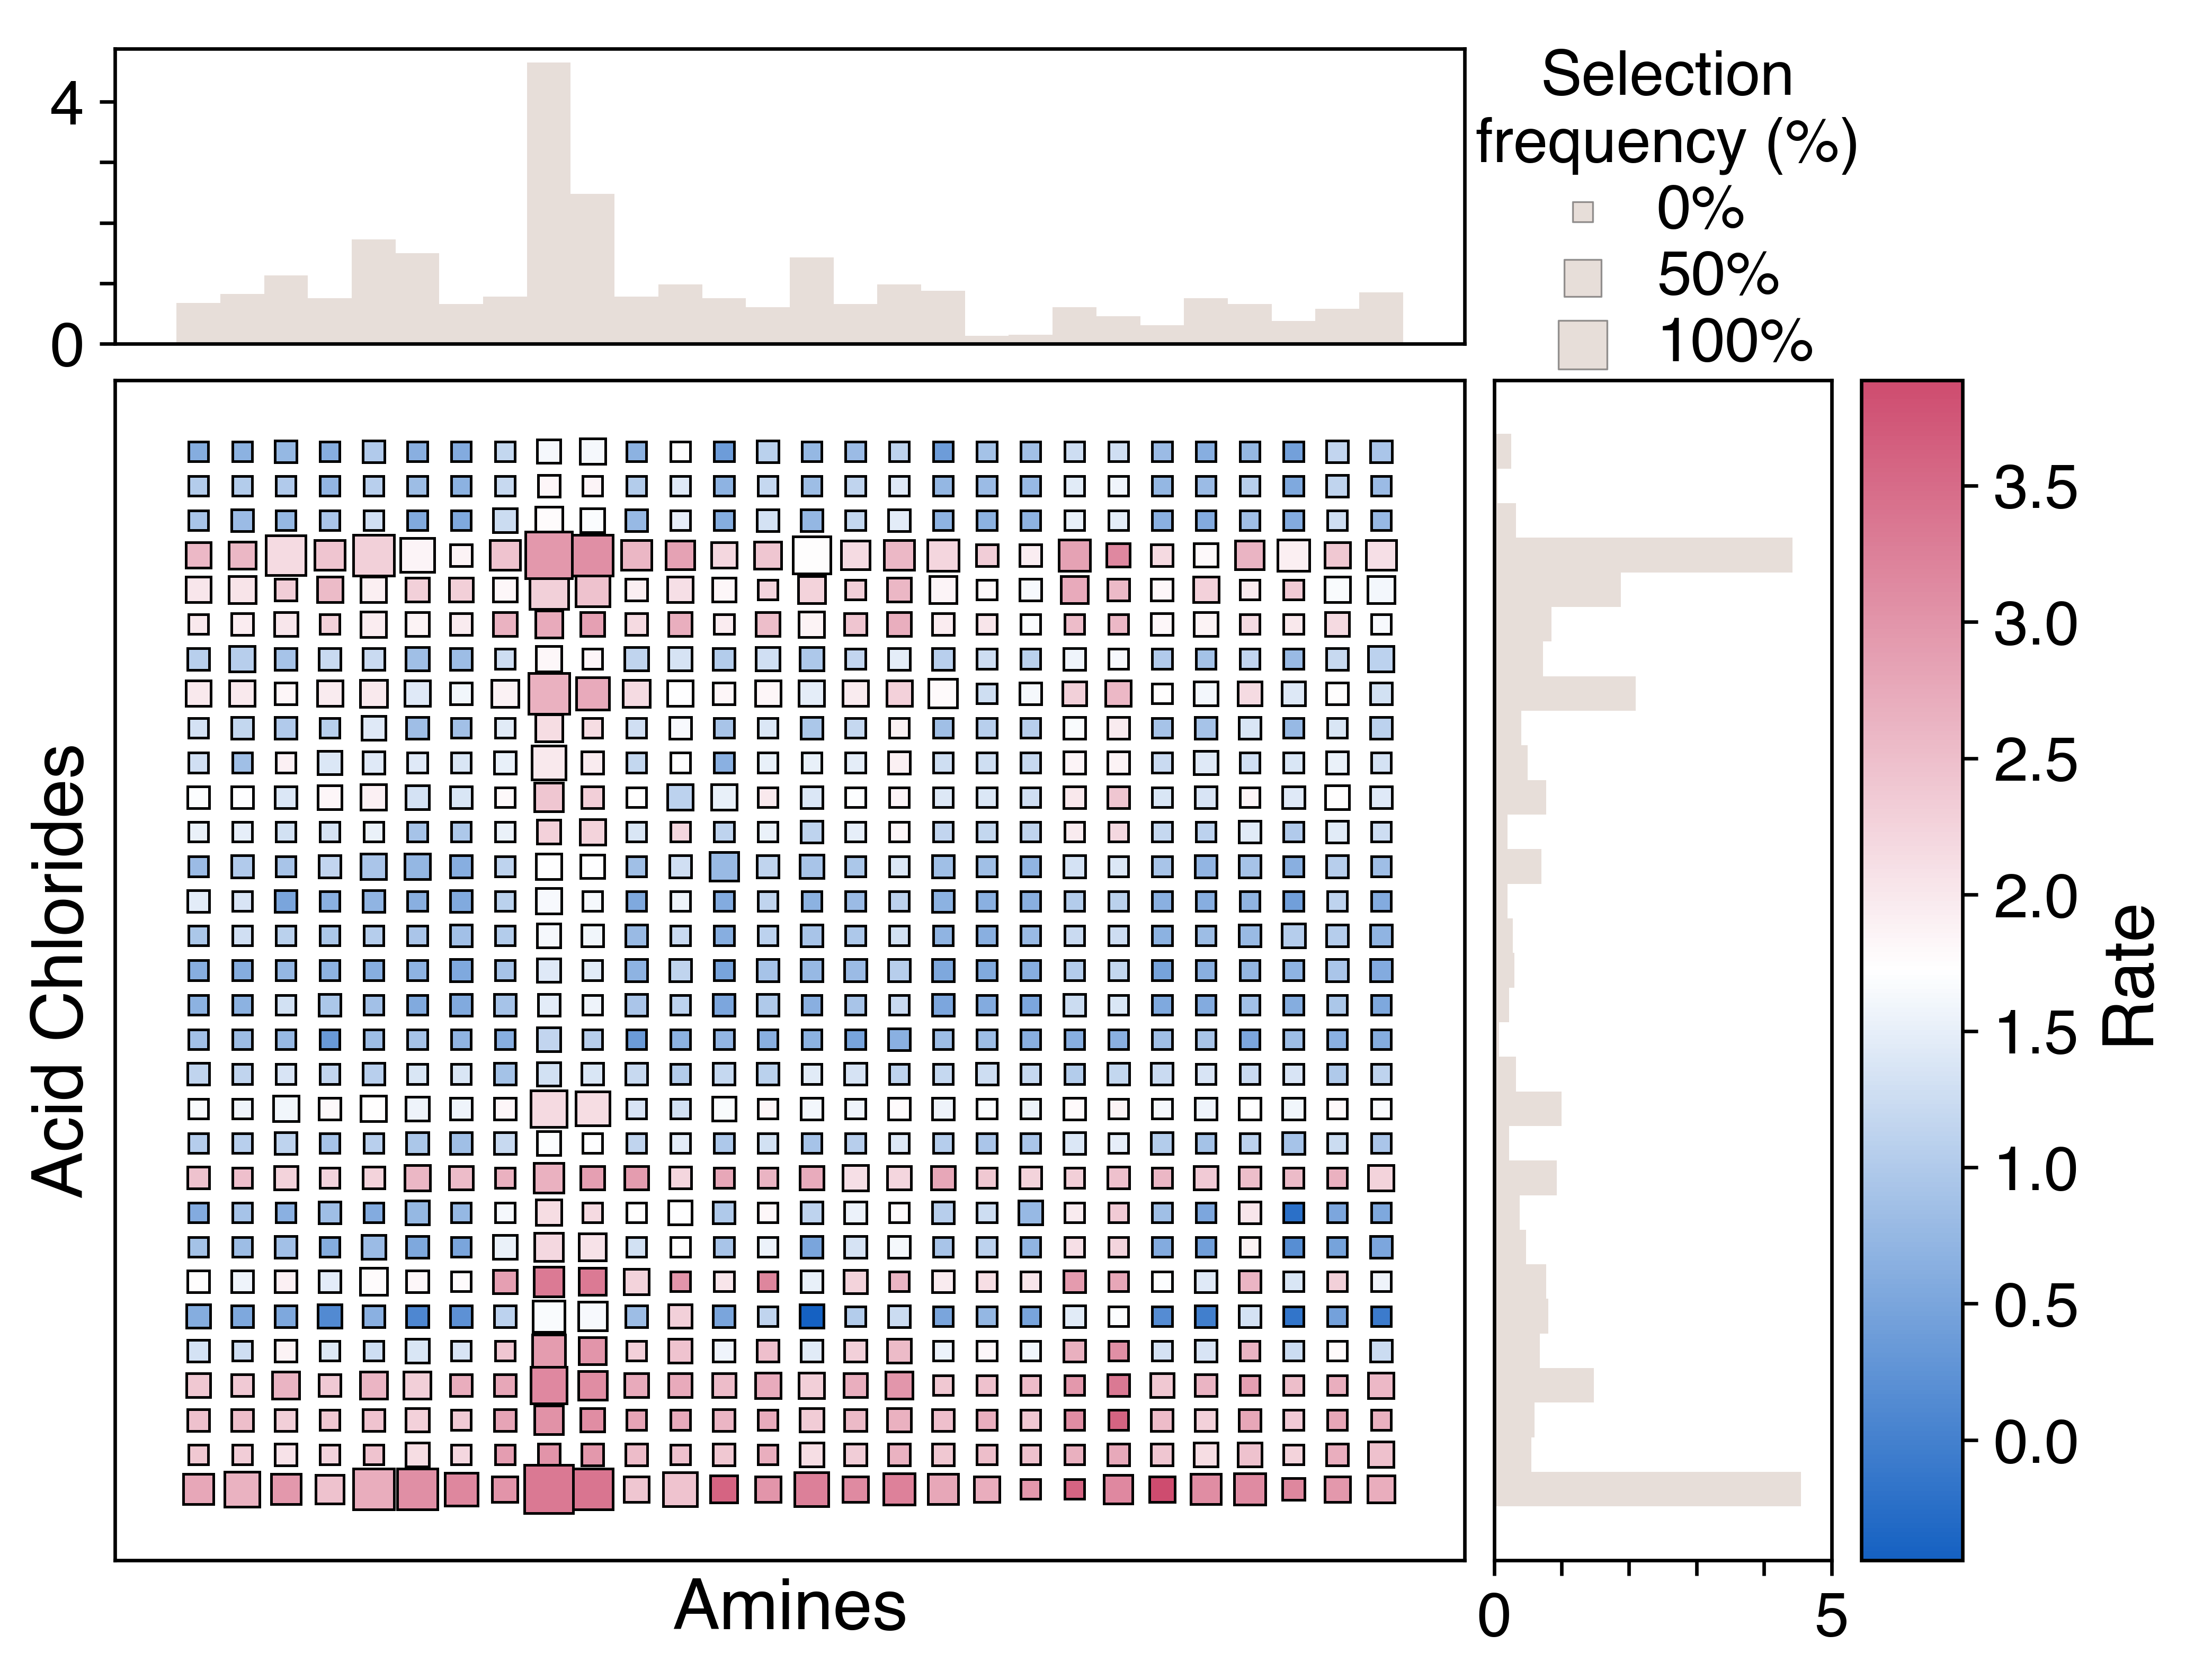

Average number of reactions selected for each acid chloride


,Selections,Av.rate in rxns
cocl,,
CC(=O)Cl,4.550,3.026743
CC(C)(C)C(=O)Cl,0.475,1.101941
CC(C)(C)c1ccc(C(=O)Cl)cc1,0.300,0.787245
CC(C)C(=O)Cl,0.675,1.914250
CCC(C(=O)Cl)c1ccccc1,0.775,2.184221
CCCCC(=O)Cl,0.550,2.466888
CCCCC(CC)C(=O)Cl,0.800,0.723831
CCCCCCC(=O)Cl,0.600,2.636501
CCCCCCCCCCCC(=O)Cl,1.475,2.660619


Average number of reactions selected for each amine


,Selections,Av.rate in rxns
amine,,
C1CCC(NC2CCCCC2)CC1,1.725,1.464322
C=Cc1ccc(N)cc1,0.775,1.539258
CC(=O)c1cccc(N)c1,0.875,1.355420
CC(C)NC(C)C,0.675,1.446727
CC(C)NC1CCCCC1,1.125,1.443687
CC(C)c1cccc(C(C)C)c1N,0.850,1.271178
CC1CCCC(C)N1,0.825,1.429618
CC1CN(C(=O)OC(C)(C)C)CC(C)N1,0.750,1.390352
CCCCCCCc1ccc(N)cc1,4.650,2.197285


Different amines selected per scope: 14.55  ±  3.0
Different acid chlorides selected per scope: 9.88  ±  2.24
Results for random selection


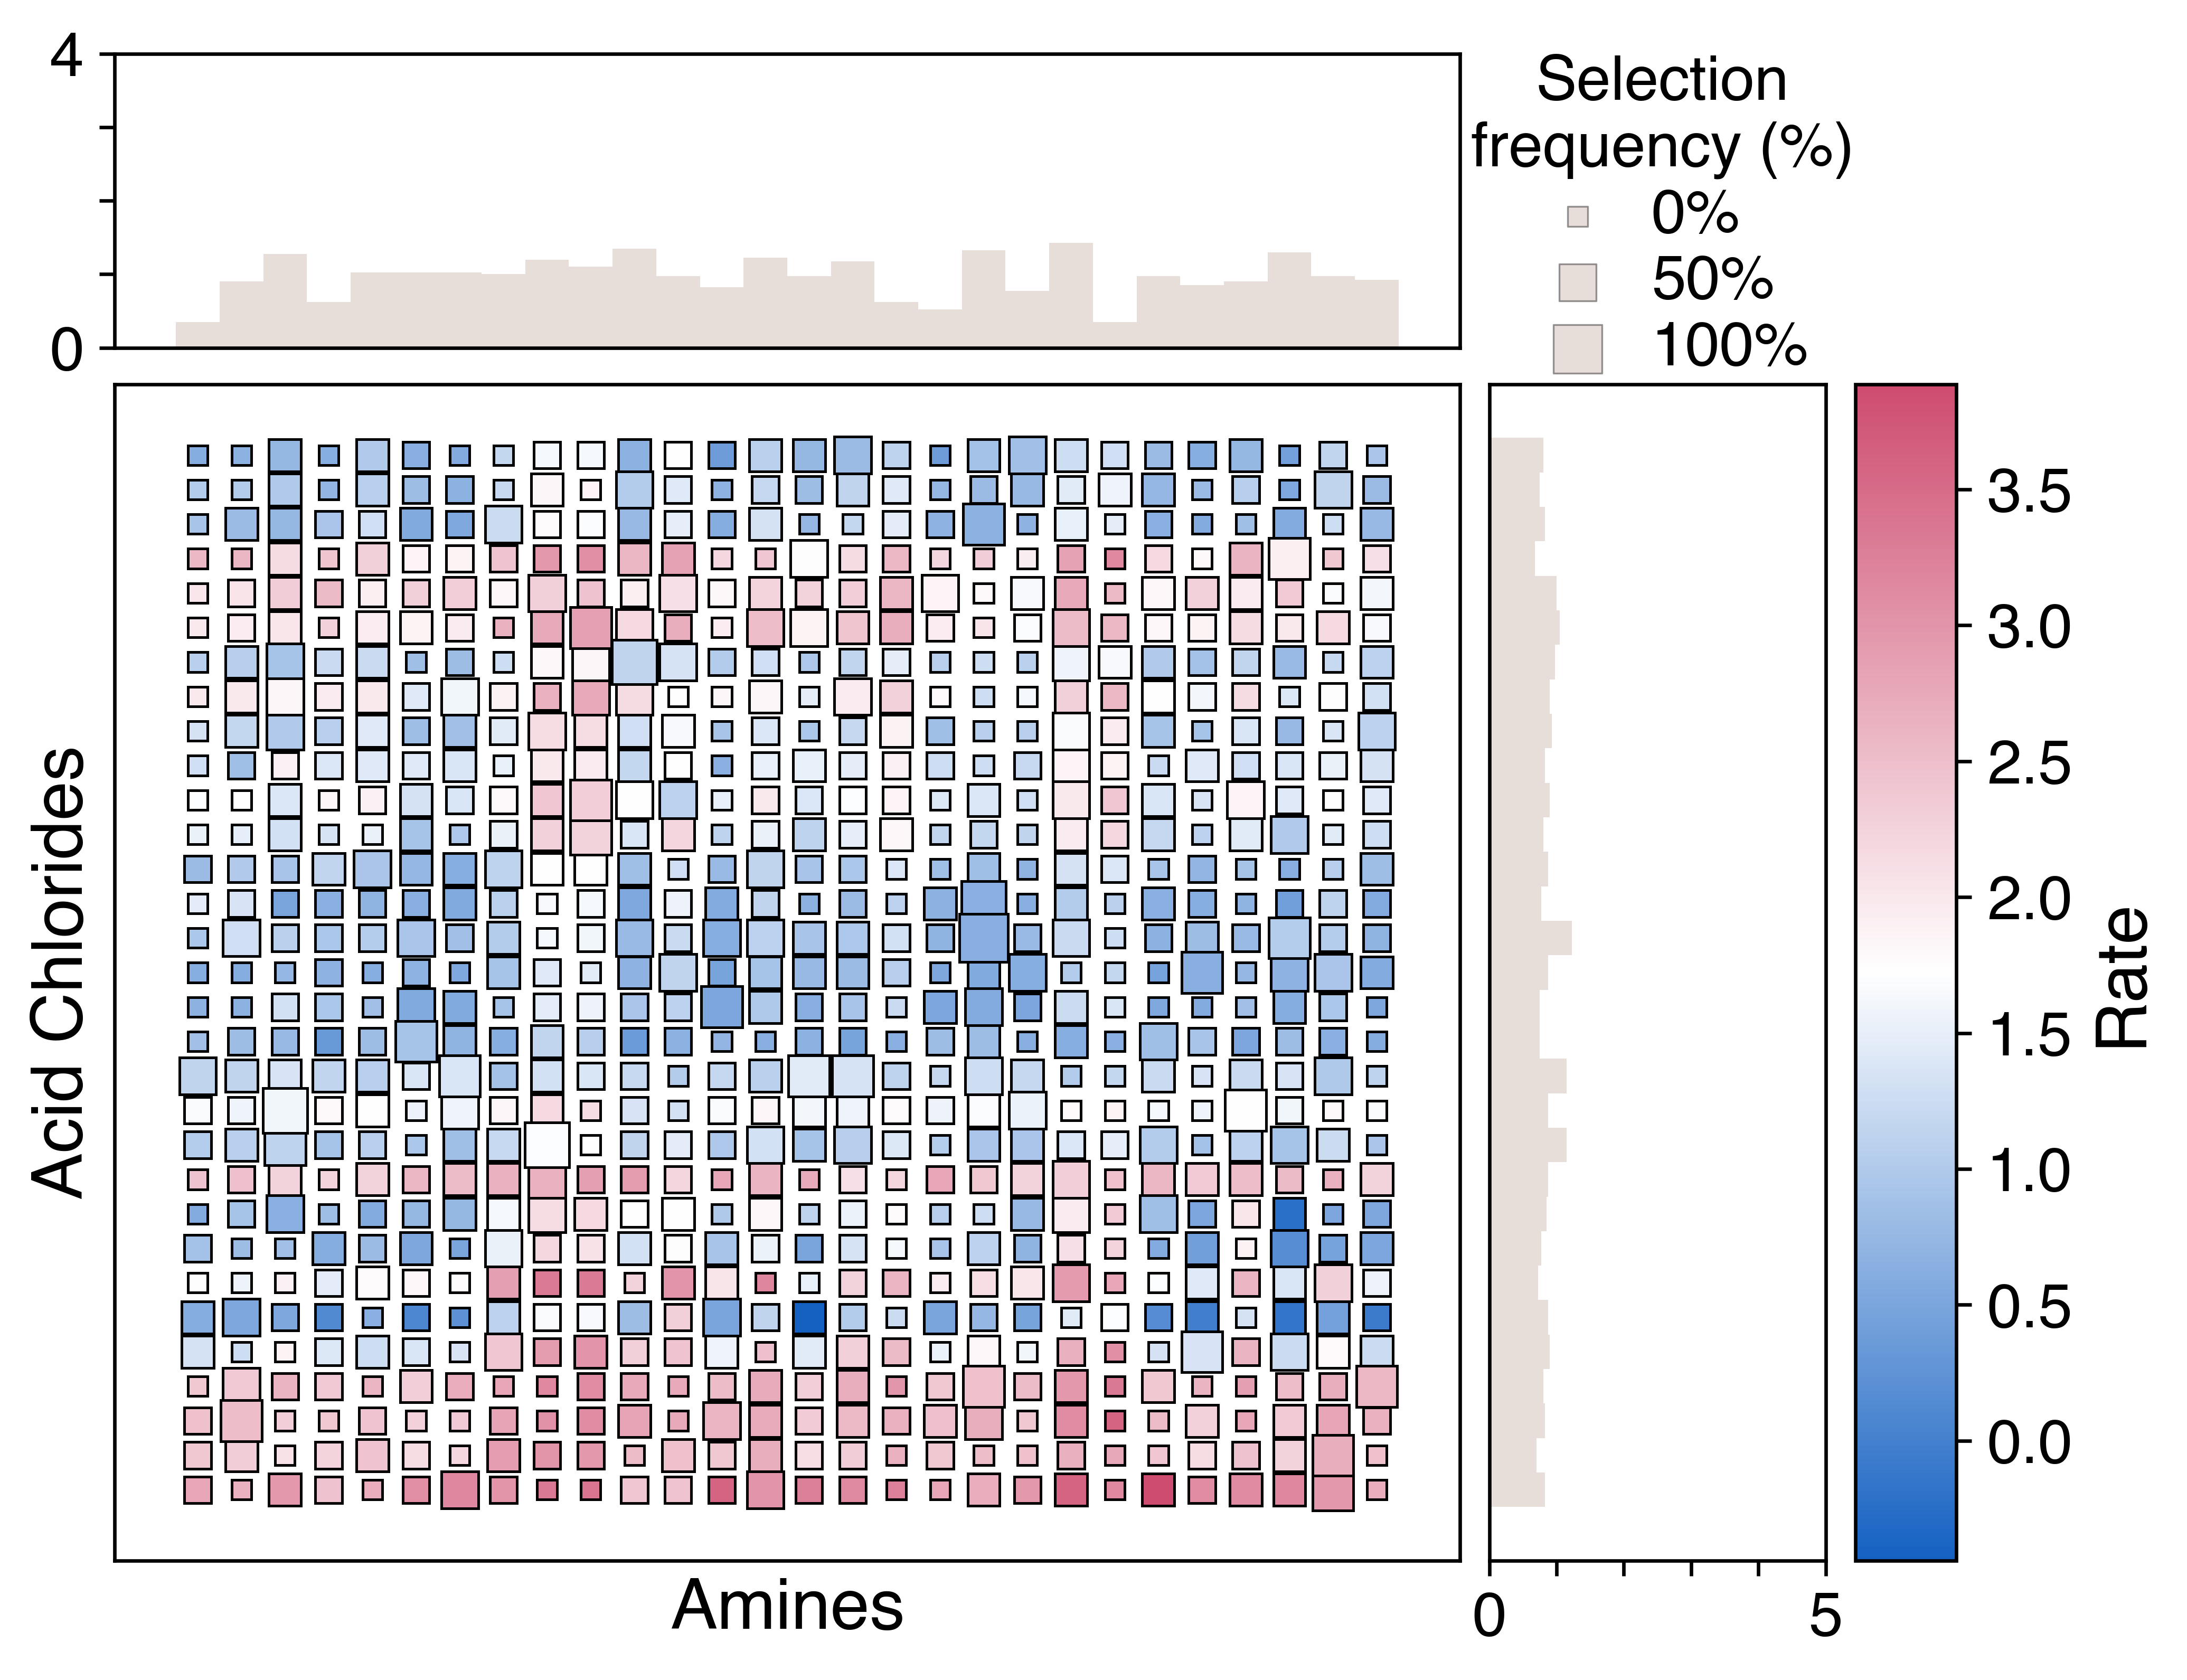

Average number of reactions selected for each acid chloride


,Selections,Av.rate in rxns
cocl,,
CC(=O)Cl,0.825,3.026743
CC(C)(C)C(=O)Cl,0.775,1.101941
CC(C)(C)c1ccc(C(=O)Cl)cc1,0.875,0.787245
CC(C)C(=O)Cl,0.900,1.914250
CCC(C(=O)Cl)c1ccccc1,0.725,2.184221
CCCCC(=O)Cl,0.700,2.466888
CCCCC(CC)C(=O)Cl,0.875,0.723831
CCCCCCC(=O)Cl,0.825,2.636501
CCCCCCCCCCCC(=O)Cl,0.800,2.660619


Average number of reactions selected for each amine


,Selections,Av.rate in rxns
amine,,
C1CCC(NC2CCCCC2)CC1,1.025,1.464322
C=Cc1ccc(N)cc1,1.350,1.539258
CC(=O)c1cccc(N)c1,0.525,1.355420
CC(C)NC(C)C,0.350,1.446727
CC(C)NC1CCCCC1,1.275,1.443687
CC(C)c1cccc(C(C)C)c1N,0.925,1.271178
CC1CCCC(C)N1,0.900,1.429618
CC1CN(C(=O)OC(C)(C)C)CC(C)N1,0.625,1.390352
CCCCCCCc1ccc(N)cc1,1.200,2.197285


Different amines selected per scope: 9.02  ±  2.17
Different acid chlorides selected per scope: 20.65  ±  1.41


In [66]:
def plot_count_summ(df_space, df_counts):
    """Processes the reaction count data."""

    # get the number of selections per seed for the reactions
    df_space["Sel. per seed"] = df_counts.sum(axis=1,numeric_only=True)/40

    # sort by selection frequency
    df_space.sort_values(by="Sel. per seed", ascending=True, inplace=True)

    # get the sum of selections per amine and acid chloride
    for idx in df_counts.index:
        df_counts.loc[idx,"amine"] = idx.split(".")[0]
        df_counts.loc[idx,"cocl"] = idx.split(".")[1]

    # group the counts by the amines
    amine_overview = df_counts.groupby("amine").sum()
    cocl_overview = df_counts.groupby("cocl").sum()
    amine_sum = amine_overview.sum(axis=1).apply(lambda x: x/40)
    cocl_sum = cocl_overview.sum(axis=1).apply(lambda x: x/40)
    cocl_sum = cocl_sum.to_frame(name="Selections")
    amine_sum = amine_sum.to_frame(name="Selections")

    # figure out the average rate per amine and acid chloride in the dataset
    amine_sum["Av.rate in rxns"] = df_space.groupby("amine")["rate"].mean()
    cocl_sum["Av.rate in rxns"] = df_space.groupby("cocl")["rate"].mean()

    # plot
    # datapoint size corresponds to rate
    size_min = 20
    size_max = 120
    val_min = df_space["Sel. per seed"].min()
    val_max = df_space["Sel. per seed"].max()
    sizes = [size_min + (val - val_min) * (size_max - size_min) / (val_max - val_min) for val in df_space["Sel. per seed"]]

    # normalize the colors for the selections
    norm = plt.Normalize(df_space["rate"].min(),df_space["rate"].max())

    # weights for the histogram
    weights = df_space["Sel. per seed"]

    # set up grid
    fig = plt.figure(figsize=(7.5, 6.3),dpi=600)
    gs = gridspec.GridSpec(2, 3,
        width_ratios=[4, 1, 0.3],
        height_ratios=[1, 4],
        hspace=0.05,
        wspace=0.05)
    ax_marg_x = fig.add_subplot(gs[0, 0])
    ax_joint  = fig.add_subplot(gs[1, 0], sharex=ax_marg_x)
    ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_joint)
    ax_cbar   = fig.add_subplot(gs[1, 2])

    # scatter plot: color is rate, size is how often selected
    sc = ax_joint.scatter(
        df_space["Dist_amine"],
        df_space["Dist_COCl"],
        c=df_space["rate"],
        s=sizes,
        cmap="Doyle_cont",
        edgecolors="black",
        alpha=1,
        norm=norm,
        marker="s",
        linewidths=0.6,
        antialiased=False
    )

    ax_joint.set_xlabel("Amines")
    ax_joint.set_ylabel("Acid Chlorides")
    ax_joint.set_xticks([])
    ax_joint.set_yticks([])

    # Weighted histograms for the selections
    bins_x = np.arange(len(amine_dict.keys()) + 1) - 0.5
    bins_y = np.arange(len(cocl_dict.keys()) + 1) - 0.5  
    ax_marg_x.hist(
        df_space["Dist_amine"],
        bins=bins_x,
        weights=weights,
        color=all_colors[3],
        alpha=0.4
    )

    ax_marg_y.hist(
        df_space["Dist_COCl"],
        bins=bins_y,
        weights=weights,
        orientation="horizontal",
        color=all_colors[3],
        alpha=0.4
    )
    ax_marg_x.tick_params(axis="x", labelbottom=True)
    ax_marg_x.set_yticks(np.arange(0, 5, 1))
    ax_marg_x.set_yticklabels([0,"","","",4])
    ax_marg_y.tick_params(axis="y", labelleft=True)
    ax_marg_y.set_xticks(np.arange(0, 6, 1))
    ax_marg_y.set_xticklabels([0,"","","","",5])

    # colorbar
    cbar = fig.colorbar(sc, cax=ax_cbar, norm=norm)
    cbar.set_label("Rate")


    # dummy points for size legend
    size_legend_vals = [df_space["Sel. per seed"].min(),
                        (df_space["Sel. per seed"].min()+df_space["Sel. per seed"].max())/2,
                        df_space["Sel. per seed"].max()]
    size_legend_labels = ["0%","50%","100%"]
    size_legend_points = [size_min + (val - val_min) * (size_max - size_min) / (val_max - val_min) for val in size_legend_vals]

    # dummy scatter for the size legend
    for s, label in zip(size_legend_points, size_legend_labels):
        ax_joint.scatter([], [], s=s, c=all_colors[3], alpha=0.4, label=label, marker="s", linewidths=0.4, edgecolors="k")

    legend = ax_joint.legend(
        title="Selection\nfrequency (%)",
        scatterpoints=1,
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(1.33,1.322),
        labelspacing = 0.15,
        handletextpad=0.2,
        borderpad=0.3
    )
    legend.get_title().set_ha("center")
    legend._legend_box.align = "center"

    plt.show()

    print("Average number of reactions selected for each acid chloride")
    display(cocl_sum)
    print("Average number of reactions selected for each amine")
    display(amine_sum)

    # get the average number of different amines and acid chlorides selected per scope
    amine_count = []
    cocl_count = []
    for seed in range(40):
        amine_count.append(len(df_counts[df_counts[seed]].groupby("amine").sum()))
        cocl_count.append(len(df_counts[df_counts[seed]].groupby("cocl").sum()))
    print("Different amines selected per scope:", round(np.mean(amine_count),2), " ± ", round(np.std(amine_count,ddof=1),2))
    print("Different acid chlorides selected per scope:", round(np.mean(cocl_count),2), " ± ", round(np.std(cocl_count,ddof=1),2))

    return amine_count, cocl_count
    
# run the function
print("Results for ScopeBO")
df_counts, df_space = get_selection_summary("./Results_Data/scope_balanced_pruning")
amine_count, cocl_count = plot_count_summ(df_space,df_counts)
abs_sel_mean.loc["Amines","ScopeBO"] = np.mean(amine_count)
abs_sel_std.loc["Amines","ScopeBO"] = np.std(amine_count,ddof=1)
abs_sel_mean.loc["Acid chlorides","ScopeBO"] = np.mean(cocl_count)
abs_sel_std.loc["Acid chlorides","ScopeBO"] = np.std(cocl_count,ddof=1)

print("")
print("Results for regular BO")
df_counts, df_space = get_selection_summary("./Results_Data/scope_balanced_no-pruning")
amine_count, cocl_count = plot_count_summ(df_space,df_counts)
abs_sel_mean.loc["Amines","Regular BO (EI)"] = np.mean(amine_count)
abs_sel_std.loc["Amines","Regular BO (EI)"] = np.std(amine_count,ddof=1)
abs_sel_mean.loc["Acid chlorides","Regular BO (EI)"] = np.mean(cocl_count)
abs_sel_std.loc["Acid chlorides","Regular BO (EI)"] = np.std(cocl_count,ddof=1)
print("")

print("Results for conv. selection")
df_counts, df_space = get_selection_summary("./Results_Data/scope_human-like-acq")
amine_count, cocl_count = plot_count_summ(df_space,df_counts)
abs_sel_mean.loc["Amines","Conv. selection"] = np.mean(amine_count)
abs_sel_std.loc["Amines","Conv. selection"] = np.std(amine_count,ddof=1)
abs_sel_mean.loc["Acid chlorides","Conv. selection"] = np.mean(cocl_count)
abs_sel_std.loc["Acid chlorides","Conv. selection"] = np.std(cocl_count,ddof=1)

print("Results for random selection")
df_counts, df_space = get_selection_summary("./Results_Data/scope_random_no-pruning")
amine_count, cocl_count = plot_count_summ(df_space,df_counts)
abs_sel_mean.loc["Amines","Random sel."] = np.mean(amine_count)
abs_sel_std.loc["Amines","Random sel."] = np.std(amine_count,ddof=1)
abs_sel_mean.loc["Acid chlorides","Random sel."] = np.mean(cocl_count)
abs_sel_std.loc["Acid chlorides","Random sel."] = np.std(cocl_count,ddof=1)

In [67]:
# import the clustering results
data_clustering = pd.read_csv("Results_Data/Cluster_Scopes/scope_doyle_samples.csv",index_col=0,header=0)

# get the different amines and acids that were selected by the clustering
subs_combs = data_clustering[data_clustering["rate"] != "PENDING"].index

abs_sel_mean.loc["Amines","Clustering"] = len(set([comb.split(".")[0] for comb in subs_combs]))
abs_sel_mean.loc["Acid chlorides","Clustering"] = len(set([comb.split(".")[1] for comb in subs_combs]))

abs_sel_std["Clustering"] = 0

# reorder the columns
abs_sel_mean = abs_sel_mean[["ScopeBO","Regular BO (EI)", "Conv. selection", "Clustering", "Random sel."]]
abs_sel_std = abs_sel_std[["ScopeBO","Regular BO (EI)", "Conv. selection", "Clustering", "Random sel."]]

abs_sel_mean.applymap(lambda x: str(round(x,3))) + " ± " + abs_sel_std.applymap(lambda x: str(round(x,3)))

,ScopeBO,Regular BO (EI),Conv. selection,Clustering,Random sel.
Amines,14.025 ± 1.672,14.8 ± 1.742,14.55 ± 2.995,9.0 ± 0,9.025 ± 2.166
Acid chlorides,14.6 ± 1.878,12.525 ± 1.519,9.875 ± 2.244,17.0 ± 0,20.65 ± 1.406


In [68]:
plot_colors = ["#CE4C6F","#C4ADA2","#1561C2", "#188F9D","#515798", "#CB7D85", "#A9A9A9"]

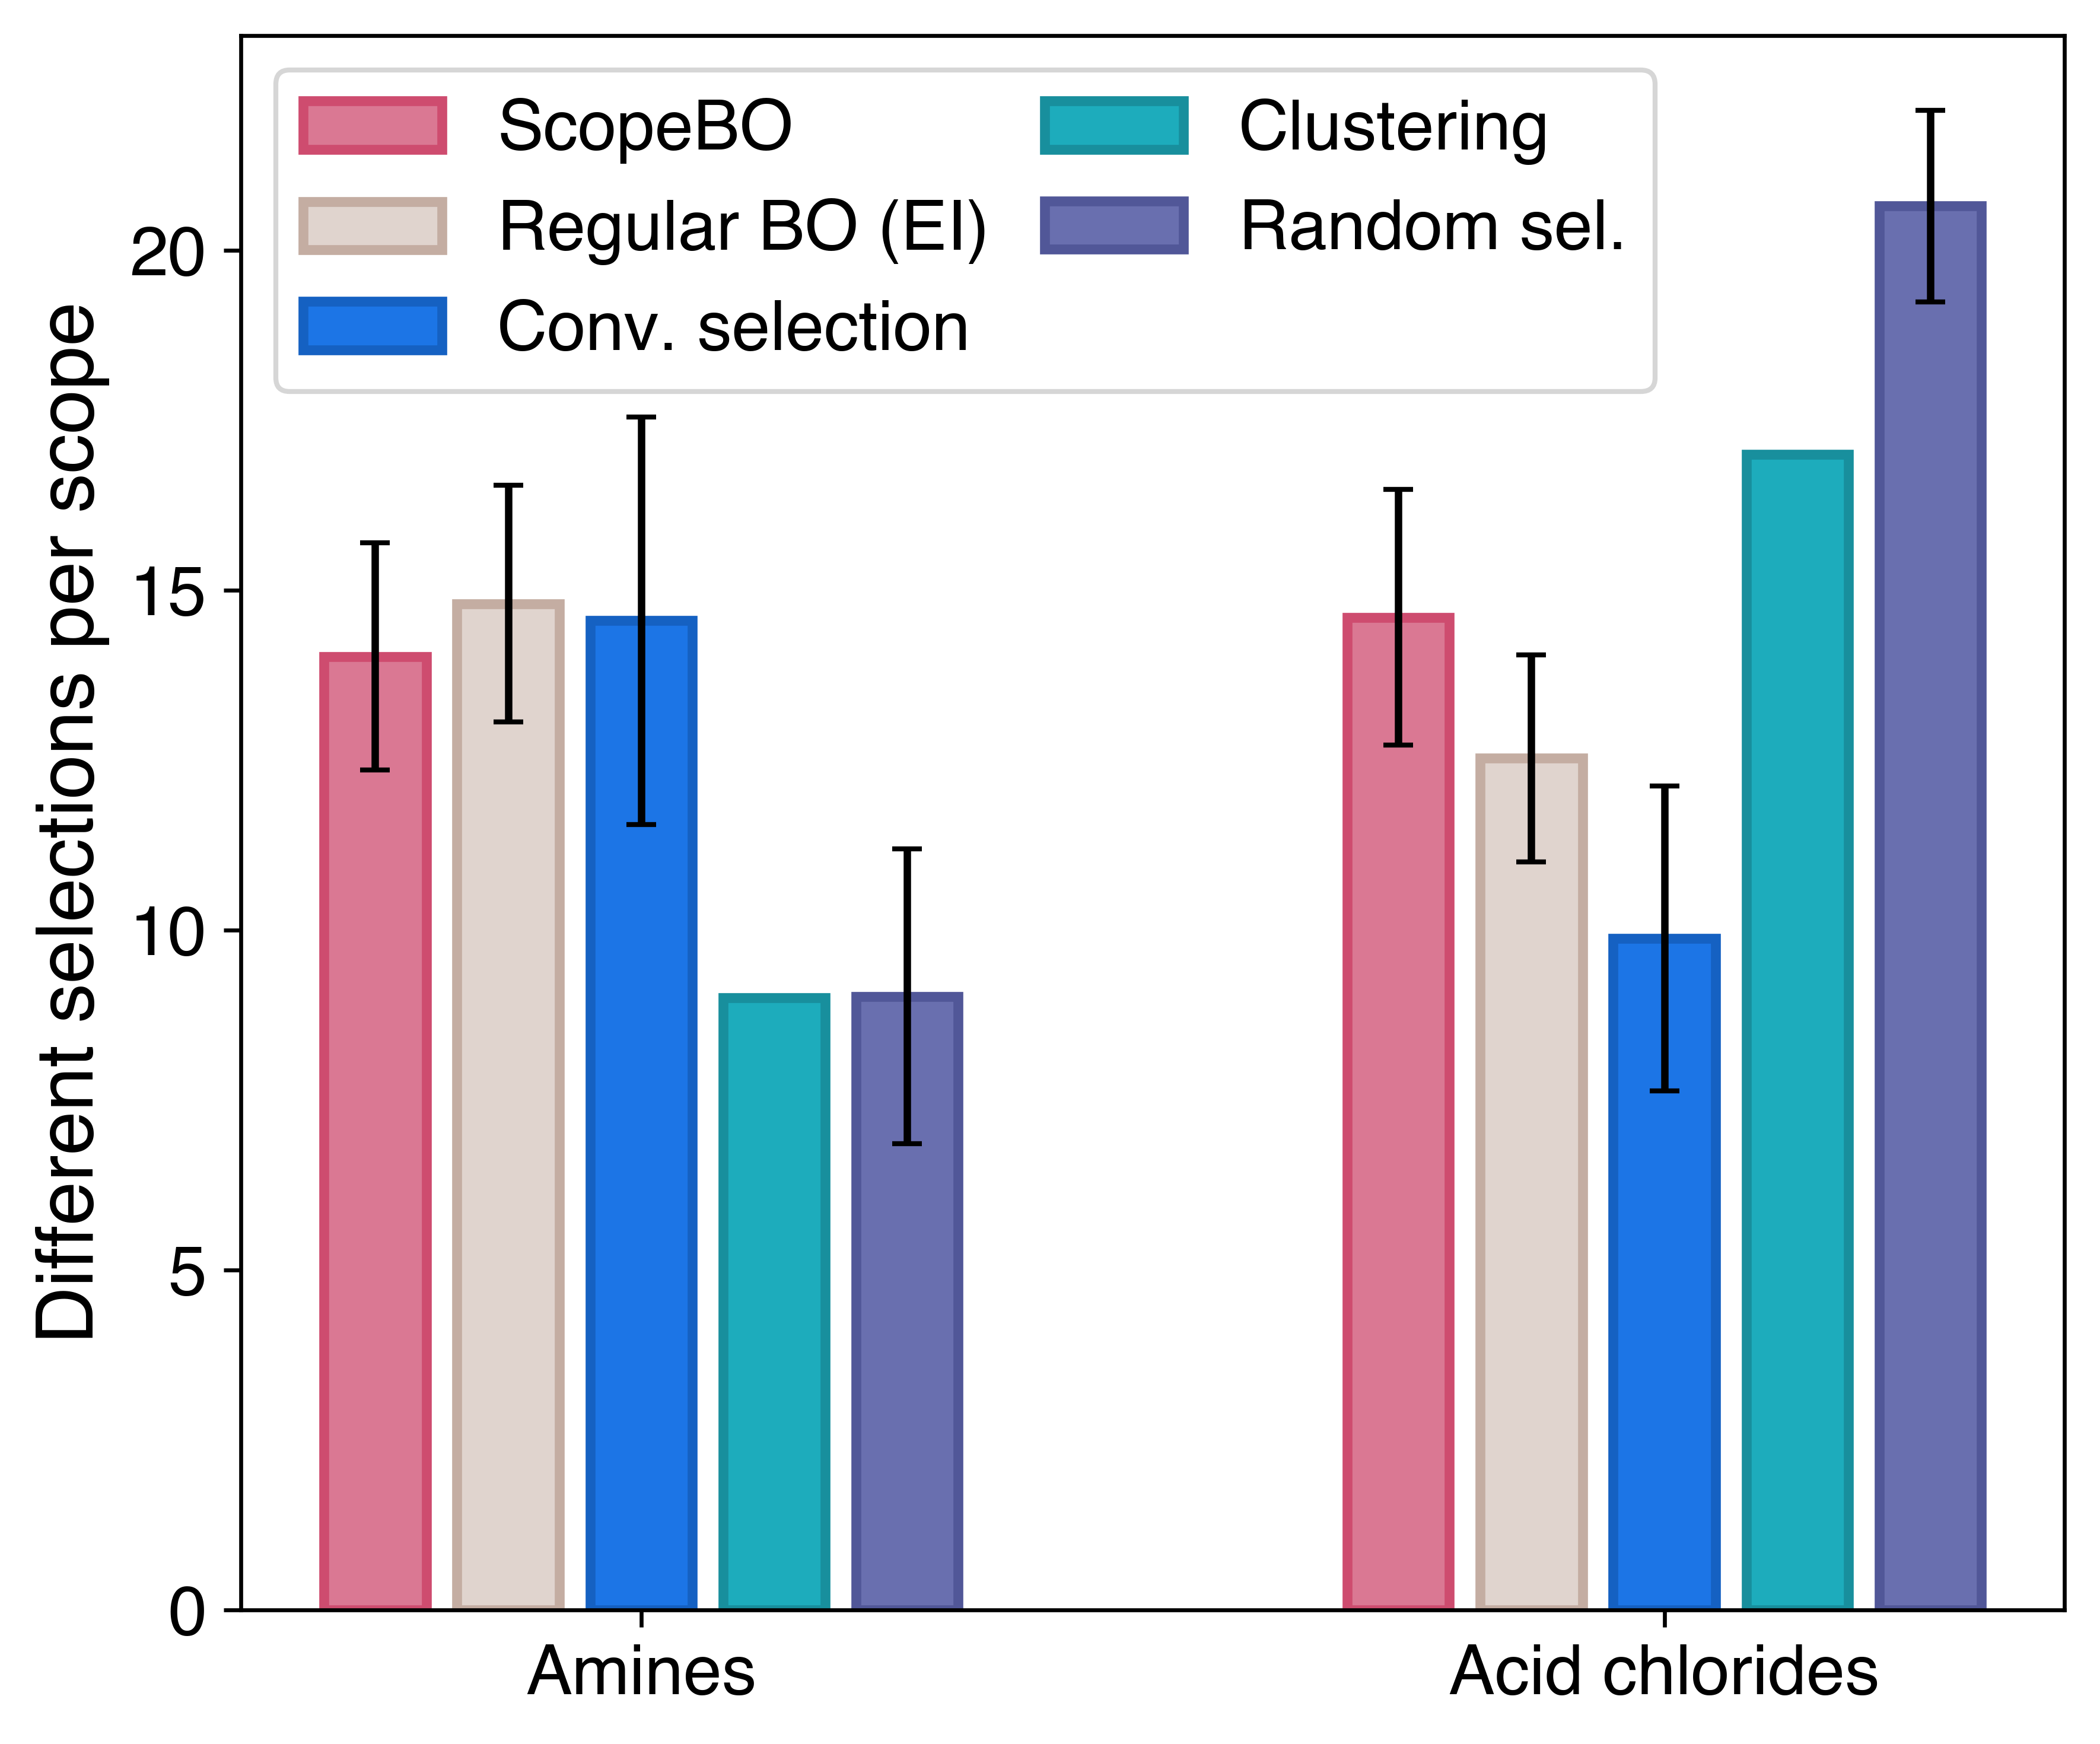

In [69]:
means = abs_sel_mean
stds  = abs_sel_std
groups = means.index.tolist()
methods = means.columns.tolist()
n_groups = len(groups)
n_methods = len(methods)

x = np.arange(n_groups)  # [0, 1]

bar_width = 0.1
offsets = np.linspace(
    -bar_width*(n_methods-1)/2,
     bar_width*(n_methods-1)/2,
     n_methods
) * 1.3

fig, ax = plt.subplots(figsize=(6,5), dpi=600)

for i, method in enumerate(methods):
    ax.bar(
        x + offsets[i],
        means[method],
        width=bar_width,
        yerr=stds[method],
        label=method,
        facecolor=adjust_lightness(plot_colors[i], 1.2),
        capsize=3 if method != "Clustering" else 0,
        edgecolor=plot_colors[i],
        linewidth=2
    )

ax.set_xticks(x)
ax.set_xticklabels(groups)

ax.set_ylabel("Different selections per scope")
ax.legend(ncol=2, columnspacing=0.8)

plt.tight_layout()
plt.show()

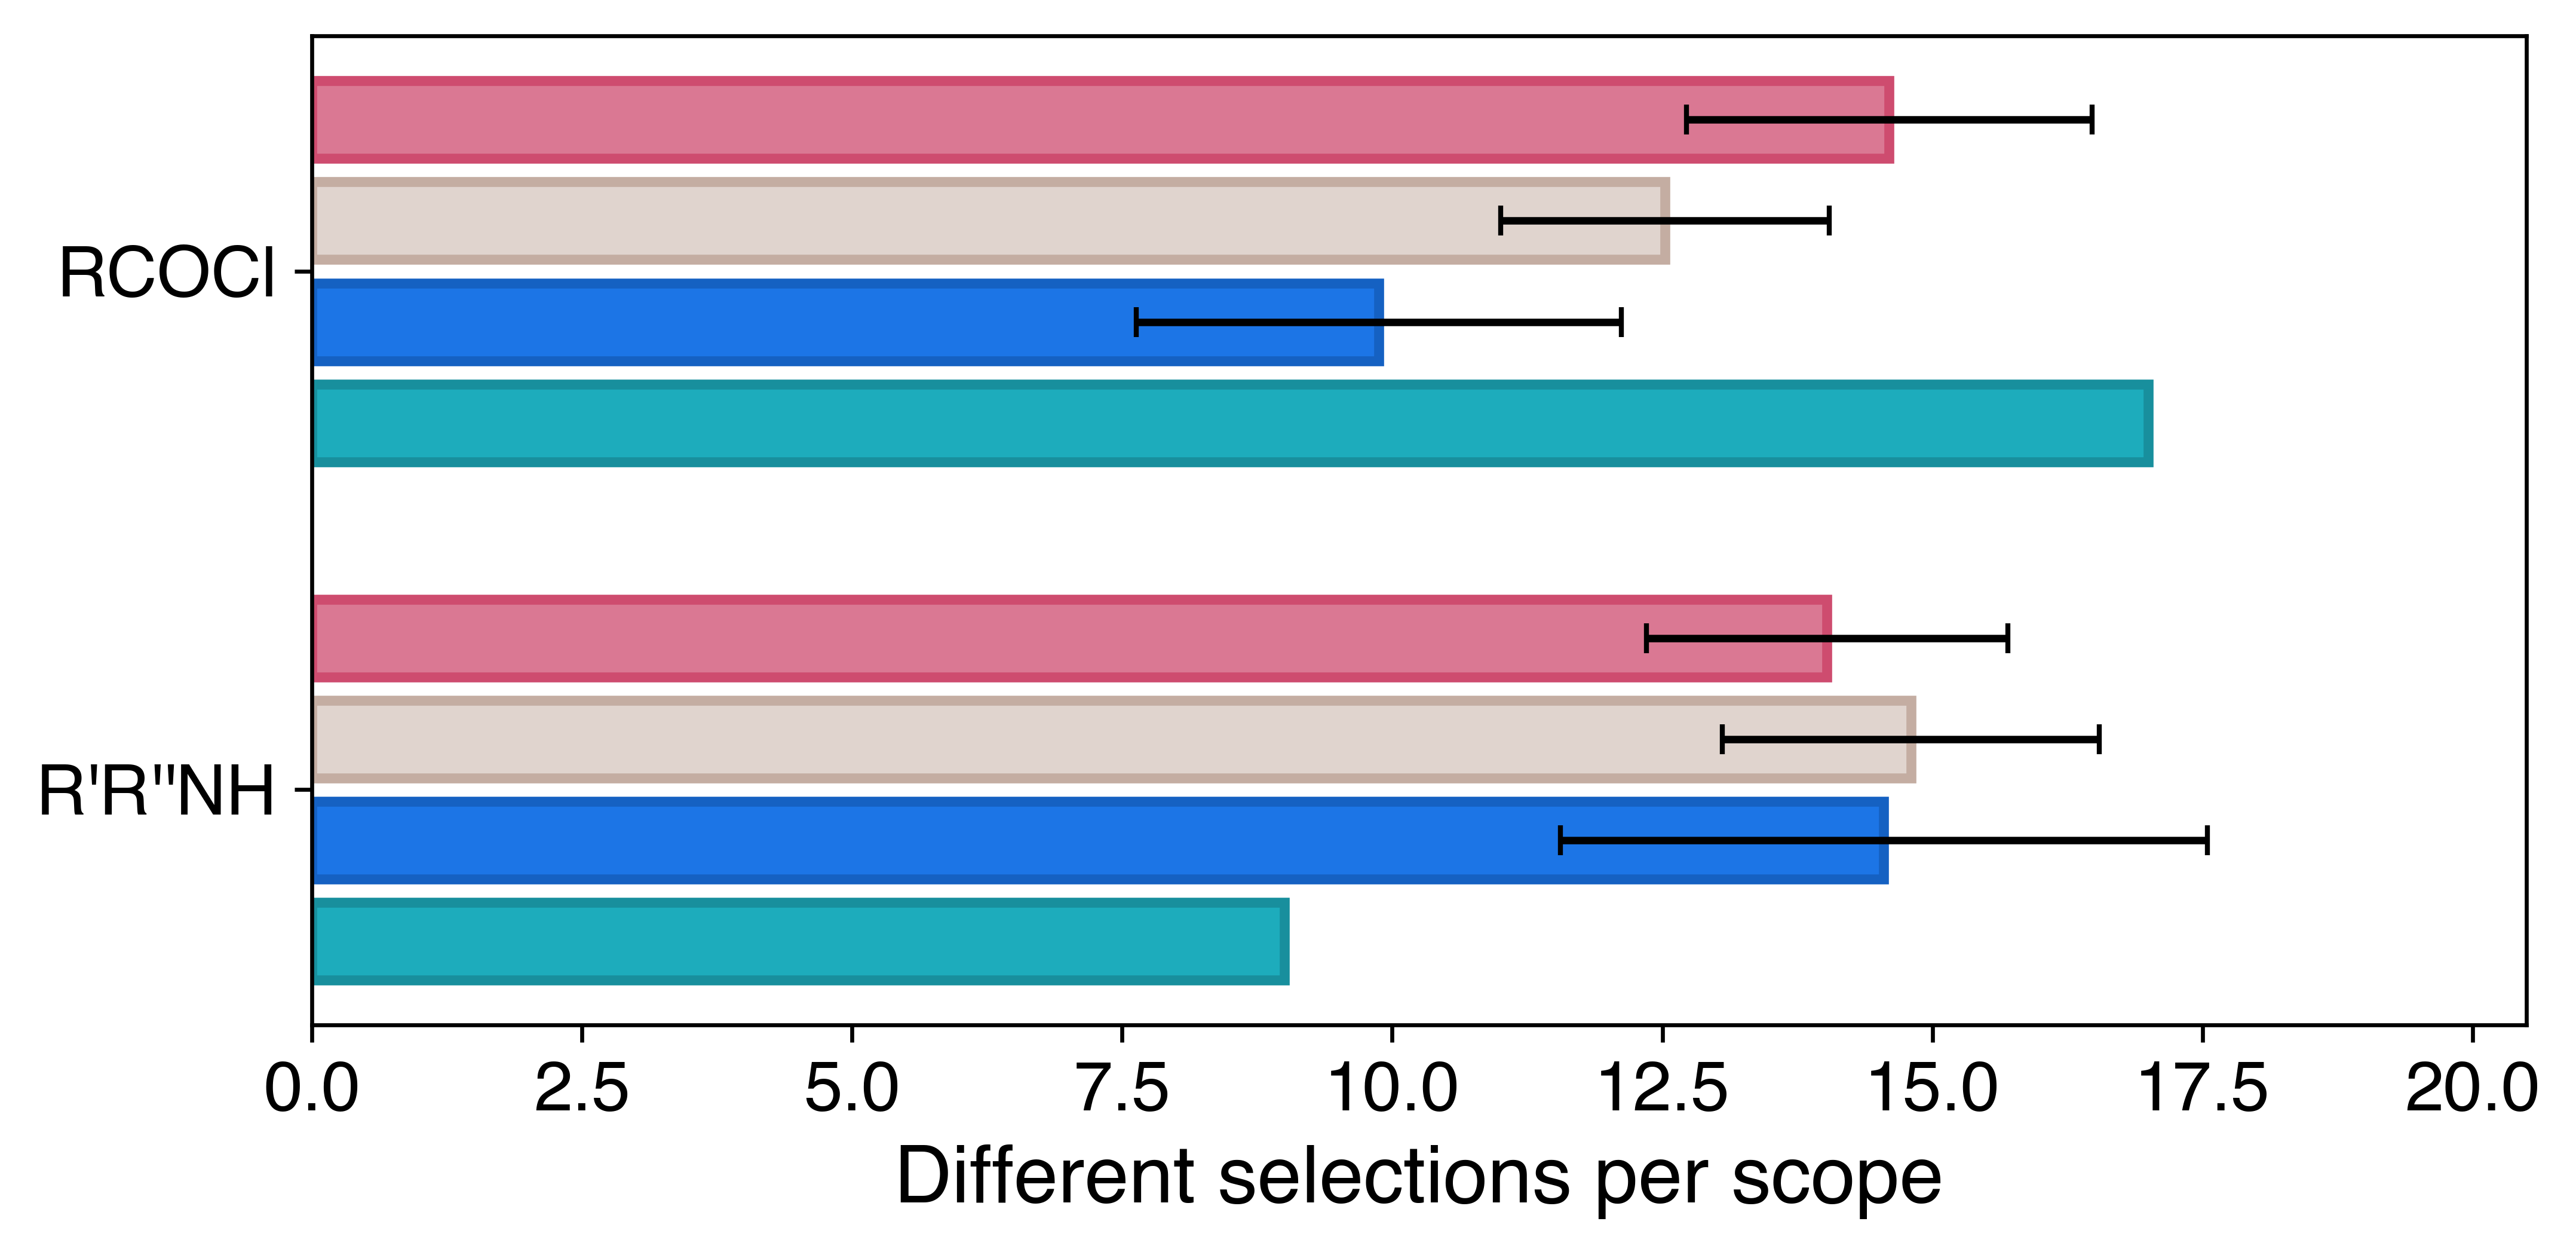

In [70]:
means = abs_sel_mean[["ScopeBO", "Regular BO (EI)", "Conv. selection", "Clustering"]]
stds  = abs_sel_std[["ScopeBO", "Regular BO (EI)","Conv. selection", "Clustering"]]
naming_conv = {"Acid chlorides":"RCOCl", "Amines":"R'R''NH"}
groups = [naming_conv[x] for x in abs_sel_mean.index]
methods = ["ScopeBO", "Regular BO (EI)","Conv. selection", "Clustering", ]
n_groups = len(groups)
n_methods = len(methods)

y = np.arange(n_groups)  # [0, 1]

bar_width = 0.15
offsets = np.linspace(
    -bar_width*(n_methods-1)/2,
     +bar_width*(n_methods-1)/2,
     n_methods
) * 1.3

fig, ax = plt.subplots(figsize=(7.3,3.6), dpi=600)

for i, method in enumerate(methods):
    ax.barh(
        y - offsets[i],
        means[method],
        height=bar_width,
        xerr=stds[method],
        label=method,
        facecolor=adjust_lightness(plot_colors[i], 1.2),
        capsize=3 if method != "Clustering" else 0,
        edgecolor=plot_colors[i],
        linewidth=2
    )

ax.set_yticks(x)
ax.set_yticklabels(groups)

ax.set_xlabel("Different selections per scope")
plt.xlim(0,20.5)
plt.tight_layout()
plt.show()

#### Calculate the Vendi scores for the separate reaction partners

In [71]:
# read in the featurizations for the separate reaction partners
dset_cocl = pd.read_csv("SB_dset_just_acid_chlorides.csv",index_col=0,header=0)
dset_amines = pd.read_csv("SB_dset_just_amines.csv",index_col=0,header=0)

# extend the cocl dataset (same features as the separate cocl for all substrate combinations that use it)
for idx in df_labelled.index:
    # get the cocl substrate
    smiles = idx.split(".")[1]
    dset_cocl.loc[idx] = dset_cocl.loc[smiles]
# drop the rows with the separate starting materials
dset_cocl = dset_cocl.drop(cocl_dict.keys(), axis=0)
print(f"dset_cocl now has {len(dset_cocl)} entries.")

# extend the amien dataset (same features as the separate amine for all substrate combinations that use it)
for idx in df_labelled.index:
    # get the amine substrate
    smiles = idx.split(".")[0]
    dset_amines.loc[idx] = dset_amines.loc[smiles]
# drop the rows with the separate starting materials
dset_amines = dset_amines.drop(amine_dict.keys(), axis=0)
print(f"dset_amine now has {len(dset_amines)} entries.")

# make covariance matrices for the two datasets
from Code.utils import obtain_full_covar_matrix
dset_amines.sort_index(inplace=True)
dset_cocl.sort_index(inplace=True)
dset_amines["dummy_obj"] = 1
dset_cocl["dummy_obj"] = 1
dset_amines.to_csv("df_dummy_amines.csv", index = True, header = True)
dset_cocl.to_csv("df_dummy_cocl.csv", index = True, header = True)

cov_mat_amines = obtain_full_covar_matrix(objectives = ["dummy_obj"], directory = ".", filename="df_dummy_amines.csv")
cov_mat_cocl = obtain_full_covar_matrix(objectives = ["dummy_obj"], directory = ".", filename="df_dummy_cocl.csv")

dset_cocl now has 868 entries.
dset_amine now has 868 entries.


In [72]:
# # recalculate the vendi scores for both separate starting materials
# # NOTE: The labelled data with the DFT features is required to assign the samples but the featurization is NOT used.
# for acq in ["balanced_pruning","balanced_no-pruning","human-like-acq","random_no-pruning"]:
#     Benchmark().change_featurization(name_feat = "just_amines",
#                                 name_results=f"./Results_Data/scope_{acq}",
#                                 filename_labelled=f"./SB_dset.csv",
#                                 cov_mat= cov_mat_amines,
#                                 directory=".")
#     Benchmark().change_featurization(name_feat = "just_cocl",
#                                 name_results=f"./Results_Data/scope_{acq}",
#                                 filename_labelled=f"./SB_dset.csv",
#                                 cov_mat= cov_mat_cocl,
#                                 directory=".")

In [73]:
sep_vendis_mean = pd.DataFrame(np.nan, index = ["amines","cocl"],columns=["balanced_pruning","balanced_no-pruning","human-like-acq","random_no-pruning"])
sep_vendis_std = pd.DataFrame(np.nan, index = ["amines","cocl"],columns=["balanced_pruning","balanced_no-pruning","human-like-acq","random_no-pruning"])

for acq in ["balanced_pruning","balanced_no-pruning","human-like-acq","random_no-pruning"]:
    for sub in ["amines","cocl"]:
        dfs = Benchmark().progress_plot(budget=27, type_results="Vendi",name_results=f"./Results_Data/scope_{acq}_just_{sub}_feat",
                          bounds = bounds, show_plot=False)
        sep_vendis_mean.loc[sub,acq] = dfs["means"].iloc[-1].values
        sep_vendis_std.loc[sub,acq] = dfs["stdev"].iloc[-1].values   

    

In [74]:
for df in [sep_vendis_std,sep_vendis_mean]:
    df.rename({"balanced_pruning":"ScopeBO",
                                 "balanced_no-pruning":"Reg. BO (EI)",
                                 "human-like-acq": "Conv. sel.",
                                 "random_no-pruning":"Random sel."}, axis = 1, inplace=True)
    df.rename({"amines":"Amines",
                                "cocl":"Acid chlorides"}, axis = 0, inplace=True)

In [75]:
# calculate the Vendi scores for all amines and all acids for comparison
full_vendi_amines = ScopeBO().get_vendi_score(objectives=["dummy_obj"],filename="df_dummy_amines.csv")
full_vendi_cocl = ScopeBO().get_vendi_score(objectives=["dummy_obj"],filename="df_dummy_cocl.csv")

In [76]:
# calculate the values for Doyle clustering

dset_amines_clust = dset_amines.copy()
dset_cocl_clust = dset_cocl.copy()

for idx in data_clustering.index:
    dset_amines_clust.loc[idx,"dummy_obj"] = data_clustering.loc[idx,"rate"]
    dset_cocl_clust.loc[idx,"dummy_obj"] = data_clustering.loc[idx,"rate"]
dset_amines_clust.to_csv("df_dummy_amines.csv", index = True, header = True)
dset_cocl_clust.to_csv("df_dummy_cocl.csv", index = True, header = True)
amine_clust = ScopeBO().get_vendi_score(objectives=["dummy_obj"],filename="df_dummy_amines.csv")
cocl_clust = ScopeBO().get_vendi_score(objectives=["dummy_obj"],filename="df_dummy_cocl.csv")

In [77]:
sep_vendis_mean.loc["Amines","Clustering"] = amine_clust
sep_vendis_mean.loc["Acid chlorides","Clustering"] = cocl_clust
sep_vendis_std.loc["Amines","Clustering"] = 0
sep_vendis_std.loc["Acid chlorides","Clustering"] = 0

In [78]:
for col in sep_vendis_mean.columns:
    label = col
    if label == "Reg. BO (EI)":
        label = "EI"
    elif label == "Random sel.":
        label = "Random"
    elif label == "Clustering":
        label = "Doyle_clustering"
    elif label == "Conv. sel.":
        label = "Conv. selection"
    sep_vendis_mean.loc["Combi",col] = map_df.loc["Vendi score",label]
    sep_vendis_std.loc["Combi",col] = std_df.loc["Vendi score",label]


In [ ]:
# reorder the columns
sep_vendis_mean = sep_vendis_mean[["ScopeBO","Reg. BO (EI)", "Conv. sel.", "Clustering", "Random sel."]]
sep_vendis_std = sep_vendis_std[["ScopeBO","Reg. BO (EI)", "Conv. sel.", "Clustering", "Random sel."]]

sep_vendis_mean.applymap(lambda x: str(round(x,3))) + " ± " + sep_vendis_std.applymap(lambda x: str(round(x,3)))

,ScopeBO,Reg. BO (EI),Conv. sel.,Clustering,Random sel.
Amines,4.304 ± 0.299,3.882 ± 0.466,3.397 ± 0.7,2.466 ± 0.0,2.469 ± 0.639
Acid chlorides,5.09 ± 0.344,4.066 ± 0.324,3.347 ± 0.738,4.312 ± 0.0,3.999 ± 0.338
Combi,8.267 ± 0.629,6.532 ± 0.659,5.171 ± 0.887,5.357 ± 0.0,4.777 ± 0.754


In [80]:
def Vendi_plot(sep_vendis_mean,sep_vendis_std):
    # Plot the results
    x = sep_vendis_mean.iloc[0]
    y = sep_vendis_mean.iloc[1]
    xerr = sep_vendis_std.iloc[0]
    yerr = sep_vendis_std.iloc[1]
    raw_size_data = sep_vendis_mean.loc["Combi"]

    size_min, size_max = 100, 300
    data_min, data_max= raw_size_data.min(), raw_size_data.max()
    sizes = size_min + (raw_size_data - data_min) * (size_max - size_min) / (data_max - data_min)

    labels = sep_vendis_mean.columns.to_list()
    color_map = {label: plot_colors[i] for i, label in enumerate(labels)}
    colors = [color_map[label] for label in labels]
    alpha_val = 1

    plt.figure(figsize=(6,6),dpi=600)
    plt.scatter(x, y, s=sizes, alpha=alpha_val, c = colors, edgecolors="k",zorder=2)
    # Add error bars
    plt.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt='none',
        ecolor='black',
        elinewidth=1,
        capsize=3,
        alpha=0.9,
        zorder=1
    )

    # lines for the full vendi score of all amines/ cocl
    plt.axhline(y=full_vendi_amines, color=all_colors[6], linestyle=':', linewidth=1.5, zorder=0)
    plt.axvline(x=full_vendi_cocl, color=all_colors[6], linestyle=':', linewidth=1.5, zorder=0)

    plt.xlabel('Vendi score of selected amines')
    plt.ylabel('Vendi score of selected acid chlorides')

    # legend for scope score
    # Choose representative raw size values
    size_legend_values = np.linspace(raw_size_data.min(), raw_size_data.max(), 3)
    size_legend_sizes = size_min + (size_legend_values - data_min) * (size_max - size_min) / (data_max - data_min)
    size_legend = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=f'{val:.1f}',
            markerfacecolor=all_colors[6],
            alpha=alpha_val,
            markeredgecolor='k',
            markersize=np.sqrt(s)
        )
        for val, s in zip(size_legend_values, size_legend_sizes)
    ]

    # legend for the methods
    color_legend = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=label,
            markerfacecolor=color_map[label],
            alpha=alpha_val,
            markeredgecolor='k',
            markersize=10
        )
        for label in labels
    ]

    # Add legends
    first_legend = plt.legend(handles=color_legend, loc = "upper left", frameon=True,
                            ncol=2, labelspacing=0.3, handletextpad=0.2, columnspacing = 0.5)
    plt.gca().add_artist(first_legend)
    second_legend = plt.legend(handles=size_legend, title="Vendi score\nof substrate\ncombinations", frameon=True, loc="lower left")
    second_legend.get_title().set_ha("center")

    plt.xlim(1.6,4.8)
    plt.show()

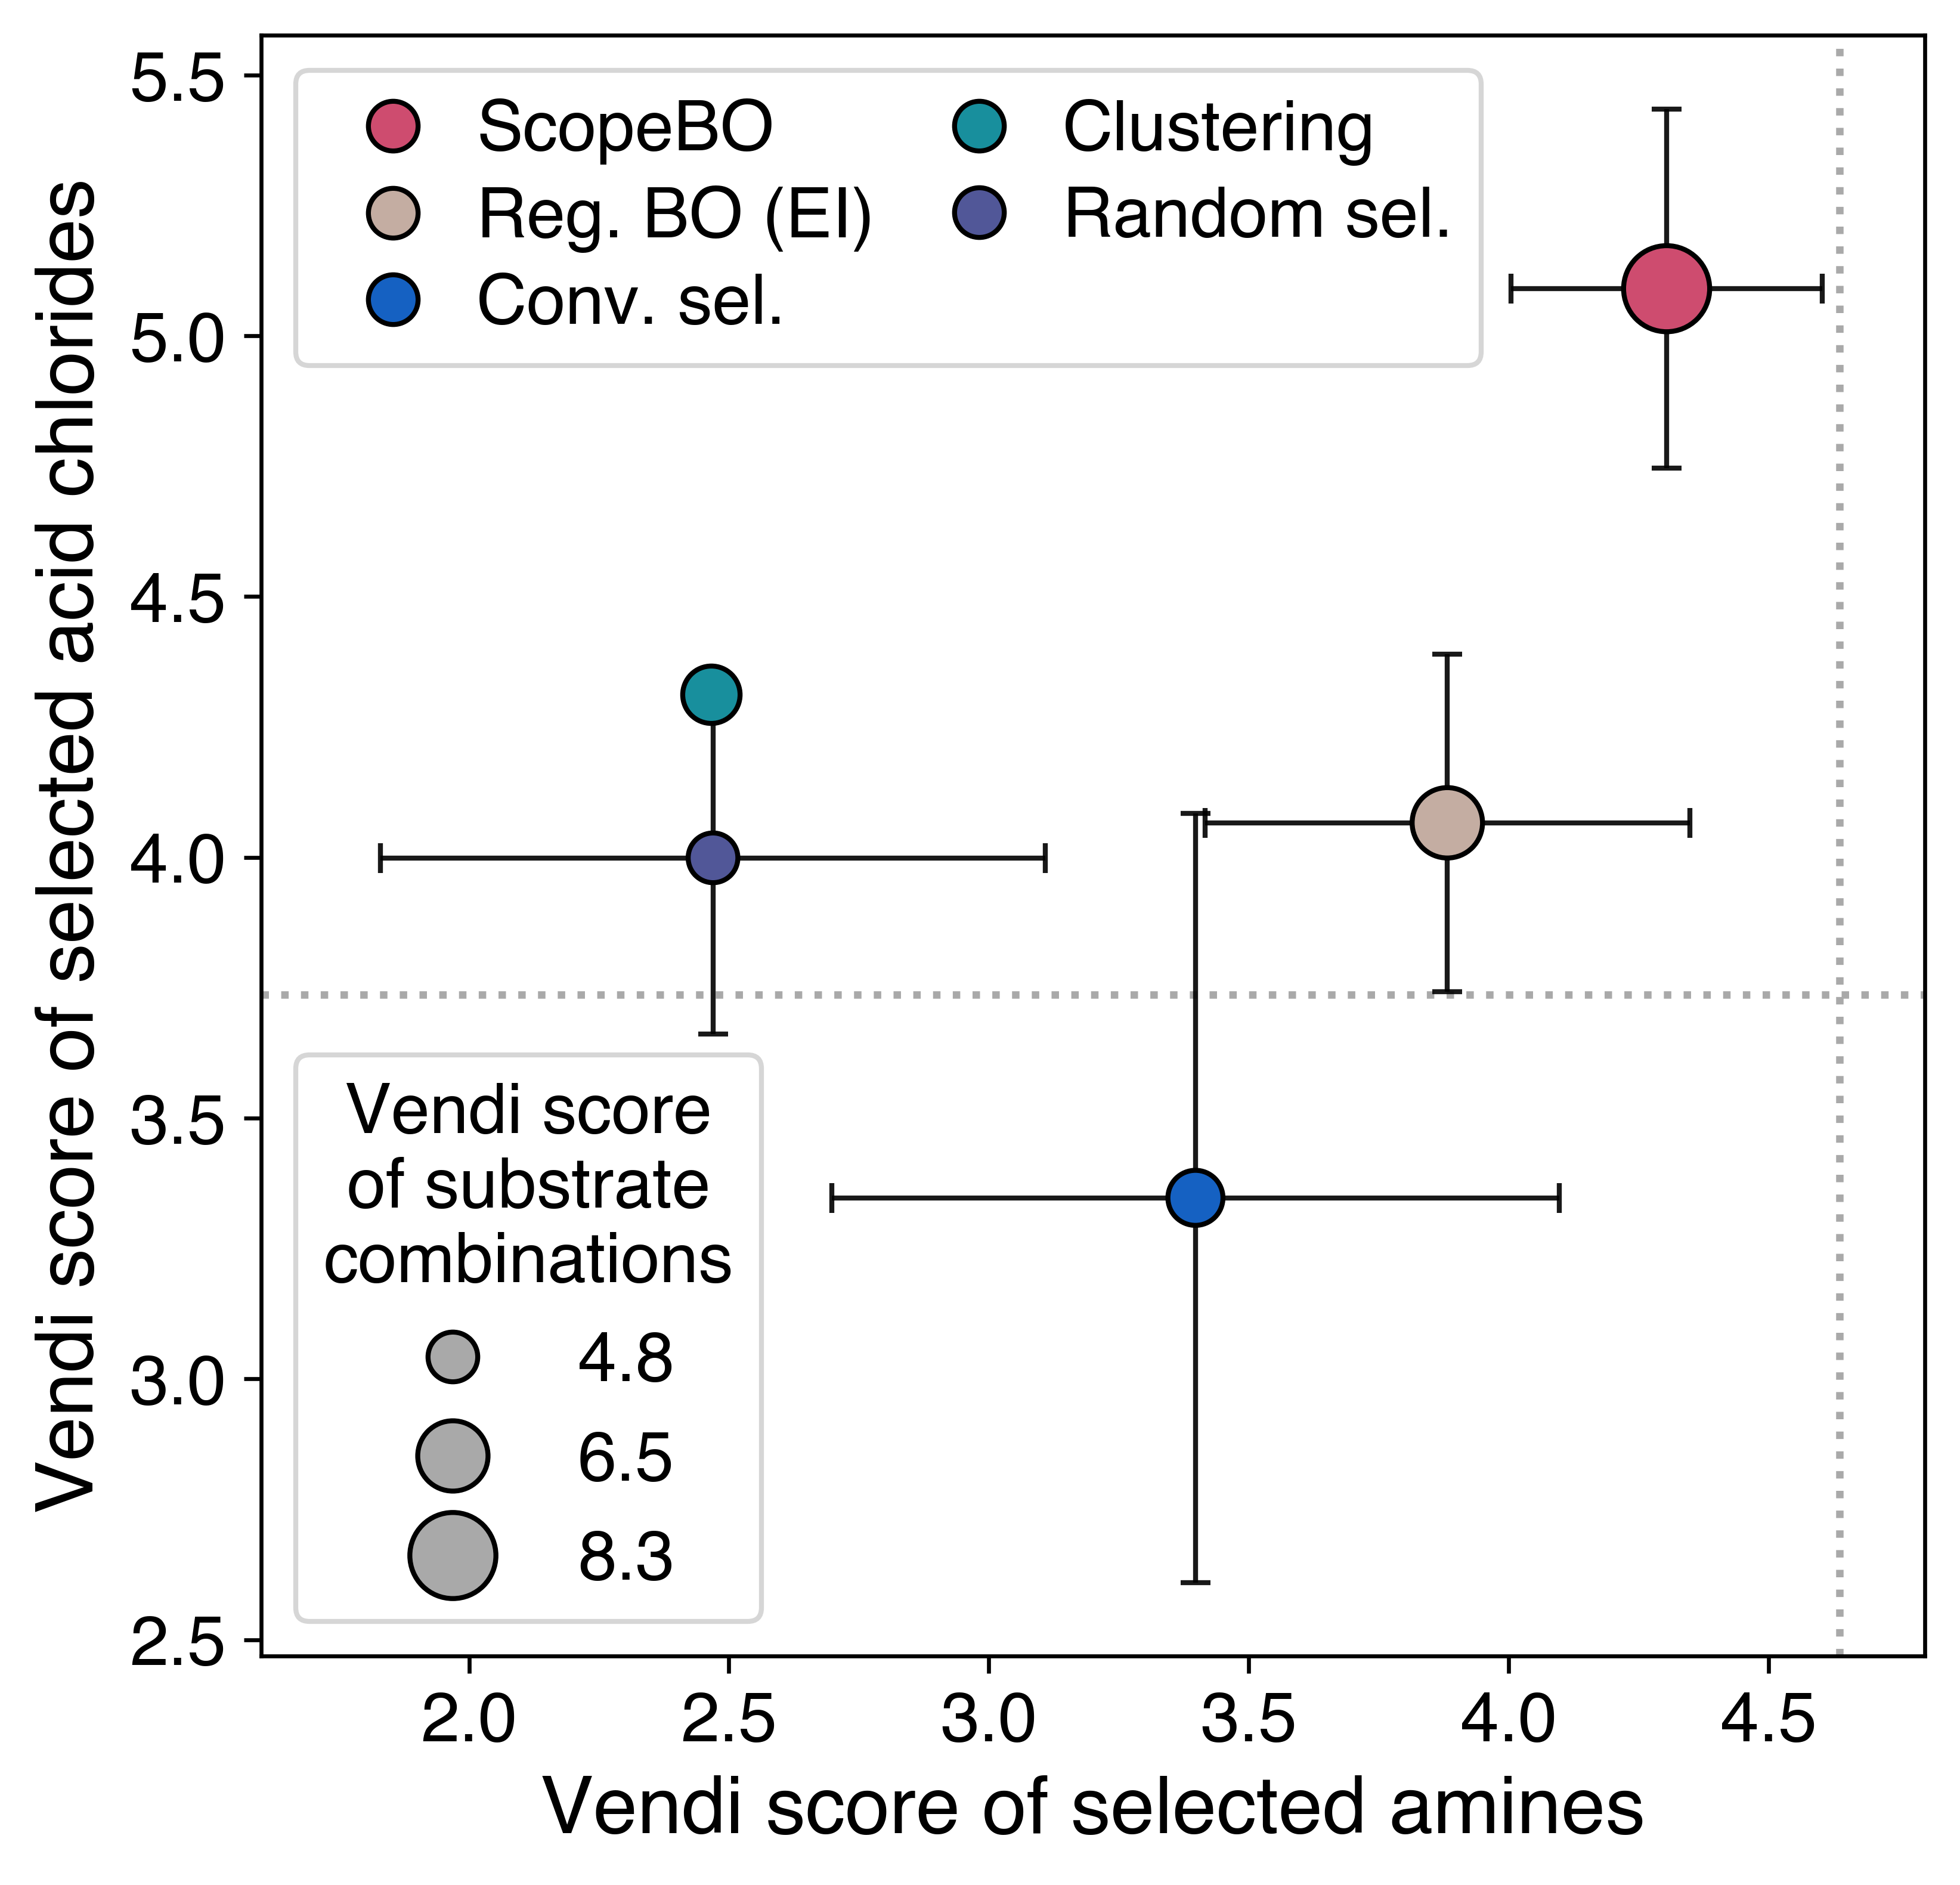

Vendi scores of the separate substrates:


,ScopeBO,Reg. BO (EI),Conv. sel.,Clustering,Random sel.
Amines,4.304 ± 0.299,3.882 ± 0.466,3.397 ± 0.7,2.466 ± 0.0,2.469 ± 0.639
Acid chlorides,5.09 ± 0.344,4.066 ± 0.324,3.347 ± 0.738,4.312 ± 0.0,3.999 ± 0.338
Combi,8.267 ± 0.629,6.532 ± 0.659,5.171 ± 0.887,5.357 ± 0.0,4.777 ± 0.754


In [81]:
Vendi_plot(sep_vendis_mean,sep_vendis_std)
print("Vendi scores of the separate substrates:")
sep_vendis_mean.applymap(lambda x: str(round(x,3))) + " ± " + sep_vendis_std.applymap(lambda x: str(round(x,3)))

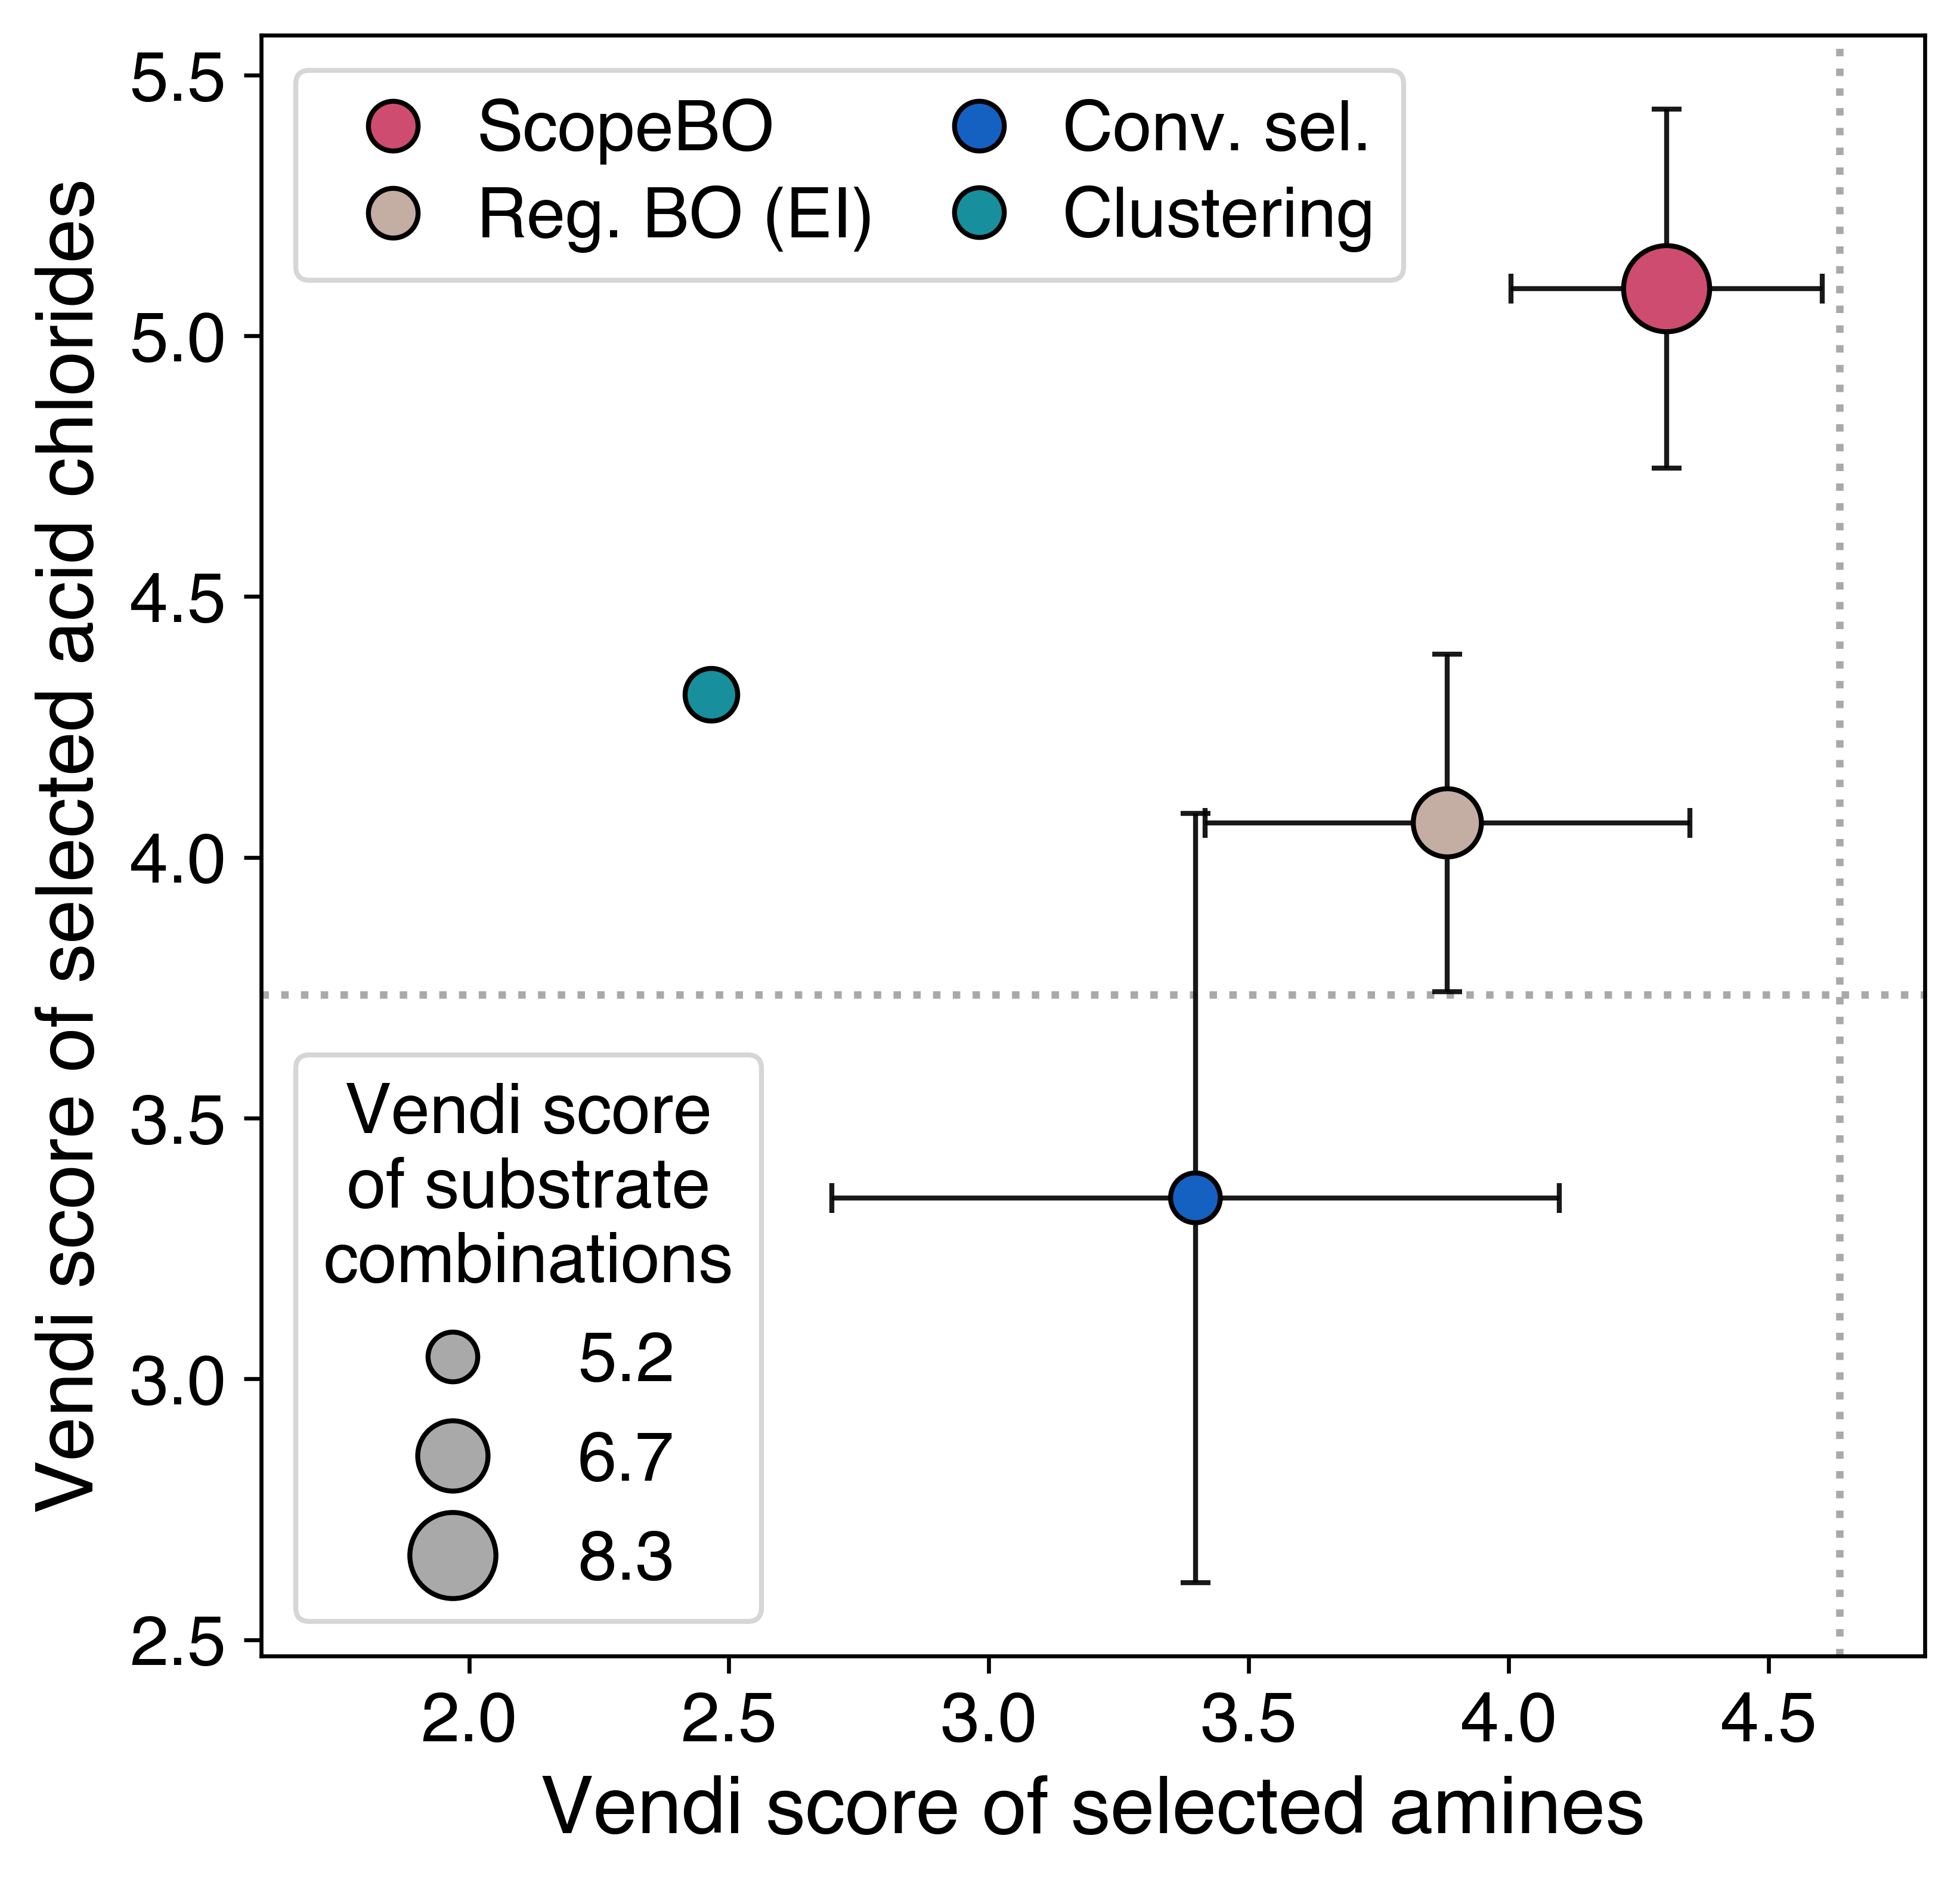

In [82]:
Vendi_plot(sep_vendis_mean.iloc[:,:-1],sep_vendis_std.iloc[:,:-1])